**Chapter 16 – Natural Language Processing with RNNs and Attention**

In this chapter, we will explore how to use Recurrent Neural Networks (RNNs) and Attention mechanisms for Natural Language Processing (NLP) tasks. We will cover the following topics:
1. Generating Shakespearean Text Using Character RNNs (including Stateful RNNs)
2. Sentiment Analysis (including Masking and Reusing Pretrained Embeddings)
3. Encoder-Decoder Networks for Neural Machine Translation (including Bidirectional RNNs and Beam Search)
4. Attention Mechanisms
5. The Transformer Architecture (including Positional Encodings and Multi-Head Attention)
6. Using the Hugging Face Transformers Library


_This notebook contains all the sample code and solutions to the exercises in chapter 16._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/16_nlp_with_rnns_and_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/16_nlp_with_rnns_and_attention.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [4]:
import sys

assert sys.version_info >= (3, 7)

**Warning**: the latest TensorFlow versions are based on Keras 3. For previous chapters, it wasn't too hard to update the code to support Keras 3, but unfortunately it's much harder for this chapter: for example, stateful RNNs work very differently, ragged tensors are no longer supported, TensorFlow Hub models are no longer supported, and more. So for this chapter I've had to revert to Keras 2. To do that, I set the `TF_USE_LEGACY_KERAS` environment variable to `"1"` and import the `tf_keras` package. This ensures that `tf.keras` points to `tf_keras`, which is Keras 2.*.

In [5]:
# 由於我們使用的是支援 Windows GPU 的 TensorFlow 2.10，
# Keras 本來就是舊版(Keras 2)且內建的，因此不需要 tf_keras 過渡套件。

# import os
# os.environ["TF_USE_LEGACY_KERAS"] = "1"
# import tf_keras

# 請直接使用標準的 TensorFlow 內建 Keras：
import tensorflow as tf
from tensorflow import keras

print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

TensorFlow Version: 2.10.1
Keras Version: 2.10.0


And TensorFlow ≥ 2.8:

In [6]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [7]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/nlp` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [8]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "nlp"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

This chapter can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

**Setup the conda environment with GPU:**

1. 建立並啟動環境
```bash
conda create -n homl_gpu python=3.9
conda activate homl_gpu
```

2. 安裝 TensorFlow 2.10 專用的 CUDA/cuDNN (Windows 唯一支援 GPU 的版本)
```bash
conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1.0
```

3. 安裝 TensorFlow 與相關套件
```bash
pip install "tensorflow<2.11"
pip install jupyter pandas matplotlib scikit-learn
pip install "numpy<2"
pip install tensorflow-datasets==4.8.3
pip install protobuf==3.20.3
pip install tensorflow-hub==0.13.0
```

4. 安裝 PyTorch (使用 pip 以避免與 TensorFlow 的 CUDA 11.2 產生版本衝突)
```bash
# 這裡使用 cu121 是因為它與您的最新驅動程式 (596.36) 完美相容且包含獨立的 runtime
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
```
5. 安裝 Hugging Face 生態系
```bash
pip install transformers==4.35.0 datasets tokenizers huggingface-hub accelerate
```

> 為什麼這樣改？
- 解決 Conda 衝突：原本的 `conda install pytorch` 會嘗試解決整個環境的依賴，導致 `UnsatisfiableError`。使用 `pip` 配合 `--index-url` 安裝 PyTorch 會自帶獨立的 CUDA 運行庫，不會干擾 TensorFlow 的環境。
- 驅動程式相容性：您的驅動版本 (596.36) 非常新，支援到 CUDA 13.2，因此安裝 `cu121` 版本的 PyTorch 既穩定又快速。
- 生產環境實踐 (MLOps)：明確標註 TensorFlow 需要的特定 CUDA/cuDNN 版本，能確保他人複製您的環境時不會因為版本漂移而導致 GPU 失效。

In [9]:
# 檢查 TensorFlow 是否有抓到實體 GPU
physical_devices = tf.config.list_physical_devices('GPU')
print("可用的 GPU 數量:", len(physical_devices))

if len(physical_devices) > 0:
    print("太棒了！你的模型即將在 GPU:", physical_devices[0].name, "上狂飆！")
    
    # 實務防呆機制：避免 TF 一次吃光你筆電的所有 VRAM，導致當機
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("糟糕，TensorFlow 還是只看到 CPU。")

可用的 GPU 數量: 1
太棒了！你的模型即將在 GPU: /physical_device:GPU:0 上狂飆！


In [10]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

---

# Generating Shakespearean Text Using a Character RNN
Let's start by training a character RNN to generate Shakespearean text.

## Creating the Training Dataset

Let's download the Shakespeare data from Andrej Karpathy's [char-rnn project](https://github.com/karpathy/char-rnn/)

In [9]:
import tensorflow as tf

shakespeare_url = "https://homl.info/shakespeare"  # shortcut URL
filepath = tf.keras.utils.get_file("shakespeare.txt", shakespeare_url)
with open(filepath) as f:
    shakespeare_text = f.read()

In [10]:
type(shakespeare_text)

str

In [11]:
len(shakespeare_text) # it contains 1,115,394 characters

1115394

In [12]:
# extra code – shows a short text sample
print(shakespeare_text[:80])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.


In [13]:
# extra code – shows all 39 distinct characters (after converting to lower case)
"".join(sorted(set(shakespeare_text.lower())))

"\n !$&',-.3:;?abcdefghijklmnopqrstuvwxyz"

Thus, the `shakespeare_text` variable contains the entire text of Shakespeare's works as a single string. We can check its length to see how many characters it contains:

In [14]:
vocab_size = len(set(shakespeare_text.lower()))
print(f"Unique characters: {vocab_size}")

Unique characters: 39


Next, we will use a `TextVectorization` layer to convert the text into sequences of integer IDs. We will configure it to split the text into characters and to convert all characters to lowercase:

In [15]:
text_vec_layer = tf.keras.layers.TextVectorization(split="character",
                                                   standardize="lower")

This code snippet sets up a `TextVectorization` layer from Keras to process the `shakespeare_text`. The `TextVectorization` layer is a preprocessing layer that **converts raw strings into integer sequences**, where each integer represents a token (in this case, a character).

When initializing `TextVectorization`
- `split="character"` configures the layer to break down the input text into individual characters rather than words.
- `standardize="lower"` ensures that all characters are converted to lowercase during processing, effectively treating 'A' and 'a' as the same character, which helps reduce the vocabulary size and simplifies the model's task.

In [16]:
text_vec_layer.adapt([shakespeare_text])

The `adapt` method is then called with `[shakespeare_text]`. This step analyzes the provided text to **build the layer's vocabulary**. It essentially scans all unique characters in `shakespeare_text` (after standardization) and assigns a unique integer ID to each. This learned vocabulary is crucial for converting text into numerical representations.

Applying the `TextVectorization` layer to the `shakespeare_text` will produce a 1D tensor of integers, where each integer corresponds to a character in the text based on the learned vocabulary. This tensor can then be used as input for training a character-level RNN to generate Shakespearean text.

In [17]:
text_vec_layer([shakespeare_text]) # this is a 1D tensor of integers, where each integer represents a character in the text.

<tf.Tensor: shape=(1, 1115394), dtype=int64, numpy=array([[21,  7, 10, ..., 22, 28, 12]], dtype=int64)>

In [18]:
encoded = text_vec_layer([shakespeare_text])[0]

Finally, `encoded = text_vec_layer([shakespeare_text])[0]` applies the adapted `TextVectorization` layer to the `shakespeare_text`. This **converts the entire Shakespearean text into a sequence of integer IDs**, where each ID corresponds to a character in the vocabulary. 

The `[0]` at the end is used because the `text_vec_layer` is designed to process batches of strings, so it returns a batch of encoded sequences. Since we passed a single string `[shakespeare_text]`, the result is a batch of one sequence, and `[0]` extracts that single encoded sequence.

The `encoded` variable now holds the entire `shakespeare_text` as a long sequence of character IDs, ready for use as input to an RNN.

In [19]:
encoded

<tf.Tensor: shape=(1115394,), dtype=int64, numpy=array([21,  7, 10, ..., 22, 28, 12], dtype=int64)>

Use `text_vec_layer.get_vocabulary()` to see the list of unique characters in the text, where the first token is reserved for padding, the second token is reserved for out-of-vocabulary characters, and the rest are the unique characters in the text *sorted by frequency*.

In [20]:
text_vec_layer.get_vocabulary()

['',
 '[UNK]',
 ' ',
 'e',
 't',
 'o',
 'a',
 'i',
 'h',
 's',
 'r',
 'n',
 '\n',
 'l',
 'd',
 'u',
 'm',
 'y',
 'w',
 ',',
 'c',
 'f',
 'g',
 'b',
 'p',
 ':',
 'k',
 'v',
 '.',
 "'",
 ';',
 '?',
 '!',
 '-',
 'j',
 'q',
 'x',
 'z',
 '3',
 '&',
 '$']

In [21]:
print(f"Range of character IDs: {encoded.numpy().min()} to {encoded.numpy().max()}")

Range of character IDs: 2 to 40


In [22]:
encoded -= 2  # drop tokens 0 (pad) and 1 (unknown), which we will not use
n_tokens = text_vec_layer.vocabulary_size() - 2  # number of distinct chars = 39
dataset_size = len(encoded)  # total number of chars = 1,115,394

After dropping the first two reserved tokens, we can see that the most common characters in Shakespeare's works are space, 'e', 't', 'o', and 'a'. Besides, we can inspect the integer ID assigned to each character. For example, the space character is assigned ID 2, 'e' is assigned ID 3, 't' is assigned ID 4, and so on.

In [23]:
encoded

<tf.Tensor: shape=(1115394,), dtype=int64, numpy=array([19,  5,  8, ..., 20, 26, 10], dtype=int64)>

In [24]:
print(f"Range of character IDs after encoding: {encoded.numpy().min()} to {encoded.numpy().max()}")

Range of character IDs after encoding: 0 to 38


In [25]:
n_tokens # 39 distinct characters

39

In [26]:
dataset_size # total number of chars = 1,115,394

1115394

In [27]:
def to_dataset(sequence, length, shuffle=False, seed=None, batch_size=32):
    """ Converts a sequence of character IDs into a tf.data.Dataset of input-target pairs for training an RNN. Each input sequence of length `length` is paired with a target sequence that is the same as the input sequence but shifted one character to the right (i.e., the next character to predict). If `shuffle` is True, the dataset will be shuffled with a buffer size of 100,000 and an optional random seed for reproducibility. The dataset is then batched and prefetched for efficient training.
    Args:
        sequence: A 1D tensor of character IDs.
        length: The length of the input sequences (the target sequences will be of the same length).
        shuffle: Whether to shuffle the dataset.
        seed: An optional random seed for shuffling.
        batch_size: The size of the batches in the resulting dataset.
    Returns:
        A tf.data.Dataset of (input, target) pairs, where input and target are batches of sequences of character IDs.
    """
    # 1. Start with a dataset of individual character IDs
    ds = tf.data.Dataset.from_tensor_slices(sequence)

    # 2. Create windows of length + 1 (input + target) with a shift of 1 characters of character IDs.
    ds = ds.window(length + 1, shift=1, drop_remainder=True)

    # 3. Unpack nested datasets into flat tensors of shape (length + 1,)
    ds = ds.flat_map(lambda window_ds: window_ds.batch(length + 1))

    # 4. Randomize (Crucial for Stateless RNNs, Optional for Stateful RNNs)
    if shuffle:
        ds = ds.shuffle(100_000, seed=seed)

    # 5. Group into batches for efficient training
    ds = ds.batch(batch_size)

    # 6. Split into (input, target) pairs and prefetch for performance
    return ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1)

The `to_dataset` function is a crucial utility for preparing sequential data for training recurrent neural networks (RNNs) in TensorFlow. It takes a flat sequence of character IDs and transforms it into a `tf.data.Dataset` of input-target pairs, suitable for training a language model to predict the next character in a sequence.

Let's break down its syntax and functionality step-by-step:



1. Create a base Dataset from the input sequence
`ds = tf.data.Dataset.from_tensor_slices(sequence)`
    - Explanation: `tf.data.Dataset.from_tensor_slices` creates a dataset where each element is a "slice" of the input tensor.
    - If `sequence` is `[1, 2, 3, 4, 5]`, `ds` initially yields `1`, then `2`, then `3`, etc.

2. Create sliding windows
`ds = ds.window(length + 1, shift=1, drop_remainder=True)`
    - Explanation: The `window` transformation creates a dataset of *datasets*.
        - `length + 1`: Each window will contain `length + 1` elements. This is because we need an input sequence of `length` and one additional character for its corresponding target.
        - `shift=1`: The window slides one element at a time, creating overlapping windows.
        - `drop_remainder=True`: Any window that would be shorter than `length + 1` (at the end of the sequence) is discarded.
    - For `sequence = [1, 2, 3, 4, 5]` and `length = 2`, `length + 1 = 3`.
        - This step would create windows like:
            Dataset([1, 2, 3]), Dataset([2, 3, 4]), Dataset([3, 4, 5])
        - Note: At this stage, each element of `ds` is still a `tf.data.Dataset` object itself, not a tensor.
            - The first element is a dataset that yields `1`, then `2`, then `3`.
            - The second element is a dataset that yields `2`, then `3`, then `4`, and so on.
    - For each window, we create an inner dataset that contains the elements of that window. This is why we get a dataset of datasets.
    - For `sequence = [1, 2, 3, 4, 5]` and `length = 2`, the resulting `ds` would yield:
        - A dataset that yields `1`, then `2`, then `3`
        - A dataset that yields `2`, then `3`, then `4`
        - A dataset that yields `3`, then `4`, then `5`

3. Flatten the dataset of datasets into a dataset of tensors
`ds = ds.flat_map(lambda window_ds: window_ds.batch(length + 1))`
    - Explanation: `flat_map` is used here to "flatten" the dataset of datasets.
        - `window_ds.batch(length + 1)`: For each `window_ds` (which is an inner dataset representing one window),
            - `batch(length + 1)` collects all `length + 1` elements into a single tensor.
            - For example, if `window_ds` yields `1`, then `2`, then `3`, after batching it will yield a single tensor: `tf.Tensor([1, 2, 3])`.
        - `flat_map` then combines all these resulting tensors into a single flat dataset.
            - After this step, `ds` will yield tensors instead of datasets. Each tensor corresponds to one window of the original sequence.
    - Continuing the example with `length = 2`:
        - `ds` now yields `tf.Tensor([1, 2, 3])`, then `tf.Tensor([2, 3, 4])`, then `tf.Tensor([3, 4, 5])`.

4. Shuffle the dataset if requested

```python
if shuffle:
    ds = ds.shuffle(100_000, seed=seed)
```
- Explanation: `shuffle` randomizes the order of elements in the dataset.
    - `buffer_size=100_000`: This is the size of the buffer from which elements are randomly sampled. A larger buffer size means better randomization but requires more memory.
    - `seed`: Ensures reproducibility of the shuffle order if provided.

5. Batch the sequences
`ds = ds.batch(batch_size)`
    - Explanation: `batch` groups multiple individual sequence tensors into a single batch tensor.
    - If `batch_size = 2` and `ds` yields `[1, 2, 3]`, `[2, 3, 4]`, `[3, 4, 5]`:
        - The first output of this step would be `tf.Tensor([[1, 2, 3], [2, 3, 4]])`.

6. Map each batched window to an (input, target) pair and prefetch
`return ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1)`
- Explanation:
    - `map`: Applies a transformation function to each element of the dataset. Here, the lambda function takes a batch of windows.
    - `window[:, :-1]`: This slices each sequence in the batch. For a batch of sequences like `[[1, 2, 3], [2, 3, 4]]`,
        it takes all rows (`:`) and all columns except the last one (`:-1`). This creates the input sequences: `[[1, 2], [2, 3]]`.
    - `window[:, 1:]`: This slices each sequence in the batch. It takes all rows (`:`) and all columns starting from the second one (`1:`).
        This creates the target sequences (the next character for each input character): `[[2, 3], [3, 4]]`.
        The `map` operation thus transforms each batch of raw windows into a tuple of `(input_batch, target_batch)`.
    - `prefetch(1)`: This optimizes performance by overlapping the data preprocessing and model training.
        While the model is training on the current batch, the `tf.data` pipeline is already preparing the next batch in the background.
        - `buffer_size=1` typically means one batch is prefetched.

**Why this specific sequence of operations?**

The `tf.data` API is designed for efficient data processing. The sequence of operations is chosen to:
*   **Create contiguous sequences**: `window` creates overlapping sequences from a continuous stream of data.
*   **Handle `window` output**: `window` produces a `Dataset` of `Dataset`s. `flat_map` is essential to convert this nested structure into a flat `Dataset` of tensors, which can then be directly batched and mapped. If `batch` were used directly on the output of `window`, you'd get batches of `Dataset` objects, which is usually not what's desired.
*   **Efficient Shuffling**: Shuffling *after* windowing and flattening, but *before* batching, ensures that individual sequence windows are thoroughly randomized before they are grouped into batches.
*   **Prepare Input/Target Pairs**: The final `map` step is where the crucial transformation for sequence prediction happens, creating the `(input, target)` pairs where the target is simply the input shifted by one position.
*   **Performance**: `prefetch` is a standard practice for improving training throughput by keeping the GPU/CPU busy.

In [28]:
# extra code – a simple example using to_dataset()
# There's just one sample in this dataset: the input represents "to b" and the
# output represents "o be"
list(to_dataset(text_vec_layer(["To be"])[0], length=4))

[(<tf.Tensor: shape=(1, 4), dtype=int64, numpy=array([[ 4,  5,  2, 23]], dtype=int64)>,
  <tf.Tensor: shape=(1, 4), dtype=int64, numpy=array([[ 5,  2, 23,  3]], dtype=int64)>)]

In [29]:
for input, target in to_dataset(text_vec_layer(["To be or not"])[0], length=4):
    print("Input batch:")
    print(input)
    print("Target batch:")
    print(target)

Input batch:
tf.Tensor(
[[ 4  5  2 23]
 [ 5  2 23  3]
 [ 2 23  3  2]
 [23  3  2  5]
 [ 3  2  5 10]
 [ 2  5 10  2]
 [ 5 10  2 11]
 [10  2 11  5]], shape=(8, 4), dtype=int64)
Target batch:
tf.Tensor(
[[ 5  2 23  3]
 [ 2 23  3  2]
 [23  3  2  5]
 [ 3  2  5 10]
 [ 2  5 10  2]
 [ 5 10  2 11]
 [10  2 11  5]
 [ 2 11  5  4]], shape=(8, 4), dtype=int64)


Finally, the resulting dataset is a `tf.data.Dataset` of `(input, target)` pairs, where each `input` is a batch of sequences of character IDs, and each `target` is the corresponding batch of next-character IDs. This dataset can be directly fed into an RNN for training a language model.

In [30]:
length = 100
tf.random.set_seed(42)
train_set = to_dataset(encoded[:1_000_000], length=length, shuffle=True,
                       seed=42)
valid_set = to_dataset(encoded[1_000_000:1_060_000], length=length)
test_set = to_dataset(encoded[1_060_000:], length=length)

The datasets for training, validation, and testing are created by calling the `to_dataset` function with the appropriate parameters. The training set is shuffled to ensure that the model does not learn any spurious patterns from the order of the data, while the validation and test sets are not shuffled to maintain consistency for evaluation.

In [31]:
for item in train_set.take(1):
    print(f"Input shape: {item[0].shape}, Target shape: {item[1].shape}")
    print(f"Input sample:\n{item[0][0].numpy()}\n")
    print(f"Target sample:\n{item[1][0].numpy()}")

Input shape: (32, 100), Target shape: (32, 100)
Input sample:
[15  0  9  3 16 17  0  9  3  0 14  3  8  1 26 10 10 18  3 14  5  9  5 13
  7 23 10 11  3  3 24 17  0  7  5  8 17  0 15  3 13  8  0 14  3  2  6  1
  8 30 10 10 18  3  8  5  3 11  4  9 13  7 23 10  3 17 10 15  3 13  0  6
  4 25  1 17  0  5  0 24  9  3 16 17  0 22  1  2  5  2  5  3  9 27 12  0
  4 11 11  0]

Target sample:
[ 0  9  3 16 17  0  9  3  0 14  3  8  1 26 10 10 18  3 14  5  9  5 13  7
 23 10 11  3  3 24 17  0  7  5  8 17  0 15  3 13  8  0 14  3  2  6  1  8
 30 10 10 18  3  8  5  3 11  4  9 13  7 23 10  3 17 10 15  3 13  0  6  4
 25  1 17  0  5  0 24  9  3 16 17  0 22  1  2  5  2  5  3  9 27 12  0  4
 11 11  0  2]


## Building and Training the Char-RNN Model

**Warning**: the following code may one or two hours to run, depending on your GPU. Without a GPU, it may take over 24 hours. If you don't want to wait, just skip the next two code cells and run the code below to download a pretrained model.

**Note**: the `GRU` class will only use cuDNN acceleration (assuming you have a GPU) when using the default values for the following arguments: `activation`, `recurrent_activation`, `recurrent_dropout`, `unroll`, `use_bias` and `reset_after`.

In [31]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=n_tokens, output_dim=16),
    tf.keras.layers.GRU(128, return_sequences=True),
    tf.keras.layers.Dense(n_tokens, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model_ckpt = tf.keras.callbacks.ModelCheckpoint(
    "my_shakespeare_model.keras", monitor="val_accuracy", save_best_only=True)


In [32]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 16)          624       
                                                                 
 gru (GRU)                   (None, None, 128)         56064     
                                                                 
 dense (Dense)               (None, None, 39)          5031      
                                                                 
Total params: 61,719
Trainable params: 61,719
Non-trainable params: 0
_________________________________________________________________


In [33]:
# history = model.fit(train_set, validation_data=valid_set, epochs=10, callbacks=[model_ckpt])

In [34]:
shakespeare_model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Lambda(lambda X: X - 2),  # no <PAD> or <UNK> tokens
    model
])

The two layers before the main `model` layer in the `shakespeare_model` are crucial for preprocessing the raw text input into a format that the underlying RNN model can understand and process correctly.

Let's break down each layer:

1.  **`text_vec_layer` (TextVectorization Layer):**
    *   **Purpose:** This layer is responsible for converting raw input strings (like `"To be or not to b"`) into sequences of integer IDs. It acts as the initial preprocessing step, transforming human-readable text into a numerical representation that a neural network can process.
    *   **How it works:**
        *   When `text_vec_layer.adapt([shakespeare_text])` was called earlier in the notebook, it scanned the entire Shakespearean text, identified all unique characters (after converting to lowercase), and built a vocabulary.
        *   Crucially, the `TextVectorization` layer by default reserves the first two indices in its vocabulary: index `0` for padding tokens (`<PAD>`) and index `1` for out-of-vocabulary tokens (`<UNK>`).
        *   So, when `text_vec_layer` receives a string, it outputs a sequence of integers where each integer is the ID of the corresponding character in its learned vocabulary.

2.  **`tf.keras.layers.Lambda(lambda X: X - 2)` (Lambda Layer for ID Adjustment):**
    *   **Purpose:** This layer adjusts the character IDs output by the `text_vec_layer` to match the expected input range of the downstream `model`'s `Embedding` layer.
    *   **How it works:**
        *   As mentioned, `text_vec_layer` assigns IDs starting from `0` for `<PAD>` and `1` for `<UNK>`, with actual characters starting from `2`.
        *   However, the `Embedding` layer within your `model` is defined with `input_dim=n_tokens`. The `n_tokens` variable was calculated as `text_vec_layer.vocabulary_size() - 2`, meaning it represents the count of *actual* distinct characters, starting from `0`.
        *   Therefore, if `text_vec_layer` outputs an ID of `2` for, say, the character ' ' (space), the `Embedding` layer expects this to be treated as ID `0` (the first actual character). If it outputs `3` for 'e', the `Embedding` layer expects `1`, and so on.
        *   The `lambda X: X - 2` function simply subtracts `2` from every character ID. This effectively shifts the IDs so that the *actual* characters now range from `0` to `n_tokens - 1`, perfectly aligning with the `Embedding` layer's `input_dim` and expected indexing, while removing the problematic `<PAD>` and `<UNK>` token IDs that the RNN model is not designed to handle at this stage.

In essence, these two layers form an integrated **preprocessing pipeline** within your `shakespeare_model`. They ensure that any raw text string fed to `shakespeare_model` is first tokenized into character IDs and then adjusted to a numerical range that the internal `model` (containing the `Embedding`, `GRU`, and `Dense` layers) can process without issues related to special tokens or misaligned indices.

If you don't want to wait for training to complete, I've pretrained a model for you. The following code will download it. Uncomment the last line if you want to use it instead of the model trained above.

In [35]:
# extra code – downloads a pretrained model
url = "https://github.com/ageron/data/raw/main/shakespeare_model.tgz"
path = tf.keras.utils.get_file("shakespeare_model.tgz", url, extract=True)
if "_extracted" in path:
    model_path = Path(path) / "shakespeare_model"
else:
    model_path = Path(path).with_name("shakespeare_model")
shakespeare_model = tf.keras.models.load_model(model_path)

In [36]:
shakespeare_model.summary() # extra code – shows the model architecture

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVec  (None, None)             0         
 torization)                                                     
                                                                 
 lambda_5 (Lambda)           (None, None)              0         
                                                                 
 sequential (Sequential)     (None, None, 39)          61719     
                                                                 
Total params: 61,719
Trainable params: 61,719
Non-trainable params: 0
_________________________________________________________________


In [37]:
len("To be or not to b")

17

In [38]:
shakespeare_model.predict(["To be or not to b"])

1/1 [==============================] - 6s 6s/step


array([[[1.81605488e-01, 6.63638413e-02, 6.29482791e-03, 1.06499925e-01,
         2.56307907e-02, 7.74630904e-02, 3.66920501e-01, 4.67901910e-03,
         3.51227708e-02, 1.17561040e-05, 9.23664309e-03, 1.85006559e-02,
         5.55209681e-07, 1.79153923e-02, 2.96251528e-04, 6.57636719e-03,
         1.29394196e-02, 2.60540042e-02, 1.12864363e-03, 9.52916380e-05,
         1.11503823e-06, 1.22873607e-04, 1.16695534e-03, 9.43208020e-03,
         2.97730679e-07, 3.16819175e-08, 1.23240240e-02, 5.35374321e-03,
         1.70228840e-03, 3.55817983e-03, 1.34169264e-03, 1.66080648e-03,
         5.95084657e-07, 1.22333932e-09, 1.27723299e-09, 1.44194502e-07,
         6.60867860e-10, 4.53843345e-19, 9.39286693e-09],
        [7.49189019e-01, 8.55596045e-06, 1.49496791e-05, 1.44365467e-02,
         8.38652977e-06, 7.63155986e-04, 2.04320648e-04, 6.81276084e-04,
         7.86617175e-02, 2.04984602e-02, 1.16965603e-02, 1.66693144e-02,
         1.01096530e-05, 1.15956236e-02, 1.31881600e-02, 9.4310983

The output of the prediction method returns a batch of sequences of character IDs, where each ID corresponds to the predicted next character in the sequence. 

For an input sequence of length $L$, the output will typically have a shape like `(batch_size, L, n_tokens)`, where `n_tokens` is the size of the character vocabulary. Each element in the output tensor represents the predicted probability distribution over the next character for each position in the input sequence. To get the actual predicted character IDs, you would typically take the `argmax` of the output along the last dimension (the `n_tokens` dimension).

In [39]:
y_proba = shakespeare_model.predict(["To be or not to b"])[0, -1]
y_pred = tf.argmax(y_proba)  # choose the most probable character ID
text_vec_layer.get_vocabulary()[y_pred + 2]

1/1 [==============================] - 0s 41ms/step


'e'

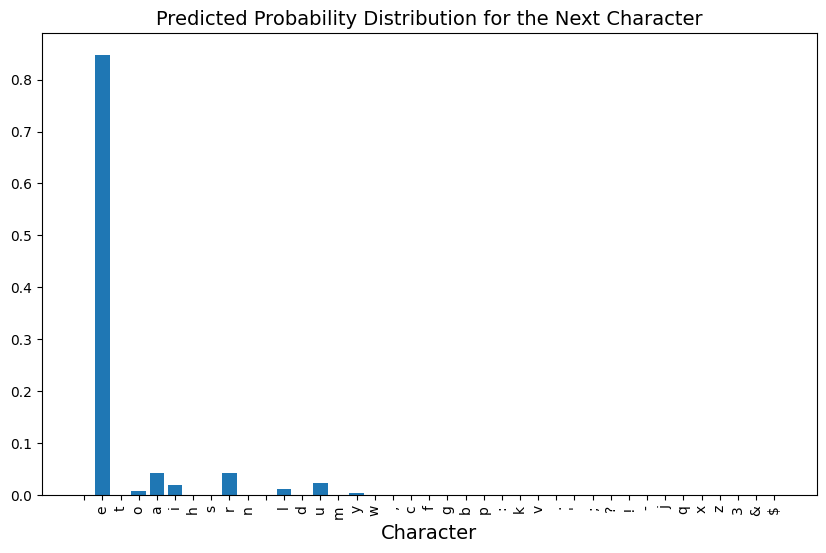

In [40]:
# Visualize the predicted probability distribution over the next character
plt.figure(figsize=(10, 6))
plt.bar(range(n_tokens), y_proba)
plt.xticks(range(n_tokens), text_vec_layer.get_vocabulary()[2:], rotation=90)
plt.xlabel("Character")
# plt.ylabel("Probability") --- IGNORE ---
plt.title("Predicted Probability Distribution for the Next Character")
plt.show()

## Generating Fake Shakespearean Text

In [41]:
log_probas = tf.math.log([[0.5, 0.4, 0.1]])  # probas = 50%, 40%, and 10%


In [43]:
tf.random.set_seed(42)
tf.random.categorical(log_probas, num_samples=8)  # draw 8 samples

<tf.Tensor: shape=(1, 8), dtype=int64, numpy=array([[0, 0, 1, 1, 1, 0, 0, 0]], dtype=int64)>

In [37]:
print("logits:", log_probas.numpy())

logits: [[-0.6931472 -0.9162907 -2.3025851]]


This Python snippet demonstrates how to perform **categorical sampling from a probability distribution** using TensorFlow, ensuring reproducibility. It's a fundamental operation in many machine learning models, especially for generating sequences like text, where a model predicts the likelihood of the next token from a vocabulary.

Let's break down each line:

```python
log_probas = tf.math.log([[0.5, 0.4, 0.1]])  # probas = 50%, 40%, and 10%
```

1.  **`tf.math.log`**: This TensorFlow function calculates the natural logarithm (base $e$) of its input.
2.  **`[[0.5, 0.4, 0.1]]`**: This is a list representing a 2D tensor. It holds a probability distribution for three distinct categories. The probabilities are 0.5 (50%), 0.4 (40%), and 0.1 (10%), summing up to 1.0.
3.  **Purpose of `log_probas`**: The `tf.random.categorical` function, which we'll see next, expects its input to be `logits`. *Logits are essentially the unnormalized log-probabilities*. By taking the natural logarithm of the given probabilities, we convert them into a format suitable for the `categorical` sampler. Using log-probabilities is often preferred in numerical computations to maintain stability, especially when dealing with very small probabilities, as multiplying many small floating-point numbers can lead to underflow. Adding their logarithms (since $\log(a \cdot b) = \log a + \log b$) avoids this issue.



> Mathematically, the term **logit** originates from statistics, specifically logistic regression. However, modern Deep Learning has slightly "hijacked" the term. Let's break down the pure mathematical definition first, and then look at how it translates into the raw numbers moving through your neural networks.

### 1. The Pure Math: Log-Odds

In probability, a **logit** is simply the **logarithm of the odds** of an event occurring.

Let $p$ be the probability of an event happening (e.g., an image being a dog). The probability of it *not* happening is $(1 - p)$.

* **Odds:** The ratio of the probability of success to the probability of failure.

$$\text{Odds} = \frac{p}{1 - p}$$


* **Logit Function:** The natural logarithm ($\ln$) of the odds.

$$z = \text{logit}(p) = \ln\left(\frac{p}{1 - p}\right)$$



The beauty of the logit function is that while probabilities ($p$) are strictly bounded between $0$ and $1$, **logits ($z$) can range anywhere from $-\infty$ to $+\infty$**. This makes them perfectly suited for the linear outputs of a machine learning model.

#### Inverting the Logit (The Sigmoid)

If a neural network layer outputs a raw logit ($z$), we need to map it back to a valid probability ($p$). We do this by calculating the inverse of the logit function.

Let's solve for $p$:


$$e^z = \frac{p}{1 - p}$$

$$e^z(1 - p) = p$$

$$e^z - p \cdot e^z = p$$

$$e^z = p(1 + e^z)$$

$$p = \frac{e^z}{1 + e^z}$$

By multiplying the top and bottom by $e^{-z}$, we arrive at the famous **Logistic Sigmoid Function**:


$$p = \frac{1}{1 + e^{-z}}$$

---

### 2. The Deep Learning Definition: Unnormalized Scores

When you read Aurélien Géron's *Hands-On Machine Learning*, you will frequently see the term "logits" used in the context of neural network architectures (like the final layer of a classifier before the Softmax activation).

In deep learning, **logits simply refer to the raw, unnormalized predictions generated by the last linear layer of your network.** Mathematically, for a given input vector $x$, a weight matrix $W$, and a bias vector $b$, the logits ($z$) are:


$$z = W \cdot x + b$$

If you are doing multi-class classification (e.g., predicting 10 different clothing items in Fashion MNIST), your network outputs a vector of 10 logits. We convert this vector of logits into a probability distribution using the **Softmax function**:


$$p_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$


Where $K$ is the total number of classes.

---

### 3. Production Practice: Why We Don't Output Probabilities

In production Keras/TensorFlow code, you will frequently see this setup when compiling a model:

```python
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer="adam"
)

```

**Why do MLOps engineers explicitly tell the loss function to expect `logits` instead of probabilities?**

It comes down to **numerical stability**. Computers have limited floating-point precision.
If your model is extremely confident, it might output a highly negative logit. When passed through a Softmax function, this might round down to exactly `0.0`.

The Cross-Entropy loss function calculates the logarithm of your probabilities ($-\sum y \cdot \ln(p)$). If the probability rounded to $0.0$, the computer will attempt to calculate $\ln(0)$, resulting in a `NaN` (Not a Number) error, immediately crashing your training loop.

By setting `from_logits=True`, TensorFlow skips computing the Softmax and Cross-Entropy separately. Instead, it combines them mathematically using the **log-sum-exp trick**, calculating the loss directly from the raw logits and completely avoiding the $\ln(0)$ crash.

To see exactly how changing these raw logits affects the final normalized probabilities, you can use the simulator below.

```python
tf.random.set_seed(42)
```

1.  **`tf.random.set_seed(42)`**: This line sets the global random seed for all TensorFlow operations.
2.  **Purpose**: By setting a specific seed (here, 42), you ensure that any subsequent random operations (like `tf.random.categorical`) will produce the exact same sequence of "random" numbers every time you run the code. This is crucial for **reproducibility** in research and debugging, allowing you to get consistent results from your models.



```python
tf.random.categorical(log_probas, num_samples=8)  # draw 8 samples
```

1.  **`tf.random.categorical`**: This function draws samples from a categorical distribution. A categorical distribution describes the probability of an event falling into one of several distinct categories.
2.  **`log_probas`**: This is the input tensor of logits (the log-probabilities we calculated earlier). The shape `[[...]]` indicates that we are dealing with a single batch (outer list) and three categories (inner list).
3.  **`num_samples=8`**: This argument specifies that we want to draw 8 independent samples from the defined categorical distribution.
4.  **Output**: The function will return a tensor containing 8 integer values. Each integer will be either 0, 1, or 2, corresponding to the indices of the categories in our `log_probas` tensor. The probability of drawing a particular index will be proportional to its original probability (0.5 for index 0, 0.4 for index 1, and 0.1 for index 2). So, you would expect to see index 0 most frequently, followed by index 1, and then index 2.



### In Context: Text Generation
This exact mechanism is widely used in Natural Language Processing (NLP), particularly in **character-level or word-level text generation** using Recurrent Neural Networks (RNNs) or Transformers.

For instance, when an RNN trained to generate text (like the Shakespearean text generator earlier in this notebook) needs to pick the next character:
1.  The model outputs a vector of `logits` (unnormalized log-probabilities) for every possible character in its vocabulary.
2.  These `logits` are then fed to `tf.random.categorical`.
3.  A `num_samples=1` is typically used to draw a single character ID.
4.  This sampled character ID is then converted back to a character and appended to the generated text, which then becomes part of the input for predicting the *next* character.

The `temperature` parameter (seen in the `next_char` function) is often applied to these `logits` before sampling to control the randomness of the generation. A low temperature makes the sampling more "greedy" (picking the most probable character), while a high temperature makes it more "diverse" (more likely to pick less probable characters).

In [51]:
pred = shakespeare_model.predict(["To be or not to be"])
pred

1/1 [==============================] - 0s 493ms/step


array([[[1.81605488e-01, 6.63638413e-02, 6.29482791e-03, 1.06499925e-01,
         2.56307907e-02, 7.74630904e-02, 3.66920501e-01, 4.67901910e-03,
         3.51227708e-02, 1.17561040e-05, 9.23664309e-03, 1.85006559e-02,
         5.55209681e-07, 1.79153923e-02, 2.96251528e-04, 6.57636719e-03,
         1.29394196e-02, 2.60540042e-02, 1.12864363e-03, 9.52916380e-05,
         1.11503823e-06, 1.22873607e-04, 1.16695534e-03, 9.43208020e-03,
         2.97730679e-07, 3.16819175e-08, 1.23240240e-02, 5.35374321e-03,
         1.70228840e-03, 3.55817983e-03, 1.34169264e-03, 1.66080648e-03,
         5.95084657e-07, 1.22333932e-09, 1.27723299e-09, 1.44194502e-07,
         6.60867860e-10, 4.53843345e-19, 9.39286693e-09],
        [7.49189019e-01, 8.55596045e-06, 1.49496791e-05, 1.44365467e-02,
         8.38652977e-06, 7.63155986e-04, 2.04320648e-04, 6.81276084e-04,
         7.86617175e-02, 2.04984602e-02, 1.16965603e-02, 1.66693144e-02,
         1.01096530e-05, 1.15956236e-02, 1.31881600e-02, 9.4310983

In [39]:
pred.shape

(1, 18, 39)

To control the creativity and randomness of the generated text, the notebook implements a custom sampling strategy over the raw model outputs in the `next_char` function:

In [53]:
def next_char(text, temperature=1):
    # 1. Predict the probability distribution for the next character
    #    given the input 'text'. [0, -1:] extracts the probabilities
    #    for the last character in the sequence.
    y_proba = shakespeare_model.predict([text])[0, -1:]

    # 2. Rescale the logits (log probabilities) by the temperature factor.
    #    - As temperature approaches 0, the highest probability is amplified,
    #      leading to deterministic (greedy) decoding where the most
    #      probable character is always chosen.
    #    - As temperature increases, the probability distribution becomes
    #      flatter, increasing randomness and diversity in character
    #      selection, but also potentially leading to less coherent text.
    rescaled_logits = tf.math.log(y_proba) / temperature

    # 3. Sample a single character ID from the adjusted probability distribution.
    #    tf.random.categorical samples an element based on the input logits.
    #    [0, 0] extracts the single sampled character ID.
    char_id = tf.random.categorical(rescaled_logits, num_samples=1)[0, 0]

    # 4. Convert the sampled character ID back to its corresponding character
    #    using the text_vec_layer's vocabulary.
    #    '+ 2' is used to account for the earlier shift that dropped
    #    <PAD> and <UNK> tokens.
    return text_vec_layer.get_vocabulary()[char_id + 2]

In [54]:
def extend_text(text, n_chars=50, temperature=1):
    for _ in range(n_chars):
        text += next_char(text, temperature)
    return text

In [55]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

In [56]:
print(extend_text("To be or not to be", temperature=0.01))

1/1 [==============================] - 0s 50ms/step
To be or not to be the duke
as it is a proper strange death,
and the


In [57]:
print(extend_text("To be or not to be", temperature=1))

1/1 [==============================] - 0s 34ms/step
To be or not to begg, i
point and through you are to-morrow?

romeo:


In [58]:
print(extend_text("To be or not to be", temperature=100))

1/1 [==============================] - 0s 43ms/step
To be or not to bepevicm-vilv!?$mz?gmjz :3?ljb'va;!td&
i.ur3l'-j!3em


### Softmax Temperature Scaling

#### Decoding Reality: Temperature Sampling

Once your model outputs predictions, it doesn't just output a single character; it outputs raw scores (logits) for every possible character. To convert these logits into probabilities, we use a Softmax function modified by a parameter called **Temperature ($T$)**:$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$As highlighted in your NotebookLM notes, controlling this temperature is a critical production practice for text generation:
- Low Temperature (e.g., $T=0.01$): The model is highly conservative and acts almost identically to greedy decoding, picking the absolute most likely character.
- High Temperature (e.g., $T=100$): The probabilities flatten out, making the model highly random and prone to generating complete gibberish.

Recall previously we had the following logits for three characters: `[[0.5, 0.4, 0.1]]`. Let's see how changing the temperature affects the probabilities:

In [46]:
print(f"log_probas (logits): {log_probas.numpy()}")
print(f"Rescaled logits with temperature=0.01: {(log_probas / 0.01).numpy()}")

log_probas (logits): [[-0.6931472 -0.9162907 -2.3025851]]
Rescaled logits with temperature=0.01: [[ -69.31472   -91.629074 -230.25851 ]]


Use different temperatures to see how the probabilities change and how it affects the sampling of characters. You can run the following code snippets to observe the effects of temperature scaling on the logits and the resulting sampled character indices.

In [48]:
print(f"Temperature Sampling with temperature=0.01: {tf.random.categorical(log_probas / 0.01, num_samples=8).numpy()}")

Temperature Sampling with temperature=0.01: [[0 0 0 0 0 0 0 0]]


In [49]:
print(f"Temperature Sampling with temperature=2: {tf.random.categorical(log_probas / 2, num_samples=8).numpy()}")

Temperature Sampling with temperature=2: [[0 0 1 0 0 1 1 2]]


In [50]:
print(f"Temperature Sampling with temperature=100: {tf.random.categorical(log_probas / 100, num_samples=8).numpy()}")

Temperature Sampling with temperature=100: [[0 0 0 1 0 0 0 1]]


#### The Core Logic (Pure NumPy)

This snippet is the direct translation of the temperature-scaled Softmax formula. It is excellent for understanding exactly how the numbers shift before a character is selected.

In [46]:
import numpy as np

def sample_with_temperature(logits, temperature=1.0):
    """
    Samples an index from a categorical distribution defined by logits, 
    scaled by a temperature parameter.
    """
    # Protect against division by zero
    temperature = max(temperature, 1e-7)
    
    # 1. Scale the raw logits by the temperature
    scaled_logits = logits / temperature
    
    # Subtracting the max logit for numerical stability before exponentiation
    # (prevents overflow errors without changing the final probabilities)
    scaled_logits -= np.max(scaled_logits)
    
    # 2. Apply Softmax to convert to a probability distribution
    exp_logits = np.exp(scaled_logits)
    probabilities = exp_logits / np.sum(exp_logits)
    
    # 3. Sample an index based on the resulting probabilities
    sampled_index = np.random.choice(len(logits), p=probabilities)
    
    return sampled_index

# --- Example Usage ---
# Raw model output (logits) for 4 possible characters
raw_logits = np.array([2.0, 1.5, 0.5, -1.0])

# Conservative sampling (e.g., T=0.01) 
print("Low Temp:", sample_with_temperature(raw_logits, temperature=0.01)) 

# Highly random sampling (e.g., T=100) 
print("High Temp:", sample_with_temperature(raw_logits, temperature=100.0))

Low Temp: 0
High Temp: 2


#### The Production/Textbook Implementation (TensorFlow)
In Chapter 16, Aurélien Géron leverages TensorFlow's built-in C++ operations to make this process highly efficient on the GPU. Instead of manually calculating the Softmax probabilities, the textbook passes the temperature-scaled log-probabilities directly into `tf.random.categorical`.

In [47]:
import tensorflow as tf

def next_char_temperature(text, model, tokenizer, temperature=1.0):
    """
    Generates the next character for a given string of text using a trained model.
    """
    # 1. Convert input text to a sequence of character IDs
    X_new = tokenizer.texts_to_sequences([text])
    
    # 2. Predict the logits for the next character 
    # (Taking the output of the last time step)
    y_proba = model.predict(X_new)[0, -1:, :]
    
    # 3. Scale by temperature using TensorFlow math operations
    # Note: If y_proba contains probabilities instead of raw logits, 
    # we take the log first (tf.math.log) to get log-probabilities.
    rescaled_logits = tf.math.log(y_proba) / temperature
    
    # 4. Sample efficiently using TensorFlow's categorical sampler
    char_id = tf.random.categorical(rescaled_logits, num_samples=1) + 1
    
    # 5. Convert the sampled ID back to a string character
    return tokenizer.sequences_to_texts(char_id.numpy())[0]

**Practical Tip:**

 In a real-world MLOps pipeline, you would rarely run a Python `for` loop calling `model.predict()` character-by-character as it introduces immense latency. Instead, the temperature scaling and sampling logic (`tf.random.categorical`) is typically baked directly into a custom serving signature or a custom inference loop compiled with `@tf.function` so the entire generation sequence runs natively on the GPU without communicating back-and-forth with Python.

This is a very precise and profound mathematical question! Simply put, taking `log()` of `y_proba` is a "reverse engineering" operation.

The root of all this is that: **the model's last layer has Softmax, but our "Temperature Control" and "Sampling Function" only take raw Logits.**

Let's combine the mathematical principles from textbooks with MLOps practicalities to deconstruct this seemingly redundant step.

#### 1. Mathematical Perspective: Unlocking the Seal of Softmax

In the previous layer, the neural network calculated the raw scores (Logits, which we call $z$). Then, the model in the textbook converted these scores into probabilities (`y_proba`, which we call $p$) using the Softmax function:

$$p_i = \frac{e^{z_i}}{\sum e^z}$$

Please note that the core of Softmax is the **exponential function ($e^x$)**.

Now, we want to introduce "Temperature ($T$)" to control the creativity of the generation. The mathematical definition of temperature dictates that it must divide the **raw scores ($z$)**, not the probabilities:

$$p_{new} = \frac{e^{z_i / T}}{\sum e^{z / T}}$$

The problem arises: we only have the probabilities $p$ (`y_proba`) output by the model, but we don't have the original $z$. How do we recover $z$?
The answer is to **use the natural enemy of the exponential function - the natural logarithm ($\ln$)**.

Since the probability $p_i$ is calculated from $e^{z_i}$, when we take the $\log$ of the probability:

$$\ln(p_i) \approx z_i$$

*(Note: Strictly speaking, there will be a constant difference, but in the subsequent Softmax operation, the constant will be automatically canceled out.)*

By using `tf.math.log(y_proba)`, we successfully converted the "probabilities" between 0 and 1 back to "raw Logits" between $-\infty$ and $+\infty$. After recovering the Logits, we can correctly divide by the temperature (`/ temperature`).

#### 2. Framework Perspective: The Strict Requirements of `tf.random.categorical`

In addition to mathematical formula limitations, this is also a fundamental design requirement of the TensorFlow API.

The function `tf.random.categorical(logits, num_samples)` used in the textbook to sample characters has a strict rule in its documentation: **it does not accept probabilities; it only accepts unnormalized Log-probabilities (Logits).**

If you directly pass `y_proba` (probabilities) or `y_proba / temperature` into it, TensorFlow will treat them as logarithms, which will cause the math to completely break down, and the sampled characters will be completely illogical.

#### 3. 🏭 MLOps Production Practice: How to Avoid This "Redundant" Step?

If you look at this code snippet from the textbook from the perspective of a seasoned Machine Learning Engineer:

1. First, let the model calculate Softmax to get probabilities (`y_proba`).
2. Then, we manually calculate `log()` again to convert probabilities back to Logits.
3. Then, `tf.random.categorical` will calculate Softmax again internally.

This is a very wasteful use of GPU computing power in a production environment!

**✅ The actual industry practice:**
When building a model for deployment, engineers will directly **remove** the `activation="softmax"` from the last Dense layer.
This allows the model to directly output unprocessed Logits.

This way, the inference function in a production environment will become very clean, extremely fast, and there will be no risk of `log(0)` causing the server to crash:



**Practical approach (model without Softmax)**
```python
raw_logits = production_model.predict([text])[0, -1:] # Directly get z
rescaled_logits = raw_logits / temperature            # Directly divide by temperature, no need to take log
char_id = tf.random.categorical(rescaled_logits, num_samples=1)[0, 0]
```

In this version, we directly obtain the raw Logits (`raw_logits`) from the model, then directly divide by the temperature (`rescaled_logits`). Finally, we directly pass these temperature-adjusted Logits to `tf.random.categorical`, completely skipping the unnecessary Softmax and Logarithm calculations.

This term **"Unnormalized Log-probabilities,"** often referred to as **Logits**, is one of the most confusing terms in machine learning. It blends statistical jargon with deep learning engineering terminology.

Let's break it down into three parts to help you thoroughly understand what a neural network's output layer is actually doing.

---

#### 1. What are Logits (Raw Scores)?

In deep learning, Logits are simply the **raw, unprocessed numerical outputs** from the neural network's **final linear layer ($W \cdot x + b$)**.

*   They have not undergone activation functions like Sigmoid or Softmax.
*   Their range can be anywhere from $-\infty$ to $+\infty$ (e.g., `100.5`, `0.0`, `-42.7`).
*   **Intuitive Understanding:** Imagine this as a singing competition where judges (the neural network) give "preference scores" to contestants. Judge A might give contestant 50 points, while Judge B gives -10 points (indicating strong dislike). These are purely relative strength scores.

#### 2. Why are they called "Unnormalized"?

In mathematics and probability theory, "normalized" means that all numbers must adhere to the fundamental rules of probability:

1.  Each number must be between $0$ and $1$ (i.e., 0% to 100%).
2.  The sum of all numbers must **equal $1$**.

Logits are called "unnormalized" because they do not conform to these rules. Their sum might be 300 or -50; they can be negative or greater than 1. They are not yet a "probability distribution"; they are just a set of raw intensity values.

#### 3. Why are they called "Log-probabilities"?

This is the most confusing part: "If they aren't probabilities yet, why is 'probability' in the name?"

This can be understood by working backward from the Softmax mathematical formula. We know that the Softmax function converts Logits ($z$) into normalized probabilities ($p$), achieved through the **exponential function ($e^x$)**:

$$p_i = \frac{e^{z_i}}{\sum e^z}$$

If we want to understand "what mathematical relationship binds probability $p$ and raw score $z$ together?", we can take the **natural logarithm ($\ln$)** of both sides of the above formula:

$$\ln(p_i) = z_i - \ln(\sum e^z)$$

If you consider the term $\ln(\sum e^z)$ as a shared constant (Normalization constant), you'll discover a surprising fact:
**The raw score $z_i$ is essentially equal to "the natural logarithm of that class's probability $\ln(p_i)$" plus a constant.**

That is to say, **Logits are fundamentally probabilities in log-space.**

---

#### Summary: A One-Sentence Translation with a Real-World Analogy

When TensorFlow official documentation or textbooks state **"Requires unnormalized log-probabilities (logits)"**, they are essentially shouting to engineers:

> **"Please give me the raw scores calculated by the neural network! Do not convert them to probabilities between 0 and 1! And don't worry if they don't sum to 1! The underlying system will handle the rest of the mathematical operations!"**

**Real-world Analogy:**
Suppose a model is predicting the next character to be "a", "b", or "c".

*   **Logits (Unnormalized Log-probabilities):** The model says: "My confidence for 'a' is `2.0`, for 'b' is `0.5`, and for 'c' is `-1.0`." *(This is what the API expects)*
*   **Probabilities (Normalized Probabilities):** After Softmax conversion, the model says: "The probability of the next character being 'a' is `80%`, 'b' is `15%`, and 'c' is `5%`."

This is because, during GPU backpropagation calculations or sampling, directly using numbers in log-space (Logits) for arithmetic operations (addition, subtraction, multiplication, division) is **more precise and less prone to numerical overflow (like the `log(0)` error that can crash a server, as mentioned earlier)** than using floating-point probabilities between 0 and 1. This is why production environments are so insistent on using Logits.

#### Explaining the `tf.random.categorical` Requirement
The function `tf.random.categorical(logits, num_samples)` is designed to sample from a categorical distribution defined by the input `logits`. It expects these `logits` to be unnormalized log-probabilities because it *internally applies the Softmax function* to convert them into probabilities before sampling. If you were to pass normalized probabilities instead, the function would misinterpret them as logits, leading to incorrect sampling results. This is why it's crucial to provide raw logits when using this function.

---

## Stateful RNN

### 🧠 Core Theory: Autoregressive Generation & State Management
Character-level text generation models (Char-RNNs) operate as **autoregressive models**.
The model's raw score outputs (logits) for predicting the next character at time step $t$ become part of the input sequence for time step $t+1$.

When working with long sequences, we face two core state configurations:
1. **Stateless RNN**: The internal hidden states of the recurrent units *reset to zero after processing each batch*.
2. **Stateful RNN**: The hidden states at the end of Batch $N$ are preserved and used as the initial states for Batch $N+1$, enabling the network to learn *long-range context dependencies across batch boundaries*.

In [32]:
def to_dataset_for_stateful_rnn(sequence, length):
    """ Converts a sequence of character IDs into a tf.data.Dataset of input-target pairs for training a stateful RNN. Each input sequence of length `length` is paired with a target sequence that is the same as the input sequence but shifted one character to the right (i.e., the next character to predict). The dataset is organized into batches of size 1, where each batch contains one window of input-target pairs. This format is suitable for training stateful RNNs, which maintain their state across batches.
    Args:
        sequence: A 1D tensor of character IDs.
        length: The length of the input sequences (the target sequences will be of the same length).
    Returns:
        A tf.data.Dataset of (input, target) pairs, where input and target are batches of sequences of character IDs, organized for training a stateful RNN.
    """
    ds = tf.data.Dataset.from_tensor_slices(sequence)
    ds = ds.window(length + 1, shift=length, drop_remainder=True)
    ds = ds.flat_map(lambda window: window.batch(length + 1)).batch(1)
    return ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1)

stateful_train_set = to_dataset_for_stateful_rnn(encoded[:1_000_000], length)
stateful_valid_set = to_dataset_for_stateful_rnn(encoded[1_000_000:1_060_000],
                                                 length)
stateful_test_set = to_dataset_for_stateful_rnn(encoded[1_060_000:], length)

This code is preparing datasets for training, validation and testing of a stateful RNN (Recurrent Neural Network).

Let's break down what each line does:

- `def to_dataset_for_stateful_rnn(sequence, length):` This defines a function that takes in an encoded sequence (e.g., a sequence of integer IDs representing characters) and `length`, which is the desired length of the input sequences for the RNN.
  
- `ds = tf.data.Dataset.from_tensor_slices(sequence)`: It creates a TensorFlow `Dataset` from the input `sequence`. The `tf.data.Dataset` API provides a flexible and efficient way to manipulate and transform data pipelines in Python.

- `ds = ds.window(length + 1, shift=length, drop_remainder=True)`: This line transforms the dataset into a dataset of overlapping windows. Each window will contain `length + 1` elements. The `shift=length` argument means that each new window starts `length` elements after the previous one. This creates a **one-element overlap** between consecutive windows (the last element of one window is the first element of the next). This overlap is crucial for stateful RNNs, as it allows the model's internal state to carry over context from the end of one input sequence to the beginning of the next input sequence in the subsequent batch. `drop_remainder=True` ensures that any partial windows at the end of the sequence are discarded, so all windows have the exact specified `length + 1`.
  
- `ds = ds.flat_map(lambda window: window.batch(length + 1)).batch(1)`: This step further processes the windows.
    - `window.batch(length + 1)`: Each `window` from the previous step is itself a `tf.data.Dataset` containing `length + 1` individual elements. This operation groups these elements into a single tensor of shape `(length + 1,)`.
    - `flat_map`: This flattens the dataset of `Dataset` objects (where each inner `Dataset` now produces a single `(length + 1,)` tensor) into a single `Dataset` where each element is a `(length + 1,)` tensor representing a complete window.
    - `.batch(1)`: Finally, this wraps each of these window tensors in an additional batch dimension, resulting in a dataset where each element is a tensor of shape `(1, length + 1)`. This is a common practice to prepare data for models that expect a batch dimension, even if the batch size for a single "example" is 1.
  
- `return ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1)`: This is the final transformation for each `(1, length + 1)` window tensor.
    - `window[:, :-1]`: This extracts all elements except the very last one from each window. This becomes the `inputs` for the RNN, with shape `(1, length)`.
    - `window[:, 1:]`: This extracts all elements except the very first one from each window. This becomes the `targets` (labels) for the RNN, also with shape `(1, length)`. The model will learn to predict `targets[i]` given `inputs[i]`.
    - The function returns pairs of `(inputs, targets)`.
    - `.prefetch(1)`: This optimization allows the `tf.data` pipeline to fetch the next batch of data in the background while the current batch is being processed by the GPU (or CPU). This helps to prevent bottlenecks and keeps the training pipeline efficient.
  
- `stateful_train_set = to_dataset_for_stateful_rnn(encoded[:1_000_000], length)`: This line creates the training dataset by calling the `to_dataset_for_stateful_rnn` function with the first 1,000,000 encoded characters and the specified `length`.

The last three lines do the same for the validation and test sets, using different segments of the `encoded` data.

In summary, this code is meticulously preparing datasets suitable for training, validation, and testing stateful RNNs for sequence prediction tasks (like character-level text generation). Each dataset yields batches of `(input_sequence, target_sequence)` pairs, where the `target_sequence` is essentially the `input_sequence` shifted by one position, allowing the model to learn to predict the next character based on all previous characters while carrying over state across batches.

In [35]:
# extra code – simple example using to_dataset_for_stateful_rnn()
list(to_dataset_for_stateful_rnn(tf.range(10), 3))

[(<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[0, 1, 2]])>,
  <tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[1, 2, 3]])>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[3, 4, 5]])>,
  <tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[4, 5, 6]])>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[6, 7, 8]])>,
  <tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[7, 8, 9]])>)]

The output you're seeing is a list of `(input_sequence, target_sequence)` pairs, generated by the `to_dataset_for_stateful_rnn` function when called with `tf.range(10)` as the sequence and `length=3`.

Let's break down how this output is produced step by step:

1.  **Initial Sequence:**
    The input `sequence` is `tf.range(10)`, which creates a 1D tensor: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
    The `length` is set to `3`.

2.  **`tf.data.Dataset.from_tensor_slices(sequence)`:**
    This converts the input tensor into a `tf.data.Dataset` where each element is a single slice of the original tensor. So, the dataset initially yields individual numbers: `0, 1, 2, 3, 4, 5, 6, 7, 8, 9`.

3.  **`ds.window(length + 1, shift=length, drop_remainder=True)`:**
    -   `length + 1` is $3 + 1 = 4$. Each window will contain 4 elements.
    -   `shift=length` is `shift=3`. The window slides 3 elements at a time. This is crucial for stateful RNNs, as it creates an overlap where the last element of one window becomes the first element of the next, allowing the RNN's state to carry context.
    -   `drop_remainder=True` discards any partial windows.

    Applying this to `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`:
    -   **Window 1:** Starts at index 0, takes 4 elements: `[0, 1, 2, 3]`
    -   **Window 2:** Starts at index $0 + \text{shift}(3) = 3$, takes 4 elements: `[3, 4, 5, 6]`
    -   **Window 3:** Starts at index $3 + \text{shift}(3) = 6$, takes 4 elements: `[6, 7, 8, 9]`
    -   The next possible window would start at index $6 + \text{shift}(3) = 9$. It would only contain `[9]`, which is less than 4 elements, so it's dropped.

    At this stage, `ds` yields three `tf.data.Dataset` objects, each representing one of these 4-element windows.

4.  **`ds.flat_map(lambda window: window.batch(length + 1)).batch(1)`:**
    -   `window.batch(length + 1)`: Each inner `Dataset` (representing a window) is converted into a single tensor of shape `(4,)`.
        -   `Dataset([0, 1, 2, 3])` becomes `tf.Tensor([0, 1, 2, 3])`
        -   `Dataset([3, 4, 5, 6])` becomes `tf.Tensor([3, 4, 5, 6])`
        -   `Dataset([6, 7, 8, 9])` becomes `tf.Tensor([6, 7, 8, 9])`
    -   `flat_map` combines these into a single dataset yielding these tensors.
    -   `.batch(1)`: Each of these `(4,)` tensors is then wrapped in an additional batch dimension, making their shape `(1, 4)`.
        -   `tf.Tensor([0, 1, 2, 3])` becomes `tf.Tensor([[0, 1, 2, 3]])`
        -   `tf.Tensor([3, 4, 5, 6])` becomes `tf.Tensor([[3, 4, 5, 6]])`
        -   `tf.Tensor([6, 7, 8, 9])` becomes `tf.Tensor([[6, 7, 8, 9]])`

    Now, `ds` yields three tensors, each a single batch containing one window.

5.  **`ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1)`:**
    This final `map` operation transforms each `(1, 4)` window tensor into an `(input, target)` pair:
    -   `window[:, :-1]` extracts all columns except the last one. This forms the input sequence of length `length` (3).
    -   `window[:, 1:]` extracts all columns except the first one. This forms the target sequence of length `length` (3), which is the input sequence shifted by one position to the right.

    Applying this to each window:
    -   For `tf.Tensor([[0, 1, 2, 3]])`:
        -   `input`: `tf.Tensor([[0, 1, 2]])`
        -   `target`: `tf.Tensor([[1, 2, 3]])`
        -   Result: `(tf.Tensor([[0, 1, 2]]), tf.Tensor([[1, 2, 3]]))`

    -   For `tf.Tensor([[3, 4, 5, 6]])`:
        -   `input`: `tf.Tensor([[3, 4, 5]])`
        -   `target`: `tf.Tensor([[4, 5, 6]])`
        -   Result: `(tf.Tensor([[3, 4, 5]]), tf.Tensor([[4, 5, 6]]))`

    -   For `tf.Tensor([[6, 7, 8, 9]])`:
        -   `input`: `tf.Tensor([[6, 7, 8]])`
        -   `target`: `tf.Tensor([[7, 8, 9]])`
        -   Result: `(tf.Tensor([[6, 7, 8]]), tf.Tensor([[7, 8, 9]]))`

    The `prefetch(1)` optimizes performance by preparing the next batch while the current one is being processed, but it does not change the content of the dataset.

The `list(...)` call then converts this `tf.data.Dataset` into a Python list, containing these three `(input_sequence, target_sequence)` tuples, matching the output you observed. This preparation is ideal for training stateful RNNs, where the model learns to predict the next character based on the preceding characters within each sequence, and the "shift=length" ensures contiguous blocks of data are processed in order, maintaining the RNN's internal state across these blocks.

If you'd like to have more than one window per batch, you can use the `to_batched_dataset_for_stateful_rnn()` function instead of `to_dataset_for_stateful_rnn()`:

In [36]:
# extra code – shows one way to prepare a batched dataset for a stateful RNN

import numpy as np

def to_non_overlapping_windows(sequence, length):
    """ Converts a sequence of character IDs into a tf.data.Dataset of non-overlapping windows of the specified length. Each window will be used as an input-target pair for training a stateful RNN, where the input is the window excluding the last character and the target is the window excluding the first character. This function is useful for preparing data for stateful RNNs, which require batches of sequences that maintain their state across batches.
    Args:
        sequence: A 1D tensor of character IDs.
        length: The length of the input sequences (the target sequences will be of the same length).
    Returns:
        A tf.data.Dataset of non-overlapping windows of the input sequence, where each window is of length `length + 1` (the last character is the target for the previous characters)."""
    ds = tf.data.Dataset.from_tensor_slices(sequence)
    ds = ds.window(length + 1, shift=length, drop_remainder=True)
    return ds.flat_map(lambda window: window.batch(length + 1))

def to_batched_dataset_for_stateful_rnn(sequence, length, batch_size=32):
    """ Converts a sequence of character IDs into a tf.data.Dataset of input-target pairs for training a stateful RNN, organized into batches. The input sequences are non-overlapping windows of the specified length, and the target sequences are the same as the input sequences but shifted one character to the right. The dataset is organized into batches of size `batch_size`, where each batch contains `batch_size` windows of input-target pairs. This format is suitable for training stateful RNNs, which maintain their state across batches.
    Args:
        sequence: A 1D tensor of character IDs.
        length: The length of the input sequences (the target sequences will be of the same length).
        batch_size: The size of the batches in the resulting dataset.
    Returns:
        A tf.data.Dataset of (input, target) pairs, where input and target are batches of sequences of character IDs, organized for training a stateful RNN.
    """
    parts = np.array_split(sequence, batch_size)
    datasets = tuple(to_non_overlapping_windows(part, length) for part in parts)
    ds = tf.data.Dataset.zip(datasets).map(lambda *windows: tf.stack(windows))
    return ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1)

list(to_batched_dataset_for_stateful_rnn(tf.range(20), length=3, batch_size=2))

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 0,  1,  2],
         [10, 11, 12]])>,
  <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 1,  2,  3],
         [11, 12, 13]])>),
 (<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 3,  4,  5],
         [13, 14, 15]])>,
  <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 4,  5,  6],
         [14, 15, 16]])>),
 (<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 6,  7,  8],
         [16, 17, 18]])>,
  <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 7,  8,  9],
         [17, 18, 19]])>)]

In [79]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=n_tokens, output_dim=16,
                              batch_input_shape=[1, None]),
    tf.keras.layers.GRU(128, return_sequences=True, stateful=True),
    tf.keras.layers.Dense(n_tokens, activation="softmax")
])

This Python code snippet defines a `tf.keras.Sequential` model, which is a straightforward way to build neural networks by stacking layers in a linear fashion. This particular model is designed for a character-level recurrent neural network (Char-RNN), likely for tasks such as text generation.

Let's break down each component of the model:

1. `tf.keras.Sequential([...])`

    *   **Concept**: `Sequential` is a Keras model type that allows you to create a model layer by layer. It's suitable for most neural network architectures where layers follow a single input-to-output flow.
    *   **Purpose**: Here, it acts as a container for the three layers that will process the input data sequentially.

2. `tf.keras.layers.Embedding(...)`

    *   **Concept**: An embedding layer is used when working with integer-encoded inputs (like words or characters). Instead of treating each integer as a distinct, independent category (which one-hot encoding does), an embedding layer learns a dense, fixed-size vector representation for each unique integer. These vectors are often referred to as "embeddings."
    *   **Parameters**:
        *   `input_dim=n_tokens`: This is the size of the vocabulary, meaning the number of unique tokens (characters) that the embedding layer needs to represent. Each token from `0` to `n_tokens - 1` will get its own embedding vector. In the context of the notebook, `n_tokens` represents the number of distinct characters in the Shakespearean text.
        *   `output_dim=16`: This specifies the dimensionality of the embedding vectors. Each character ID will be transformed into a 16-dimensional vector. These vectors are learned during the training process, allowing similar characters (or characters used in similar contexts) to have closer embedding representations.
        *   `batch_input_shape=[1, None]`: This parameter defines the expected shape of the input to this first layer.
            *   `1`: Indicates that the model expects a **batch size of 1**. This is a critical configuration when `stateful=True` in a recurrent layer. It means the model will process one sequence at a time.
            *   `None`: This signifies that the **sequence length can be arbitrary**. The model can handle input sequences of varying lengths within that single batch.
    *   **How it works**: When a sequence of integer character IDs enters this layer, each ID is looked up in an internal matrix (the embedding weights), and its corresponding 16-dimensional vector is returned. The output of this layer will be a sequence of these embedding vectors.

3. `tf.keras.layers.GRU(...)`

    *   **Concept**: A Gated Recurrent Unit (GRU) is a type of Recurrent Neural Network (RNN) layer. RNNs are designed to process sequential data, and GRUs are an improvement over vanilla RNNs because they can effectively capture long-range dependencies by using "gates" to control the flow of information, mitigating the vanishing gradient problem.
    *   **Parameters**:
        *   `128`: This is the number of units (neurons) in the GRU cell. It also defines the dimensionality of the hidden state of the GRU. The GRU will learn to encode information about the sequence into this 128-dimensional hidden state.
        *   `return_sequences=True`: This is important. If `True`, the GRU layer returns the full sequence of hidden states for each time step of the input sequence. If `False` (the default), it would only return the final hidden state of the sequence. For character-level text generation, we need an output prediction for *each character position*, so `return_sequences=True` ensures the next `Dense` layer receives a sequence to process.
        *   `stateful=True`: This is a key parameter that distinguishes this RNN from a standard one.
            *   **Standard (Stateless) RNNs** (where `stateful=False` or not specified) reset their internal hidden states after processing each batch of data. Each batch is treated as an independent sequence.
            *   **Stateful RNNs** (`stateful=True`) preserve their internal hidden states from one batch to the next. The final state of processing batch $N$ becomes the initial state for processing batch $N+1$. This allows the model to learn and maintain context across very long sequences that are split into multiple, sequentially ordered batches.
            *   **Implication**: For `stateful=True` to work correctly, the data must be fed in a specific, sequential order, and the `batch_input_shape` for the first layer (here, the `Embedding` layer) *must* explicitly define the batch size (not `None`). The notebook's `to_dataset_for_stateful_rnn` function is specifically designed to create datasets that respect this sequential order and fixed batch size (typically 1 for training stateful character RNNs).

4. `tf.keras.layers.Dense(...)`

    *   **Concept**: A dense layer (also known as a fully connected layer) is a standard neural network layer where each neuron is connected to every neuron in the previous layer.
    *   **Parameters**:
        *   `n_tokens`: The number of units in this layer. This corresponds to the total number of possible output characters (our vocabulary size).
        *   `activation="softmax"`: The softmax activation function is used here. It converts a vector of arbitrary real numbers (logits) into a probability distribution over `n_tokens` classes. The output for each time step will be a vector where each element represents the predicted probability that the next character is the character corresponding to that index, and all probabilities sum to 1.

#### How These Layers Work Together (Flow of Data)

1.  **Input**: The model receives a sequence of character IDs (e.g., `[5, 12, 3, 20]`) as input. Due to `batch_input_shape=[1, None]`, it expects one such sequence per batch.
2.  **Embedding**: Each character ID is converted into a 16-dimensional embedding vector. The output is a sequence of 16-dimensional vectors.
3.  **GRU**: This sequence of embedding vectors is fed into the GRU layer.
    *   It processes each vector in the sequence, updating its internal hidden state.
    *   Because `return_sequences=True`, it outputs a sequence of 128-dimensional hidden states, one for each input character's embedding.
    *   Because `stateful=True`, the final hidden state of the current input sequence will be carried over as the initial hidden state for the next input sequence in the subsequent batch.
4.  **Dense**: The sequence of 128-dimensional hidden states from the GRU is then fed into the `Dense` layer.
    *   For *each* hidden state in the sequence, the `Dense` layer computes `n_tokens` scores (logits).
    *   The `softmax` activation converts these scores into a probability distribution over the `n_tokens` possible next characters.
    *   The model's final output for a given input sequence is a sequence of these probability distributions, where each distribution predicts the probability of the *next* character at that position in the sequence.

This architecture forms a powerful language model capable of predicting the next character in a sequence, especially adept at learning long-term dependencies across multiple, contiguous input batches due to its stateful nature.

In [80]:
class ResetStatesCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs):
        self.model.reset_states()

The `ResetStatesCallback` ensures that at the start of every new epoch, the model's internal memory is cleared (self.model.reset_states()), allowing the RNN to start fresh for a new pass through the training data. This is particularly important for stateful RNNs, as it prevents the model from carrying over information from the end of one epoch to the beginning of the next, which could lead to unintended learning patterns or overfitting. By resetting the states at the beginning of each epoch, we ensure that each epoch is treated as an independent training cycle, allowing the model to learn effectively from the data without bias from previous epochs.

In [81]:
# extra code – use a different directory to save the checkpoints
model_ckpt = tf.keras.callbacks.ModelCheckpoint(
    "my_stateful_shakespeare_model",
    monitor="val_accuracy",
    save_best_only=True)

**Warning**: the following cell will take a while to run (possibly an hour if you are not using a GPU).

In [82]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])

In [83]:
# history = model.fit(stateful_train_set, validation_data=stateful_valid_set,
#                     epochs=10, callbacks=[ResetStatesCallback(), model_ckpt])

where the callback `ResetStatesCallback()` is used to reset the states of the stateful RNN at the end of each epoch, ensuring that the model does not carry over state information between epochs, which could lead to unintended learning patterns. The `ModelCheckpoint` callback saves the best model based on validation loss, allowing you to restore it later for inference or further training.

In [84]:
# Restore the best model
model = tf.keras.models.load_model("my_stateful_shakespeare_model")

In [85]:
model.summary() # extra code – shows the model architecture

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (1, None, 16)             624       
                                                                 
 gru_1 (GRU)                 (1, None, 128)            56064     
                                                                 
 dense_1 (Dense)             (1, None, 39)             5031      
                                                                 
Total params: 61,719
Trainable params: 61,719
Non-trainable params: 0
_________________________________________________________________


**Extra Material: converting the stateful RNN to a stateless RNN and using it**

To use the model with different batch sizes, we need to create a stateless copy:

In [86]:
stateless_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=n_tokens, output_dim=16),
    tf.keras.layers.GRU(128, return_sequences=True),
    tf.keras.layers.Dense(n_tokens, activation="softmax")
])

The **Softmax function** is typically used at the output layer of multi-classification tasks, and its purpose is to transform an array of arbitrary real numbers $\mathbf{z}$ (called Logits) into a probability distribution.

Here's how it works mathematically:

Given an input vector $\mathbf{z} = [z_1, z_2, ..., z_K]$, the Softmax function calculates its output value for element at index $i$ according to the following formula:

$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

Here's a breakdown of its mathematical properties:

**A. Normalization**  
The sum of all output values $\sigma(\mathbf{z})_i$ equals 1, which makes them interpretable as probabilities:

$$\sum_{i=1}^{K} \sigma(\mathbf{z})_i = \sum_{i=1}^{K} \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} = \frac{\sum_{i=1}^{K} e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} = 1$$

**B. Range**  
Since $e^{z_i} > 0$ and the denominator is greater than the numerator, each output value's range is between $(0, 1)$:

$$0 < \sigma(\mathbf{z})_i < 1$$

**C. "Amplifying" Large Values**  
The exponential function $e^x$ grows rapidly, so Softmax expands the differences in input values greatly:
* Larger $z_i$ results in a probability close to 1.
* Smaller $z_i$ results in a probability close to 0.
This is why it's called "Soft" (smooth) "Max" function - rather than just choosing the maximum value, it presents this with smooth probabilities.

In NLP with RNN/Attention models:
* **Model output layer**: The last layer usually has $V$ neurons (where $V$ is the size of the vocabulary), and outputs a score for each character.
* **Transformation to Probabilities**: By using Softmax, we can get "the probability of next character being 'a' is 15%, 'b' is 80%...".
* **Accompanied with Loss Function**: Softmax is usually used in conjunction with the Cross-Entropy loss function, which has a simplified mathematical form for derivative calculation that helps gradient descent.

In summary, the essence of the Softmax function is to "amplify" differences and "normalize" them through division by a sum, resulting in a probability distribution.


In [87]:
stateless_model.summary() 

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, None, 16)          624       
                                                                 
 gru_2 (GRU)                 (None, None, 128)         56064     
                                                                 
 dense_2 (Dense)             (None, None, 39)          5031      
                                                                 
Total params: 61,719
Trainable params: 61,719
Non-trainable params: 0
_________________________________________________________________


To set the weights, we first need to build the model (so the weights get created):

In [88]:
stateless_model.build(tf.TensorShape([None, None]))

In [89]:
stateless_model.set_weights(model.get_weights())

In [90]:
shakespeare_model = tf.keras.Sequential([
    text_vec_layer, # reuse the same text vectorization layer as before
    tf.keras.layers.Lambda(lambda X: X - 2),  # no <PAD> or <UNK> tokens
    stateless_model # reuse the same GRU and Dense layers, but now they are stateless
])
shakespeare_model.summary() 

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_1 (TextV  (None, None)             0         
 ectorization)                                                   
                                                                 
 lambda_1 (Lambda)           (None, None)              0         
                                                                 
 sequential_3 (Sequential)   (None, None, 39)          61719     
                                                                 
Total params: 61,719
Trainable params: 61,719
Non-trainable params: 0
_________________________________________________________________


In [91]:
tf.random.set_seed(42)

print(extend_text("to be or not to be", temperature=0.01))

1/1 [==============================] - 0s 37ms/step
to be or not to be and her,
and the worst and her bear to her and he


### MLOps Production Practice: Decoupling Stateful Training for Stateless Serving

**The Production Bottleneck:**

While setting `stateful=True` is excellent during the training phase to capture text coherence, deploying a stateful model to a concurrent REST API (e.g., FastAPI) is an engineering anti-pattern. If 10,000 users query the model concurrently, the server must continuously track, maintain, and correctly route 10,000 independent hidden state matrices in memory, destroying system scalability.

**Industrial Solution:**

Train with a stateful architecture to optimize metrics, but prior to exporting the model for inference, **re-create an identical stateless architecture and copy the trained weights into it**. In production, the API endpoints remain entirely stateless; the client application manages the context window and pushes the history string with every new request, allowing the backend to horizontally scale indefinitely.


| Deployment Pattern | Memory Overhead | Load Balancer Scalability | Production Best Practice   |
| :---- | :---- | :---- | :---- |
| Stateful Model | High (Scales linearly with active users) | Poor (Requires complex Sticky Sessions) | Restricted strictly to offline long-form training loops. |
| Stateless Model | Low (Released immediately post-inference) | Perfect (Any node can handle any request) | Standard: Client sends sliding Context Window. |

---

# Sentiment Analysis

### 🧠 Core Theory: Handling Variable-Length Sequences on Hardware
Real-world text reviews vary wildly in word count. When feeding sequences to deep neural networks, we encounter two structural approaches:
1. **Ragged Tensors (tf.RaggedTensor)**: These natively store arrays of irregular lengths. However, under the hood, GPU Tensor Cores heavily rely on static, rectangular matrix dimensions to execute highly parallelized matrix multiplications. Ragged structures can limit throughput and prevent compilation via deployment frameworks like TensorRT or ONNX.
2. **Dynamic Padding & Masking**: Sequences are padded with zeros to match the longest sequence in the current batch. Concurrently, a boolean mask tracks valid data locations so downstream recurrent or attention layers can skip processing the padded entries.


Load the IMDb movie review dataset, which consists of movie reviews labeled as positive or negative. The dataset is split into training, validation, and test sets, and the reviews are returned as pairs of (text, label) where the text is the movie review and the label is 0 for negative reviews and 1 for positive reviews.


In [8]:
import tensorflow_datasets as tfds

raw_train_set, raw_valid_set, raw_test_set = tfds.load(
    name="imdb_reviews",
    split=["train[:90%]", "train[90%:]", "test"],
    as_supervised=True
)


In [9]:
import tensorflow as tf

tf.random.set_seed(42)
train_set = raw_train_set.shuffle(5000, seed=42).batch(32).prefetch(1)
valid_set = raw_valid_set.batch(32).prefetch(1)
test_set = raw_test_set.batch(32).prefetch(1)

In [10]:
for review, label in raw_train_set.take(4):
    print(review.numpy().decode("utf-8")[:200], "...")
    print("Label:", label.numpy())
    print(f"Word count of review: {len(review.numpy().decode('utf-8').split())} words\n")

This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting  ...
Label: 0
Word count of review: 116 words

I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However  ...
Label: 0
Word count of review: 112 words

Mann photographs the Alberta Rocky Mountains in a superb fashion, and Jimmy Stewart and Walter Brennan give enjoyable performances as they always seem to do. <br /><br />But come on Hollywood - a Moun ...
Label: 0
Word count of review: 132 words

This is the kind of film for a snowy Sunday afternoon when the rest of the world can go ahead with its own business as you descend into a big arm-chair and mellow for a couple of hours. Wonderful perf ...
Label: 1
Word count of review: 88 words



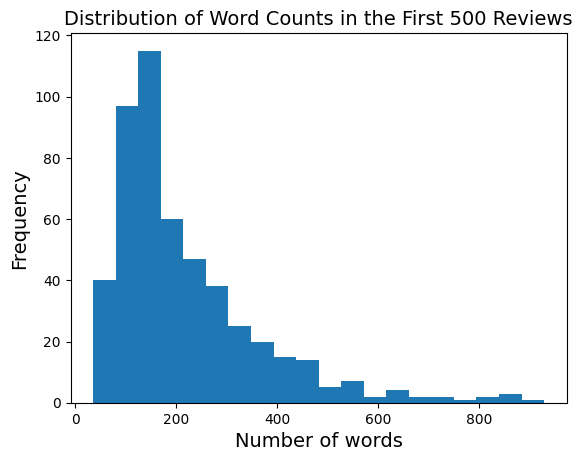

In [11]:
# calculate the length of words in the first 500 reviews
import matplotlib.pyplot as plt

word_counts = []
for review, _ in raw_train_set.take(500):
    word_counts.append(len(review.numpy().decode("utf-8").split()))
plt.hist(word_counts, bins=20)
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.title("Distribution of Word Counts in the First 500 Reviews")
plt.show()

In [12]:
vocab_size = 1000 # only keep the 1000 most frequent words, and replace the others with <UNK>   
text_vec_layer = tf.keras.layers.TextVectorization(max_tokens=vocab_size)
text_vec_layer.adapt(train_set.map(lambda reviews, labels: reviews))

In [13]:
reviews = train_set.map(lambda reviews, labels: reviews)
reviews

<MapDataset element_spec=TensorSpec(shape=(None,), dtype=tf.string, name=None)>

In [14]:
for review in reviews.take(1):
    print(review.numpy()[0])

b"I just came back from the Montreal premiere of Zero Day...and i'm surprised as hell to find a negative comment on the movie. Basically the blame is about Coccio doing an easy and overplayed social message...well, Mr-I'm-a-reviewer, it's an easy and overplayed critic of movies with a social charge.<br /><br />Not that I want to expose my life here, but I come from a small town with a similar school than these guys go. Reject & ignorance on the menu. Thing is...I understand how can young kids can be driven to do such horror. High schools have became battle fields of conformity. It's a real ugly sight. You need to fight your way into being like the others. It's hard to explain, bit a lot of people dosen't realize that high schools are becoming cemeteries of human intelligence. Meanwhile, parents are closing their eyes and smiling about how their life in their comfortable suburb is perfect.<br /><br />The real motive of the movie isn't about what is driving them. It's about this death-li

In [15]:
text_vec_layer.get_vocabulary() # shows the most frequent words in the training set, with the most frequent word at index 2 (index 0 is reserved for <PAD> and index 1 is reserved for <UNK>)

['',
 '[UNK]',
 'the',
 'and',
 'a',
 'of',
 'to',
 'is',
 'in',
 'it',
 'i',
 'this',
 'that',
 'br',
 'was',
 'as',
 'for',
 'with',
 'movie',
 'but',
 'film',
 'on',
 'not',
 'you',
 'are',
 'his',
 'have',
 'he',
 'be',
 'one',
 'its',
 'at',
 'all',
 'by',
 'an',
 'they',
 'from',
 'who',
 'so',
 'like',
 'her',
 'or',
 'just',
 'about',
 'has',
 'if',
 'out',
 'some',
 'there',
 'what',
 'good',
 'very',
 'when',
 'more',
 'even',
 'she',
 'my',
 'would',
 'up',
 'no',
 'which',
 'only',
 'time',
 'really',
 'story',
 'their',
 'had',
 'were',
 'see',
 'can',
 'me',
 'than',
 'we',
 'much',
 'well',
 'been',
 'get',
 'will',
 'also',
 'into',
 'do',
 'because',
 'people',
 'other',
 'bad',
 'first',
 'great',
 'how',
 'most',
 'him',
 'dont',
 'made',
 'then',
 'movies',
 'make',
 'could',
 'films',
 'way',
 'any',
 'them',
 'after',
 'too',
 'characters',
 'think',
 'watch',
 'two',
 'many',
 'being',
 'character',
 'seen',
 'never',
 'little',
 'plot',
 'acting',
 'where',
 'lo

**Warning**: the following cell will take a few minutes to run and the model will probably not learn anything because we didn't mask the padding tokens (that's the point of the next section).

In [16]:
embed_size = 128
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(vocab_size, embed_size), # maps each word ID to a dense vector of size embed_size
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])

In [17]:
history = model.fit(train_set, validation_data=valid_set, epochs=2)

Epoch 1/2
704/704 [==============================] - 55s 68ms/step - loss: 0.6934 - accuracy: 0.5038 - val_loss: 0.6936 - val_accuracy: 0.4996
Epoch 2/2
704/704 [==============================] - 47s 66ms/step - loss: 0.6952 - accuracy: 0.4989 - val_loss: 0.6939 - val_accuracy: 0.5000


## Masking

Configuring your text embedding layers with native masking prevents padding tokens from skewing the model's parameters:

**Warning**: the following cell will take a while to run (possibly 30 minutes if you are not using a GPU).

In [18]:
embed_size = 128
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(vocab_size, embed_size, mask_zero=True), # mask_zero=True tells the embedding layer to ignore the <PAD> token (ID 0) when processing sequences, which is important for handling variable-length input sequences in RNNs without the padding affecting the model's learning.
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=5)

Epoch 1/5
704/704 [==============================] - 50s 67ms/step - loss: 0.5429 - accuracy: 0.7158 - val_loss: 0.3894 - val_accuracy: 0.8276
Epoch 2/5
704/704 [==============================] - 47s 67ms/step - loss: 0.3335 - accuracy: 0.8564 - val_loss: 0.4318 - val_accuracy: 0.8068
Epoch 3/5
704/704 [==============================] - 47s 67ms/step - loss: 0.2920 - accuracy: 0.8778 - val_loss: 0.3009 - val_accuracy: 0.8728
Epoch 4/5
704/704 [==============================] - 46s 65ms/step - loss: 0.2692 - accuracy: 0.8894 - val_loss: 0.3132 - val_accuracy: 0.8640
Epoch 5/5
704/704 [==============================] - 60s 85ms/step - loss: 0.2535 - accuracy: 0.8953 - val_loss: 0.3499 - val_accuracy: 0.8580


### Critical Configuration: mask_zero=True
1. The layer automatically treats Token ID 0 as the designated padding indicator.
2. It dynamically generates a internal boolean mask matrix passed downstream to layers.
3. Downstream recurrent layers (like LSTM or GRU) read this mask and bypass mathematical state updates
   and gradient backpropagation for all padded regions.


Or using manual masking:

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU
inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)
token_ids = text_vec_layer(inputs)
mask = tf.math.not_equal(token_ids, 0) # creates a boolean mask where True indicates positions of non-padding tokens (IDs not equal to 0) and False indicates positions of padding tokens (IDs equal to 0). This mask will be used by the GRU layer to ignore the padded parts of the input sequences during training and inference.
Z = tf.keras.layers.Embedding(vocab_size, embed_size)(token_ids)
Z = tf.keras.layers.GRU(128, dropout=0.2)(Z, mask=mask)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(Z)
model = tf.keras.Model(inputs=[inputs], outputs=[outputs])

**Warning**: the following cell will take a while to run (possibly 30 minutes if you are not using a GPU).

In [20]:
# extra code – compiles and trains the model, as usual
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=5)

Epoch 1/5
704/704 [==============================] - 50s 65ms/step - loss: 0.4991 - accuracy: 0.7520 - val_loss: 0.3691 - val_accuracy: 0.8468
Epoch 2/5
704/704 [==============================] - 53s 76ms/step - loss: 0.3550 - accuracy: 0.8480 - val_loss: 0.3339 - val_accuracy: 0.8624
Epoch 3/5
704/704 [==============================] - 45s 64ms/step - loss: 0.2940 - accuracy: 0.8795 - val_loss: 0.3052 - val_accuracy: 0.8732
Epoch 4/5
704/704 [==============================] - 55s 78ms/step - loss: 0.2721 - accuracy: 0.8888 - val_loss: 0.3437 - val_accuracy: 0.8492
Epoch 5/5
704/704 [==============================] - 48s 68ms/step - loss: 0.2568 - accuracy: 0.8950 - val_loss: 0.3066 - val_accuracy: 0.8696


In [ ]:
mask

**Extra material: using ragged tensors**

By setting `ragged=True` in the `TextVectorization` layer, we can directly output `tf.RaggedTensor` objects that represent sequences of varying lengths without padding. This allows us to handle variable-length input data more naturally, but it may not be compatible with all downstream layers or operations that expect regular tensors.

In [21]:
text_vec_layer_ragged = tf.keras.layers.TextVectorization(
    max_tokens=vocab_size, ragged=True)
text_vec_layer_ragged.adapt(train_set.map(lambda reviews, labels: reviews))
text_vec_layer_ragged(["Great movie!", "This is DiCaprio's best role."])

<tf.RaggedTensor [[86, 18], [11, 7, 1, 116, 217]]>

**Output Explanation:**

The `tf.RaggedTensor` displays two sequences of integer IDs:
*   `[86, 18]` corresponds to "great" and "movie".
*   `[11, 7, 1, 116, 217]` corresponds to "this", "is", "dicaprio's", "best", and "role".
    *   Note: `1` is the ID for out-of-vocabulary (OOV) tokens, indicating "dicaprio's" was not among the most frequent words in the vocabulary.

Unlike dense tensors which would pad shorter sequences to a uniform length (e.g., a $2 \times 5$ matrix with zeros), the `RaggedTensor` efficiently stores only the actual data, preserving the original varying lengths of the input phrases.

In [22]:
text_vec_layer(["Great movie!", "This is DiCaprio's best role."])

<tf.Tensor: shape=(2, 5), dtype=int64, numpy=
array([[ 86,  18,   0,   0,   0],
       [ 11,   7,   1, 116, 217]], dtype=int64)>

**Warning**: the following cell will take a while to run (possibly 30 minutes if you are not using a GPU).

In [23]:
embed_size = 128
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer_ragged,
    tf.keras.layers.Embedding(vocab_size, embed_size),
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=5)

Epoch 1/5


c:\Users\yuanh\miniconda3\envs\homl_gpu\lib\site-packages\tensorflow\python\framework\indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/sequential_2/gru_3/RaggedToTensor/boolean_mask_1/GatherV2:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/sequential_2/gru_3/RaggedToTensor/boolean_mask/GatherV2:0", shape=(None, 128), dtype=float32), dense_shape=Tensor("gradient_tape/sequential_2/gru_3/RaggedToTensor/Shape:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  warnings.warn(


704/704 [==============================] - 56s 77ms/step - loss: 0.5390 - accuracy: 0.7177 - val_loss: 0.3664 - val_accuracy: 0.8412
Epoch 2/5
704/704 [==============================] - 62s 88ms/step - loss: 0.3261 - accuracy: 0.8620 - val_loss: 0.3826 - val_accuracy: 0.8332
Epoch 3/5
704/704 [==============================] - 97s 138ms/step - loss: 0.2893 - accuracy: 0.8800 - val_loss: 0.3416 - val_accuracy: 0.8520
Epoch 4/5
704/704 [==============================] - 45s 64ms/step - loss: 0.2693 - accuracy: 0.8900 - val_loss: 0.3480 - val_accuracy: 0.8464
Epoch 5/5
704/704 [==============================] - 45s 63ms/step - loss: 0.2521 - accuracy: 0.8987 - val_loss: 0.3114 - val_accuracy: 0.8636


## Reusing Pretrained Embeddings and Language Models

**Warning**: the following cell will take a while to run (possibly an hour if you are not using a GPU).

In [24]:
import os
import tensorflow_hub as hub

os.environ["TFHUB_CACHE_DIR"] = "my_tfhub_cache"
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
model = tf.keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                   trainable=True, dtype=tf.string, input_shape=[]),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

c:\Users\yuanh\miniconda3\envs\homl_gpu\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


- `TFHUB_CACHE_DIR`: This environment variable specifies the directory where TensorFlow Hub will cache downloaded models. By setting it to "my_tfhub_cache", we ensure that any pretrained models we download will be stored in this local directory, which can help speed up future runs and avoid repeated downloads.
- `hub.KerasLayer(...)`: This creates a Keras layer that wraps a pretrained model from TensorFlow Hub. The specified URL points to a pretrained text embedding model (like Universal Sentence Encoder or BERT). 
    - By setting `trainable=True`, we allow the weights of this pretrained model to be fine-tuned during training, which can improve performance on our specific task (sentiment analysis) by adapting the embeddings to our dataset.
    - `dtype=tf.string, input_shape=[]` indicates that this layer expects a single string input (a movie review) and will output a fixed-size vector representation of that input text.

In [27]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 512)               256797824 
                                                                 
 dense_4 (Dense)             (None, 64)                32832     
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 256,830,721
Trainable params: 256,830,721
Non-trainable params: 0
_________________________________________________________________


In [28]:
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10


ResourceExhaustedError: in user code:

    File "c:\Users\yuanh\miniconda3\envs\homl_gpu\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "c:\Users\yuanh\miniconda3\envs\homl_gpu\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\yuanh\miniconda3\envs\homl_gpu\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "c:\Users\yuanh\miniconda3\envs\homl_gpu\lib\site-packages\keras\engine\training.py", line 997, in train_step
        self.optimizer.minimize(loss, self.trainable_variables, tape=tape)
    File "c:\Users\yuanh\miniconda3\envs\homl_gpu\lib\site-packages\keras\optimizers\optimizer_v2\optimizer_v2.py", line 579, in minimize
        return self.apply_gradients(grads_and_vars, name=name)
    File "c:\Users\yuanh\minicon

### MLOps Production Practice: Designing Preprocessing Truncation Barriers

In live environments, malicious or edge-case users might send text inputs containing tens of thousands of words to an unprotected API. If your preprocessing pipeline pads arrays infinitely to match this input without hard constraints, it will instantly saturate GPU VRAM and trigger an **Out-of-Memory (OOM) crash**, knocking down the serving node.

**Best Practice**: Enforce a strict truncation policy at the absolute gateway of your preprocessing pipeline (e.g., using `output_sequence_length=max_length` in a Keras `TextVectorization` layer or validating limits via a Pydantic model in FastAPI). This ensures high-dimensional tensors are bound to predictable memory footprints before hitting the neural weights.


---

# An Encoder–Decoder Network for Neural Machine Translation

Traditional NMT relies on an **Encoder-Decoder (Seq2Seq)** architecture.

* **The Encoder:** Processes the input sequence word-by-word, updating its hidden state. The final hidden state is intended to capture the entire semantic meaning of the sentence.
* **The Decoder:** Takes this final hidden state—known as the **Context Vector**—and uses it as the initial state to generate the output sequence autoregressively (one token at a time).


⚠️ **The Production Bottleneck (The Information Bottleneck):** 

Forcing a model to compress a long, complex 30-word sentence into a single fixed-size vector creates a massive technical bottleneck. As input length increases, translation quality degrades drastically because the early parts of the sentence are "washed out" of the hidden state by the time the encoder finishes.

In [8]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
path = tf.keras.utils.get_file("spa-eng.zip", origin=url, cache_dir="./",
                               extract=True)
text = (Path(path).with_name("spa-eng") / "spa.txt").read_text()

In [9]:
import numpy as np
print("Type of text:", type(text))
text = text.replace("¡", "").replace("¿", "")
pairs = [line.split("\t") for line in text.splitlines()]


Type of text: <class 'str'>


In [10]:
print(f"First 100 characters in the text:\n{text[:100]}")

First 100 characters in the text:
Go.	Ve.
Go.	Vete.
Go.	Vaya.
Go.	Váyase.
Hi.	Hola.
Run!	Corre!
Run.	Corred.
Who?	Quién?
Fire!	Fuego!



- `splitlines()`: This method splits the input string into a list of lines based on newline characters. Each line corresponds to one sentence pair (English and Spanish) in the dataset.
- `split("\t")`: This method splits each line into two parts based on the tab character. The first part is the English sentence, and the second part is the Spanish sentence.

In [11]:
print(f"First 5 sentence pairs:\n{pairs[:5]}")
print(f"\nType of pairs: {type(pairs)}")

First 5 sentence pairs:
[['Go.', 'Ve.'], ['Go.', 'Vete.'], ['Go.', 'Vaya.'], ['Go.', 'Váyase.'], ['Hi.', 'Hola.']]

Type of pairs: <class 'list'>


In [12]:
np.random.seed(42)  # extra code – ensures reproducibility on CPU
np.random.shuffle(pairs)
sentences_en, sentences_es = zip(*pairs)  # separates the pairs into 2 lists

In [13]:
type(sentences_en), type(sentences_es)

(tuple, tuple)

In [14]:
for i in range(3):
    print(sentences_en[i], "=>", sentences_es[i])

How boring! => Qué aburrimiento!
I love sports. => Adoro el deporte.
Would you like to swap jobs? => Te gustaría que intercambiemos los trabajos?


In the following, the `TextVectorization` layer is used to convert the raw text sentences into sequences of integer token IDs. 

- The `vocab_size` parameter limits the number of unique tokens to 1000, which helps manage memory and computational resources while still capturing a wide range of language patterns.
- The `output_sequence_length=max_length` parameter ensures that all output sequences are padded or truncated to a fixed length of `max_length`, which is crucial for batching and feeding into the neural network.



In [15]:
vocab_size = 1000
max_length = 50
text_vec_layer_en = tf.keras.layers.TextVectorization(
    vocab_size, output_sequence_length=max_length)
text_vec_layer_es = tf.keras.layers.TextVectorization(
    vocab_size, output_sequence_length=max_length)
text_vec_layer_en.adapt(sentences_en)
text_vec_layer_es.adapt([f"startofseq {s} endofseq" for s in sentences_es])

`adapt()` is a method that allows the `TextVectorization` layer to learn the vocabulary from the provided dataset. 
- When you call `adapt()` on a dataset, the layer iterates through the dataset to build a vocabulary of the most frequent tokens (up to `vocab_size`) and assigns an integer ID to each token.
- This process is essential for converting raw text into a format that can be processed by the neural network, as the model operates on integer token IDs rather than raw text.

It is noted that `text_vec_layer_es.adapt([f"startofseq {s} endofseq" for s in sentences_es])` is used to adapt the Spanish text vectorization layer with sentences that have special tokens "startofseq" and "endofseq" added. These tokens are crucial for the decoder in the Seq2Seq architecture, as they indicate the beginning and end of the output sequence, allowing the model to learn when to start and stop generating translations.

In [16]:
text_vec_layer_en.get_vocabulary()

['',
 '[UNK]',
 'the',
 'i',
 'to',
 'you',
 'tom',
 'a',
 'is',
 'he',
 'in',
 'of',
 'that',
 'it',
 'was',
 'do',
 'have',
 'this',
 'me',
 'my',
 'for',
 'she',
 'dont',
 'are',
 'what',
 'his',
 'mary',
 'we',
 'your',
 'on',
 'be',
 'with',
 'want',
 'not',
 'im',
 'and',
 'like',
 'at',
 'know',
 'him',
 'can',
 'go',
 'her',
 'has',
 'will',
 'its',
 'there',
 'they',
 'time',
 'how',
 'did',
 'as',
 'were',
 'very',
 'had',
 'all',
 'about',
 'here',
 'up',
 'didnt',
 'think',
 'get',
 'out',
 'when',
 'from',
 'cant',
 'if',
 'an',
 'no',
 'one',
 'doesnt',
 'going',
 'by',
 'would',
 'why',
 'come',
 'see',
 'good',
 'ill',
 'please',
 'youre',
 'just',
 'who',
 'been',
 'need',
 'so',
 'more',
 'help',
 'tell',
 'but',
 'now',
 'where',
 'than',
 'never',
 'am',
 'got',
 'too',
 'some',
 'us',
 'something',
 'last',
 'take',
 'much',
 'should',
 'day',
 'ive',
 'car',
 'could',
 'money',
 'home',
 'people',
 'work',
 'well',
 'back',
 'really',
 'our',
 'went',
 'many',
 's

In [17]:
text_vec_layer_es.get_vocabulary()[:10]

['', '[UNK]', 'startofseq', 'endofseq', 'de', 'que', 'a', 'no', 'tom', 'la']

The following step involves creating a TensorFlow dataset that pairs the English and Spanish sentences together. This dataset will be used for training an Encoder-Decoder Network using **Teacher Forcing**.

It splits the English-to-Spanish translation dataset into training and validation sets while properly shifting the inputs and targets. 

In [18]:
X_train = tf.constant(sentences_en[:100_000])
X_valid = tf.constant(sentences_en[100_000:])
X_train_dec = tf.constant([f"startofseq {s}" for s in sentences_es[:100_000]])
X_valid_dec = tf.constant([f"startofseq {s}" for s in sentences_es[100_000:]])
Y_train = text_vec_layer_es([f"{s} endofseq" for s in sentences_es[:100_000]])
Y_valid = text_vec_layer_es([f"{s} endofseq" for s in sentences_es[100_000:]])


This code is responsible for preparing the training and validation datasets for a machine translation model, particularly focusing on the decoder part of a sequence-to-sequence (Seq2Seq) model.

First, the code initializes two input tensors (`X_train` and `X_valid`) as the encoder inputs (the source language).
*   `X_train` contains English sentences for training. The first 100,000 sentences are included.
*   `X_valid` contains the remaining English sentences for validation.
*   The `tf.constant()` function is used to convert the Python lists containing strings into immutable constant tensors in TensorFlow. This allows TensorFlow to process these data more efficiently by integrating them into the computation graph.
*   **Why no special tokens?** The Encoder doesn't need a `startofseq` or `endofseq` token. Its only job is to read the raw source sentence from beginning to end and compress it into a hidden context vector.

Next, prepare the decoder input tensors for training and validation (`X_train_dec` and `X_valid_dec`) as the "Teacher Forcing" feed.
*   `X_train_dec` contains Spanish sentences for training. The first 100,000 sentences are included. Each sentence is prefixed with a special marker `"startofseq"`. This marker is crucial for the decoder as it tells it when to begin generating the target sequence (the translation).
*   `X_valid_dec` contains the remaining Spanish sentences for validation. Similar to the training set, these sentences also start with the `"startofseq"` marker.
*   The `tf.constant()` function is used to convert the Python lists containing strings into immutable constant tensors in TensorFlow. This allows TensorFlow to process these data more efficiently by integrating them into the computation graph.
*   **The Alignment Logic:** If the target sentence is "Hola", `X_train_dec` becomes "startofseq Hola". This provides the crucial "first push" (at $t=1$) so the autoregressive decoder knows to begin translating.

Finally, the target tensors (the ground truth) for training and validation (`Y_train` and `Y_valid`) are prepared.
*   `Y_train` consists of the target sequences for training. It is made up of the first 100,000 Spanish sentences. Each sentence is appended with a special marker `"endofseq"`. This marker helps the model learn when to terminate generating the translation sequence.
*   `Y_valid` consists of the target sequences for validation, made up of the remaining Spanish sentences. Similar to `Y_train`, each sentence also ends with the `"endofseq"` marker.
*   Unlike `X_train_dec` and `X_valid_dec`, `Y_train` and `Y_valid` are passed directly to the `text_vec_layer_es` when created. This `TextVectorization` layer converts Spanish sentences with `"endofseq"` markers into their corresponding numeric sequences (integer IDs). This numericalization is a necessary step for deep learning models to handle text data, mapping each word to a unique ID in the vocabulary learned during the `adapt()` phase.
*   **The shift:** The target sequences are shifted by one position relative to the decoder input sequences. This means that for each time step $t$, the model is trained to predict the next token in the sequence, given all previous tokens. For example, if the decoder input is "startofseq Hola", the target output will be "Hola endofseq". This alignment is essential for training the model to generate coherent translations.


In summary, this code batches (for training/validation) and prepares Spanish sentences by adding special start and end markers. It then converts them into TensorFlow tensors (for decoder input) or numeric sequences (for decoder output), ready for sequence-to-sequence model training.


### 🏭 MLOps & Production Practices to Note Here

Looking at this code from an engineering perspective, there are two massive takeaways:

#### 1. The Brilliant Architecture Choice: Preprocessing Inside the Model

Notice that `X_train` and `X_train_dec` are left as raw string constants, but `Y_train` is explicitly pushed through `text_vec_layer_es()` to become numerical integers.

* **Why?** The loss function (like Sparse Categorical Crossentropy) strictly requires integer labels to calculate the error.
* **The Production Win:** By leaving the inputs (`X`) as raw strings, Géron is implying that the `TextVectorization` layer is built **directly into the Keras model itself** as the first layer. When deploying this model to a production server (like TensorFlow Serving), the client can send raw English text via a JSON request, and the model handles the vocabulary lookups internally. This entirely prevents **Training-Serving Skew** (where your production server accidentally uses a different vocabulary dictionary than your training script).

#### 2. The Scalability Bottleneck: In-Memory List Comprehensions

This notebook snippet is optimized for readability and learning, but it is **not production-scalable**.

* **The Problem:** Using Python list comprehensions (`[f"..." for s in sentences]`) forces your machine to load and process all 100,000+ strings directly in the RAM before training even begins. If your dataset had 50 million sentences, this script would trigger an Out-Of-Memory (OOM) crash instantly.
* **The MLOps Solution:** When training large models (like Transformers), engineers never load data this way. Instead, they write the raw data to disk using Protobuf formats like `tf.train.SequenceExample`, which drastically compresses hard drive space and speeds up I/O. Then, they use `tf.data.Dataset.map()` to dynamically append the `startofseq`/`endofseq` tokens on the fly, batch-by-batch, keeping RAM usage near zero.



---

**Would you like to see how an engineer would rewrite this specific code block using a highly scalable `tf.data.Dataset` pipeline to prevent memory crashes?**

```python
import tensorflow as tf

# 1. 事先切分好原始資料 (不預先做任何字串相加)
train_en, train_es = sentences_en[:100_000], sentences_es[:100_000]
valid_en, valid_es = sentences_en[100_000:], sentences_es[100_000:]

# 2. 定義 MLOps 字串處理函數 (此函數會在 C++ 底層執行)
def process_nmt_data(en_sentence, es_sentence):
    """
    動態為每個句子加上控制 Token，並整理成 Keras 期望的 (輸入, 標籤) 格式
    """
    # Encoder 輸入 (來源語言)
    x = en_sentence
    
    # Decoder 輸入 (目標語言 + 開頭) - 使用 tf.strings 而非 Python f-string
    x_dec = tf.strings.join(["startofseq ", es_sentence])
    
    # 標籤答案 (目標語言 + 結尾)
    y = tf.strings.join([es_sentence, " endofseq"])
    
    # Keras 模型需要兩個輸入 (Encoder 與 Decoder)，以及一個輸出 (Y)
    return (x, x_dec), y

# 3. 建立高擴展性的資料管線 (Data Pipeline)
def build_dataset(en_texts, es_texts, batch_size=32):
    # a. 從切片建立資料集 (此時資料仍是輕量狀態)
    dataset = tf.data.Dataset.from_tensor_slices((en_texts, es_texts))
    
    # b. 動態映射字串處理：AUTOTUNE 會自動調用所有 CPU 核心來平行處理字串
    dataset = dataset.map(process_nmt_data, num_parallel_calls=tf.data.AUTOTUNE)
    
    # c. 批次化與 TextVectorization 處理
    # (假設你有自訂的 mapping 函數將字串轉為整數，也可以加在 map 裡，或者交給 Keras 層)
    dataset = dataset.batch(batch_size)
    
    # d. 預取 (Prefetch)：這是保持 GPU 100% 運轉的究極密技
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# 4. 實例化資料集
train_dataset = build_dataset(train_en, train_es)
valid_dataset = build_dataset(valid_en, valid_es)

# 訓練時，只要把 dataset 餵給模型即可
# history = model.fit(train_dataset, validation_data=valid_dataset, epochs=10)
```

The following code snippet demonstrates a classic Encoder-Decoder architecture for Neural Machine Translation (NMT) using Keras. The model consists of an encoder that processes the input sequence and a decoder that generates the output sequence. The encoder uses an LSTM layer to capture the context of the input sentence, while the decoder uses another LSTM layer to generate the translation based on the context provided by the encoder.

**Input Processing:**

**Input Layers:** The model takes raw string (`tf.string`) inputs for both the encoder and decoder. This allows the model to handle raw text directly, which is particularly useful for deployment scenarios where the input may come as plain text.

In [19]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
encoder_inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)
decoder_inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)

**Vectorization:** `text_vec_layer_en` and `text_vec_layer_es` are `TextVectorization` layers that convert raw text into sequences of integer token IDs. The encoder input is processed by `text_vec_layer_en`, while the decoder input is processed by `text_vec_layer_es`. This step is crucial for transforming the text data into a format that can be fed into the neural network.

In [20]:
embed_size = 128 # size of the dense vector representation for each character

encoder_input_ids = text_vec_layer_en(encoder_inputs)
decoder_input_ids = text_vec_layer_es(decoder_inputs)


The resulting tensors `encoder_input_ids` and `decoder_input_ids` will contain the integer IDs corresponding to each character in the input sentences, which can then be fed into the embedding layers to obtain dense vector representations for each character.


**Embedding Layers:** The `Embedding` layer transforms those integer IDs into dense vectors of size 128. This allows the model to learn mathematical relationships between words (e.g., "king" and "queen" will have similar vector representations). `mask_zero=True` ensures that padding tokens are ignored by the RNNs.

In [21]:
encoder_embedding_layer = tf.keras.layers.Embedding(vocab_size, embed_size,
                                                    mask_zero=True)
decoder_embedding_layer = tf.keras.layers.Embedding(vocab_size, embed_size,
                                                    mask_zero=True)


In [22]:
encoder_embeddings = encoder_embedding_layer(encoder_input_ids)
decoder_embeddings = decoder_embedding_layer(decoder_input_ids)

The resulting tensors `encoder_embeddings` and `decoder_embeddings` will contain the embedded representations of the input sentences, which can then be fed into the RNN layers of the encoder and decoder, respectively.


Use `LSTM` layer to build the encoder and decoder of the Seq2Seq model. The encoder processes the input sequence and produces a context vector, while the decoder generates the output sequence based on this context vector. The `return_state=True` argument in the encoder allows us to capture the final hidden state, which is then used to initialize the decoder's hidden state. The decoder is set to return sequences so that we can compute the loss at each time step during training.

In [23]:
encoder = tf.keras.layers.LSTM(512, return_state=True)
encoder_outputs, *encoder_state = encoder(encoder_embeddings)

- `encoder_outputs`: This is a 3D tensor (Batch Size, Timesteps, 512). It contains the hidden state of the LSTM for every step in the input sequence. In Attention mechanisms, these are the vectors used to calculate attention weights over the original input.
- `*encoder_state`: Because an LSTM has two internal states—the Hidden State ($h$) and the Cell State ($c$)—it actually returns three things: [output, h_state, c_state].
    - The * (star) is used to capture all remaining elements into a list.
    - Even if you only need the last hidden state to pass to a decoder, using * ensures that both $h$ and $c$ are captured in the encoder_state list.

In [24]:
decoder = tf.keras.layers.LSTM(512, return_sequences=True)
decoder_outputs = decoder(decoder_embeddings, initial_state=encoder_state)

The `initial_state=encoder_state` argument is the **critical link** between the encoder and the decoder. The `encoder_state` represents the final hidden state produced by the encoder after processing the entire input sequence.

By passing this as the `initial_state`, the decoder's first hidden state ($h_0$) is directly set to the encoder's last hidden state ($h_n$). This crucial step ensures that the decoder's generation process begins with a compressed mathematical representation of the source information.

The `decoder_outputs` object subsequently contains the hidden states for every time step in the output sequence. If the decoder is configured to return its full sequence, these outputs are typically passed through a **Dense layer** with a **Softmax activation function**. This final step determines the probability distribution of the next word in the vocabulary for each time step.

In [25]:
output_layer = tf.keras.layers.Dense(vocab_size, activation="softmax")
Y_proba = output_layer(decoder_outputs)

- `vocab_size`: The number of unique words in your vocabulary. If your vocabulary has 50,000 words, this layer will have 50,000 neurons. Each neuron represents the "score" for a specific word in your dictionary.
- `activation="softmax"`: The softmax activation function converts the raw output scores (logits) from the Dense layer into probabilities. Each output value will be between 0 and 1, and the sum of all output values will equal 1. This allows us to interpret the output as a probability distribution over the vocabulary, where each value represents the likelihood of that word being the next word in the sequence.

- `Y_proba = output_layers(decoder_outputs)`: 
This line applies the Dense layer (with softmax activation) to the decoder outputs. 
    - `decoder_outputs` tensor contains the hidden states for each time step of the decoder. When passed through the Dense layer, it produces a new tensor `Y_proba` that contains the probability distribution over the vocabulary for each time step in the output sequence.
    - `Y_proba` will have a shape of (Batch Size, Output Timesteps, Vocabulary Size), where each entry represents the probability of each word in the vocabulary being the next word in the output sequence at each time step. This is the final output of the model that can be used to compute the loss during training or to generate translations during inference. 

Finally, it shows the final step of the decoding process, where the output from the decoder LSTM is passed through a Dense layer with a softmax activation to produce a probability distribution over the target vocabulary for each time step. This allows the model to predict the next word in the sequence during training and inference.

**Warning**: the following cell will take a while to run (possibly a couple hours if you are not using a GPU).

In [26]:
model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])

It defines the **Functional API** model for the Seq2Seq architecture. The model takes two inputs: the encoder input (English sentences) and the decoder input (Spanish sentences with a start token). The output is the probability distribution over the Spanish vocabulary for each time step in the output sequence.

1.  **`inputs=[encoder_inputs, decoder_inputs]`**: This argument specifies the input tensors that the model will expect when it is called (e.g., during training or inference).
    *   `encoder_inputs`: This typically represents the input sequence to the encoder part of a sequence-to-sequence model. For example, if you're translating from English to French, `encoder_inputs` would be the tokenized English sentence.
    *   `decoder_inputs`: This usually represents the input sequence to the decoder. In a sequence-to-sequence model, this often consists of the target sequence, possibly shifted by one time step, along with a special "start-of-sequence" token. It provides the initial context for the decoder to start generating its output.
    *   The use of a list `[encoder_inputs, decoder_inputs]` indicates that this model takes *two distinct input streams*. This is characteristic of encoder-decoder architectures where the encoder processes one input (the source sequence) and the decoder processes another (the target sequence, or a shifted version of it) while also being conditioned on the encoder's output.

2.  **`outputs=[Y_proba]`**: This argument specifies the output tensors that the model will produce.
    *   `Y_proba`: This variable likely represents the probability distribution over the vocabulary for each time step of the decoder's output. In a sequence-to-sequence task like machine translation, this would be the predicted probability of each possible next word in the target language. The use of a list `[Y_proba]` means this model produces a single output, which is the sequence of probabilities from the decoder.

In essence, it constructs a complete neural network model, likely an encoder-decoder architecture for sequence-to-sequence tasks (like machine translation or text summarization), by defining its entry points (`encoder_inputs`, `decoder_inputs`) and its final output (`Y_proba`). When you train this `model`, it will learn to map the provided encoder and decoder inputs to the desired target sequence probabilities.

In [27]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None,)]            0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None,)]            0           []                               
                                                                                                  
 text_vectorization (TextVector  (None, 50)          0           ['input_1[0][0]']                
 ization)                                                                                         
                                                                                                  
 text_vectorization_1 (TextVect  (None, 50)          0           ['input_2[0][0]']            

In [28]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit((X_train, X_train_dec), Y_train, epochs=10,
          validation_data=((X_valid, X_valid_dec), Y_valid))

Epoch 1/10
3125/3125 [==============================] - 88s 25ms/step - loss: 0.4141 - accuracy: 0.4265 - val_loss: 0.3074 - val_accuracy: 0.5240
Epoch 2/10
3125/3125 [==============================] - 83s 27ms/step - loss: 0.2643 - accuracy: 0.5736 - val_loss: 0.2378 - val_accuracy: 0.6062
Epoch 3/10
3125/3125 [==============================] - 82s 26ms/step - loss: 0.2078 - accuracy: 0.6437 - val_loss: 0.2064 - val_accuracy: 0.6496
Epoch 4/10
3125/3125 [==============================] - 81s 26ms/step - loss: 0.1749 - accuracy: 0.6888 - val_loss: 0.1930 - val_accuracy: 0.6671
Epoch 5/10
3125/3125 [==============================] - 82s 26ms/step - loss: 0.1514 - accuracy: 0.7225 - val_loss: 0.1865 - val_accuracy: 0.6769
Epoch 6/10
3125/3125 [==============================] - 95s 30ms/step - loss: 0.1325 - accuracy: 0.7508 - val_loss: 0.1852 - val_accuracy: 0.6792
Epoch 7/10
3125/3125 [==============================] - 160s 51ms/step - loss: 0.1161 - accuracy: 0.7761 - val_loss: 0.1864 

The `translate` function presented here is designed to perform inference (translation) using a trained sequence-to-sequence (seq2seq) neural network model. It implements a common decoding strategy known as **greedy search** to generate a translation word by word.

In [29]:
def translate(sentence_en):
    translation = ""
    X = np.array([sentence_en])  # encoder input
    for word_idx in range(max_length):
        X_dec = np.array(["startofseq " + translation])  # decoder input
        y_proba = model.predict((X, X_dec))[0, word_idx]  # last token's probas
        predicted_word_id = np.argmax(y_proba)
        predicted_word = text_vec_layer_es.get_vocabulary()[predicted_word_id]
        if predicted_word == "endofseq":
            break
        translation += " " + predicted_word
    return translation.strip()

The function takes one argument, `sentence_en`, which is the English sentence to be translated. It initializes an empty string `translation` that will progressively build the translated Spanish sentence. The core of the translation process is a `for` loop that iterates up to `max_length` times. `max_length` typically represents the maximum expected length of the output sequence and acts as a safeguard to prevent infinite loops in decoding.

Inside the loop, for each step of the translation, the model requires two inputs:
1.  **`X = np.array([sentence_en])`**: This is the input to the encoder. It's the original English sentence, converted into a NumPy array, which remains constant throughout the translation of a single sentence. The `model` (from the previous context) expects this as one of its inputs.
2.  **`X_dec = np.array(["startofseq " + translation])`**: This is the input to the decoder. It represents the partially translated sentence so far, prefixed with a special "start-of-sequence" token (`"startofseq"`). In each iteration, the `translation` string grows, so `X_dec` provides the decoder with the context of what has already been generated. The decoder then predicts the *next* word based on the original English sentence (`X`) and the already translated sequence (`X_dec`).

The line `y_proba = model.predict((X, X_dec))[0, word_idx]` is crucial. It calls the `predict` method of the `tf.keras.Model` (our seq2seq model) with both the encoder and decoder inputs. The model outputs a probability distribution `y_proba` over the entire vocabulary for each possible next word in the sequence. 
- `[0, word_idx]` is used to extract the probability distribution for the *current* word being predicted. 
- Since `model.predict` often returns a batch of predictions, `[0]` selects the prediction for the first (and in this case, only) sentence in the batch, and `[word_idx]` selects the output at the current time step (though the indexing here can be tricky depending on how the `model`'s output layer is structured and if it's predicting a full sequence or just the next token).

**Selection of the Next Word:**
After obtaining the probability distribution `y_proba`, `predicted_word_id = np.argmax(y_proba)` performs the greedy selection. It finds the index of the word with the highest probability, which is considered the most likely next word. This `predicted_word_id` is then converted back to its string representation using `text_vec_layer_es.get_vocabulary()[predicted_word_id]`. `text_vec_layer_es` is likely a `TextVectorization` layer or a similar utility responsible for mapping integer IDs back to actual Spanish words.

**Stopping Condition:**
The function includes a crucial stopping condition: `if predicted_word == "endofseq": break`. Once the model predicts the "end-of-sequence" token, it signifies that the translation is complete, and the loop terminates. If the translation isn't complete and the word is not "endofseq", the `predicted_word` is appended to the `translation` string, and the loop continues to predict the next word. Finally, `return translation.strip()` returns the complete translated sentence, with any leading or trailing whitespace removed.

In [30]:
translate("I like soccer")

1/1 [==============================] - 0s 34ms/step


'me gusta el fútbol'

Nice! However, the model struggles with longer sentences:

In [31]:
translate("I like soccer and also going to the beach")

1/1 [==============================] - 0s 41ms/step


'me gusta la comida y la [UNK] para ir'

## Bidirectional RNNs

In this section, we explore a powerful architectural extension of standard Recurrent Neural Networks (RNNs). While a standard RNN processes information in one direction—typically from past to future—**a Bidirectional RNN (BRNN) captures dependencies in both directions simultaneously**.

### Key Concepts covered:
*   **Forward Pass:** Captures information from the beginning of the sequence to the current time step ($t$).
*   **Backward Pass:** Processes the sequence in reverse, capturing information from the "future" (relative to $t$) back to the current step.
*   **Hidden State Fusion:** At each time step $t$, the model combines the hidden states from both the forward and backward passes. This allows the model to have a more holistic "contextual awareness."

### Why this matters for NLP:
In many tasks, like **Named Entity Recognition (NER)** or **Part-of-Speech (POS) tagging**, the meaning of a word often depends on what comes *before* it and what comes *after* it. For example, in the sentence *"I am going to the bank,"* the word "bank" is disambiguated by the preceding words. A Bidirectional RNN ensures that at every step of the sequence, the model has access to both the history and the future context.

To create a bidirectional recurrent layer, just wrap a regular recurrent layer in a `Bidirectional` layer:

In [32]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
encoder = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(256, return_state=True))

- wrap a 256-unit LSTM layer in a `Bidirectional` wrapper, which will create two separate LSTM layers (one for the forward pass and one for the backward pass).

In [33]:
encoder_outputs, *encoder_state = encoder(encoder_embeddings)

The model returns a tuple of 5 tensors. The Python `*` (asterisk) operator can be used to unpack them as follows:

- **`encoder_outputs`**: The sequence of outputs across all time steps (usually ignored in basic Seq2Seq encoders).
- **`*encoder_state`**: This gathers the remaining 4 tensors into a list. Because the layer is a `Bidirectional` LSTM, Keras returns these states in a specific order:
    - Index 0: Forward $h$ (Hidden State)
    - Index 1: Forward $C$ (Cell State)
    - Index 2: Backward $h$ (Hidden State)
    - Index 3: Backward $C$ (Cell State)

In [34]:
encoder_state = [tf.concat(encoder_state[::2], axis=-1),  # short-term (0 & 2)
                 tf.concat(encoder_state[1::2], axis=-1)]  # long-term (1 & 3)

### Why are we stitching states? (The Problem)
We need to pass the hidden states from the Encoder to the Decoder. However, there is a structural mismatch:
*   **Encoder:** Uses a **Bidirectional LSTM**, which produces two sets of hidden states for every step (Forward and Backward). This results in 4 tensors total ($h_{fwd}, C_{fwd}, h_{bwd}, C_{bwd}$), where $h$ is the hidden state and $C$ is the cell state.
*   **Decoder:** Typically uses a **Unidirectional LSTM**, which only accepts 2 tensors (one $h$ and one $C$).

### The Solution: "Stitching" the States
To make these two components compatible, we combine the forward and backward passes into single unified vectors. 

Imagine the four states are laid out as $[h_{fwd}, C_{fwd}, h_{bwd}, C_{bwd}]$. We use Python slicing to group them:

*   **Short-Term Memory ($h_t$):** 
    We take every second element starting from index 0 (`[::2]`). This grabs $h_{fwd}$ and $h_{bwd}$, concatenating them into a single **512-dimensional** vector (256 + 256).
*   **Long-Term Memory ($C_t$):** 
    We take every second element starting from index 1 (`[1::2]`). This grabs $C_{fwd}$ and $C_{bwd}$, concatenating them into a single **512-dimensional** vector.

### The Result
The final `encoder_state` is now a list of exactly two tensors: `[Combined_h, Combined_C]`. 

This perfectly matches the input requirements of the Decoder's `initial_state`, effectively condensing all information from both directions into a single "Context Vector."

**Warning**: the following cell will take a while to run (possibly a couple hours if you are not using a GPU).

In [35]:
# extra code — completes the model and trains it
decoder = tf.keras.layers.LSTM(512, return_sequences=True)
decoder_outputs = decoder(decoder_embeddings, initial_state=encoder_state)
output_layer = tf.keras.layers.Dense(vocab_size, activation="softmax")
Y_proba = output_layer(decoder_outputs)
model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit((X_train, X_train_dec), Y_train, epochs=10,
          validation_data=((X_valid, X_valid_dec), Y_valid))

Epoch 1/10
3125/3125 [==============================] - 121s 36ms/step - loss: 0.3093 - accuracy: 0.5378 - val_loss: 0.2204 - val_accuracy: 0.6317
Epoch 2/10
3125/3125 [==============================] - 109s 35ms/step - loss: 0.1923 - accuracy: 0.6684 - val_loss: 0.1880 - val_accuracy: 0.6728
Epoch 3/10
3125/3125 [==============================] - 110s 35ms/step - loss: 0.1605 - accuracy: 0.7120 - val_loss: 0.1759 - val_accuracy: 0.6929
Epoch 4/10
3125/3125 [==============================] - 112s 36ms/step - loss: 0.1397 - accuracy: 0.7419 - val_loss: 0.1708 - val_accuracy: 0.6999
Epoch 5/10
3125/3125 [==============================] - 118s 38ms/step - loss: 0.1227 - accuracy: 0.7672 - val_loss: 0.1709 - val_accuracy: 0.7016
Epoch 6/10
3125/3125 [==============================] - 112s 36ms/step - loss: 0.1083 - accuracy: 0.7892 - val_loss: 0.1734 - val_accuracy: 0.6989
Epoch 7/10
3125/3125 [==============================] - 112s 36ms/step - loss: 0.0958 - accuracy: 0.8097 - val_loss: 0

In [36]:
translate("I like soccer")

1/1 [==============================] - 0s 27ms/step


'me gusta el fútbol'

---
## Beam Search

### The Mechanics of Beam Search

This is a fundamental implementation of **Beam Search**. While written for readability rather than raw speed, it clearly illustrates the core iterative algorithm used in sequence-to-sequence models:

1. **Initialization:** The model evaluates the first step and selects the top $k$ most probable starting words (where $k$ is the **beam width**).
2. **Expansion:** For each of these $k$ translations, the model calculates the conditional probabilities of *all* possible next words in the vocabulary.
3. **Pruning:** All these new extended sequences are pooled together. The algorithm sorts them and keeps only the top $k$ candidates with the highest overall probability, discarding the rest.
4. **Iteration:** Steps 2 and 3 are repeated until every candidate sequence in the beam reaches the End-of-Sequence (`EOS`) token.
5. **Selection:** The single candidate with the highest final score is returned (with the `EOS` token stripped off).

### The Mathematical Bottleneck: Floating-Point Underflow

As we build a sentence $S'$ by concatenating a new word $W$ to an existing sequence $S$, the probability of that new sentence is the product of their probabilities:

$$p(S') = p(S) \times p(W|S)$$

**The Problem:** Probabilities are fractions between 0 and 1. As you multiply many fractions together across a long sentence, the resulting number shrinks exponentially. Eventually, the number becomes so infinitesimally small that the computer's hardware rounds it down to absolute zero. This is known as a **floating-point precision error** (or underflow), and it destroys the model's ability to rank long sentences.

**The Solution: Log Probabilities**
To bypass this hardware limitation, engineers track the *logarithm* of the probabilities instead. Because of the mathematical property $\log(a \times b) = \log(a) + \log(b)$, we can replace volatile multiplication with stable addition:

$$\log(p(S')) = \log(p(S)) + \log(p(W|S))$$

By adding negative log values together, the numbers grow in magnitude safely, entirely preventing underflow while preserving the exact same ranking order of the candidates.

### 🏭 MLOps & Production Practices

Connecting this textbook algorithm to the realities detailed in your **"NLP MLOps: From Theory to Practice"** notebook:

* **The Python Loop Bottleneck:** The text notes this implementation is "not optimized for speed." In production, you never evaluate candidates using standard Python `for` loops. Everything must be **vectorized**—batched together into a single large tensor matrix so the GPU's hardware can calculate all $k$ expansions simultaneously.
* **The Compute/Latency Trade-off:** Increasing the beam width $k$ from 3 to 10 might yield a slightly more poetic translation, but it forces your backend server to do exponentially more math and hold exponentially more state in its RAM. In a live production API (like Google Translate), latency is king. Engineers carefully tune $k$ to find the absolute minimum beam width that still provides acceptable accuracy to keep server response times under a few hundred milliseconds.

In [37]:
import numpy as np
import tensorflow as tf

def beam_search(english_sentence, beam_width, verbose=False):
    """
    Performs beam search decoding for Neural Machine Translation.

    This function iteratively generates translations by keeping track of the 'beam_width'
    most promising partial translations at each step, instead of just the single
    most probable one (greedy search).

    Args:
        english_sentence (str): The input English sentence to translate.
        beam_width (int): The number of top-scoring partial translations to keep
                          at each decoding step.
        verbose (bool): If True, prints intermediate top translations for debugging.

    Returns:
        str: The best translated Spanish sentence found by beam search,
             with the "endofseq" token removed.
    """
    # Encoder input remains constant throughout the translation of one sentence
    encoder_input_batch = np.array([english_sentence])

    # Initial decoder input: "startofseq" token to begin translation
    initial_decoder_input = np.array(["startofseq"])

    # Predict probabilities for the first token based on the initial decoder input
    # model.predict returns (batch_size, sequence_length, vocab_size)
    # [0, 0] selects the probabilities for the first token of the first sentence in the batch
    first_token_probas = model.predict((encoder_input_batch, initial_decoder_input))[0, 0]

    # Get the top 'beam_width' initial words and their probabilities
    top_k_first_tokens = tf.math.top_k(first_token_probas, k=beam_width)

    # Initialize a list of (log_probability, partial_translation) tuples
    # Log probabilities are used to prevent numerical underflow when multiplying many small probabilities.
    top_translations_candidates = [
        (np.log(token_probability), text_vec_layer_es.get_vocabulary()[token_id])
        for token_probability, token_id in zip(top_k_first_tokens.values, top_k_first_tokens.indices)
    ]

    # Optional: display the top initial words for verbose mode
    if verbose:
        print("Top first words:", top_translations_candidates)

    # Iterate through each decoding step up to the maximum output length
    for current_step_idx in range(1, max_length):
        all_candidates_at_step = []

        # Expand each current best partial translation
        for log_proba_so_far, partial_translation in top_translations_candidates:
            # If a translation is already finished, keep it as is
            if partial_translation.endswith("endofseq"):
                all_candidates_at_step.append((log_proba_so_far, partial_translation))
                continue

            # Prepare decoder input for the current partial translation
            # This involves re-feeding the entire partial sequence
            current_decoder_input = np.array(["startofseq " + partial_translation])

            # Predict probabilities for the next token, given the current partial translation
            # [0, current_step_idx] selects the probabilities for the next token at this step
            next_token_probas = model.predict((encoder_input_batch, current_decoder_input))[0, current_step_idx]

            # Generate all possible extensions for the current partial translation
            for token_id, token_probability in enumerate(next_token_probas):
                next_word = text_vec_layer_es.get_vocabulary()[token_id]
                new_log_proba = log_proba_so_far + np.log(token_probability)
                new_translation = f"{partial_translation} {next_word}"
                all_candidates_at_step.append((new_log_proba, new_translation))

        # Sort all generated candidates by their log-probability and keep only the top 'beam_width'
        top_translations_candidates = sorted(all_candidates_at_step, reverse=True)[:beam_width]

        # Optional: display the top translations at the current step for verbose mode
        if verbose:
            print(f"Top translations at step {current_step_idx}:", top_translations_candidates)

        # Check if all top translations have reached the "endofseq" token
        # If so, the beam search can terminate early.
        if all(tr.endswith("endofseq") for _, tr in top_translations_candidates):
            # Return the best translation (highest log-probability) after removing the "endofseq" marker
            return top_translations_candidates[0][1].replace("endofseq", "").strip()

    # If max_length is reached and not all translations ended, return the best one
    return top_translations_candidates[0][1].replace("endofseq", "").strip()


This section delves into the foundational implementation of **Beam Search**, a core decoding algorithm in Natural Language Processing (NLP). This pedagogical code illustrates how machine translation models evolve beyond simple greedy decoding by *simultaneously tracking multiple potential translation paths* to discover the most optimal one.

We will first dissect the logic of this code, then adopt an **MLOps Engineer's** perspective to discuss the catastrophic consequences if this code were deployed directly into a production environment, and finally, how the industry addresses and optimizes these critical challenges.

#### 🧠 In-Depth Code Logic Breakdown

The operation of this code can be divided into four distinct phases:

##### 1. Initialization and Log Probabilities (Initialization & Log Probas)

```python
X = np.array([sentence_en])  # Fixed Encoder Input (Original sentence)
X_dec = np.array(["startofseq"])  # Initial Decoder Input
y_proba = model.predict((X, X_dec))[0, 0]  # Predict probability distribution for the first word
top_k = tf.math.top_k(y_proba, k=beam_width) # Extract the top k words with highest probabilities
```



*   **Logic:** The model first processes the original English sentence and the `<startofseq>` token, then outputs the probability distribution for all words in the vocabulary to be the "first word" of the translation. Instead of merely selecting the single most probable word (which is greedy decoding), we identify and keep the top $k$ words, where $k$ is the `beam_width`.
*   **Mathematical Defense Mechanism:** In the subsequent `top_translations` list comprehension, the code utilizes `np.log(word_proba)`.
*   **Reason:** The total probability of a sentence is the **product** of each individual word's probability (e.g., $0.1 \times 0.2 \times 0.05...$). As a sentence lengthens, this product shrinks exponentially, eventually leading to a **floating-point underflow** in hardware, where the value effectively becomes an absolute `0`.
*   **Solution:** By leveraging the logarithmic property $\log(A \times B) = \log(A) + \log(B)$, we transform the problematic "multiplication of small numbers" into "addition of negative numbers," effectively circumventing hardware limitations and maintaining numerical stability.

2. Setup for the Beam Search candidates:

```python
    # Initialize a list of (log_probability, partial_translation) tuples
    # Log probabilities are used to prevent numerical underflow when multiplying many small probabilities.
    top_translations_candidates = [
        (np.log(token_probability), text_vec_layer_es.get_vocabulary()[token_id])
        for token_probability, token_id in zip(top_k_first_tokens.values, top_k_first_tokens.indices)
    ]
```
*   **Logic:** This list comprehension initializes the beam with the top $k$ candidate translations. Each candidate is represented as a tuple containing the log probability of the candidate and the corresponding word (converted from its token ID back to a string using `text_vec_layer_es.get_vocabulary()`).
*   **Mathematical Defense Mechanism:** The use of `np.log(token_probability)` ensures that we are working with log probabilities from the very beginning, which is crucial for maintaining numerical stability as we expand the beam in subsequent iterations. This prevents the underflow issue that would arise if we were to multiply small probabilities directly.
*   **MLOps Note:** In a production environment, this step would be vectorized to handle all $k$ candidates simultaneously on the GPU, rather than using a Python list comprehension, which is inefficient for large beam widths.
*   `text_vec_layer_es.get_vocabulary()[token_id]` converts the token ID back to its corresponding word in the Spanish vocabulary, allowing us to keep track of the actual translations alongside their probabilities.


##### 3. Expansion of Candidate Paths (Expansion)

```python
for idx in range(1, max_length):
    candidates = []
    for log_proba, translation in top_translations:
        # (omitted) ...
        X_dec = np.array(["startofseq " + translation])  # Combine the partial sentence translated so far
        y_proba = model.predict((X, X_dec))[0, idx]  # Predict the next word
```


*   **Logic:** Within the loop, we expand the $k$ currently retained candidate sentences. Each candidate sentence (e.g., "startofseq He") is re-fed to the model to predict its "next word." If the vocabulary contains 10,000 words, this step will generate $k \times 10,000$ new branching combinations.


##### 4. Pruning

```python
    for word_id, word_proba in enumerate(y_proba):
        word = text_vec_layer_es.get_vocabulary()[word_id]
        candidates.append((log_proba + np.log(word_proba), f"{translation} {word}"))
top_translations = sorted(candidates, reverse=True)[:beam_width]
```


*   **Logic:** This is the core of Beam Search. We do not retain all tens of thousands of new branches (which would quickly exhaust memory); instead, all `candidates` are sorted by their cumulative log-probabilities, and we **ruthlessly prune** them, consistently keeping only the top $k$ (`[:beam_width]`) paths with the highest scores.
*   `log_proba + np.log(word_proba)` updates the cumulative log probability for each candidate by adding the log probability of the newly predicted word to the existing log probability of the partial translation. This maintains numerical stability while allowing us to compare and rank candidates effectively.
*   `reverse=True` ensures that the sorting is done in descending order, so the candidates with the highest log probabilities (i.e., the most likely translations) are at the front of the list.


##### 5. Termination Condition (Termination)
```python
    if all([tr.endswith("endofseq") for _, tr in top_translations]):
        return top_translations[0][1].replace("endofseq", "").strip()
```
*   **Logic:** If all $k$ surviving paths ultimately predict the `<endofseq>` token, the loop terminates early, and the translated sentence with the highest cumulative log-probability is returned.

---

#### 🏭 The Harsh Realities of Production Environments (MLOps & Engineering)

As indicated in your **"NLP MLOps: From Theory to Practice"** notes, this code is designed for "readability." Deploying this exact code directly to a company's online API would cause the server to crash instantly. Below are the critical pain points that MLOps engineers must optimize in practice:

##### ❌ Fatal Flaw 1: No KV-Cache, leading to $O(N^2)$ redundant computations

Observe this line of code:
`X_dec = np.array(["startofseq " + translation])`
Every time a new word is predicted, it **re-feeds the entire translated prefix string** to the model.

*   **Production Perspective:** If you have already translated 20 words, to predict the 21st word, the model must re-calculate the matrix multiplications and hidden states for all previous 20 words from scratch! This results in extremely severe computational waste.
*   **Industry Solution:** Modern production-grade Seq2Seq and Transformer models (such as GPT architectures) implement **KV-Cache (Key-Value Caching)**. When generating the $t$-th word, the model caches previously computed states (Keys and Values) in GPU memory. This means only a forward pass for the latest "single word" is required, significantly reducing latency.

##### ❌ Fatal Flaw 2: GIL Blocking caused by Python `for` loops

This code uses multiple nested Python `for` loops to iterate through `top_translations` and expand words.

*   **Production Perspective:** Python's Global Interpreter Lock (GIL) prevents `for` loops from being easily parallelized on the GPU during execution. When `beam_width` increases, this code will be processed sequentially and slowly on a single CPU core, leading to bottlenecks.
*   **Industry Solution:** In TensorFlow or PyTorch production deployments, Beam Search must be **fully vectorized**. Engineers stack $k$ paths into a single batch tensor (e.g., `[beam_width, sequence_length]`) and compute the next step for all $k$ paths simultaneously with a single, highly optimized GPU matrix operation, completely eliminating the Python loop bottleneck.

##### ❌ Fatal Flaw 3: Unconditional Length Penalty Missing

*   **Production Perspective:** Log probabilities are negative numbers that are added together. This intrinsically means "the longer the sentence, the lower the total score." This purely foundational code would lead the model to strongly prefer generating "very short sentences" (because fewer negative log-probabilities are accumulated).
*   **Industry Solution:** In practice, Beam Search incorporates a **Length Penalty mechanism**. This typically involves dividing the final cumulative log-probability by the sentence length (or some exponent $\alpha$) to balance the fairness between long and short sentences. Without this, your translation system would continuously produce overly short, incomplete translations when encountering complex long sentences.

In [38]:
# extra code – shows how the model making an error
sentence_en = "I love cats and dogs"
translate(sentence_en)

1/1 [==============================] - 0s 33ms/step


'me encanta la carne de los perros'

In [39]:
# extra code – shows how beam search can help
beam_search(sentence_en, beam_width=3, verbose=True)

1/1 [==============================] - 0s 30ms/step
Top first words: [(-0.21876183, 'me'), (-2.256368, '[UNK]'), (-2.789969, 'yo')]
1/1 [==============================] - 0s 42ms/step
Top translations at step 1: [(-0.4513703, 'me encanta'), (-2.4728405, '[UNK] los'), (-2.7220042, 'me [UNK]')]
1/1 [==============================] - 0s 24ms/step
Top translations at step 2: [(-0.91334504, 'me encanta la'), (-1.7516837, 'me encanta los'), (-2.730486, 'me [UNK] los')]
1/1 [==============================] - 0s 44ms/step
Top translations at step 3: [(-1.0524074, 'me encanta la carne'), (-2.3166804, 'me encanta los perros'), (-2.7779174, 'me encanta los gatos')]
1/1 [==============================] - 0s 49ms/step
Top translations at step 4: [(-1.4178882, 'me encanta la carne de'), (-2.6188493, 'me encanta la carne y'), (-2.8071878, 'me encanta los perros y')]
1/1 [==============================] - 0s 45ms/step
Top translations at step 5: [(-1.5514715, 'me encanta la carne de los'), (-2.673557,

'me encanta la carne de los perros'

The correct translation is in the top 3 sentences found by beam search, but it's not the first. Since we're using a small vocabulary, the \[UNK] token is quite frequent, so you may want to penalize it (e.g., divide its probability by 2 in the beam search function): this will discourage beam search from using it too much.

Beam search significantly elevates translation quality but comes with a steep compute penalty. A beam width of $K=5$ means running 5 parallel decoding loops for every single word generated, multiplying API latency. Furthermore, unmitigated models encountering out-of-vocabulary words frequently fall back on producing safe, repetitive loops of `UNK` (Unknown) tokens.
Optimization Blueprint: Live production instances limit beam width to a narrow window (typically $K=3$ to $5$). To combat latency, engineer **KV-Caching (Key-Value Caching)** into your inference engines to avoid recomputing past attention keys. Finally, introduce an explicit penalty score against the `UNK` token's logit distribution during runtime decoding to force the generation of readable, alternative syntax.


---

# Attention Mechanisms

This section introduces **Attention Mechanisms**, a pivotal advancement in Neural Language Processing (NLP), particularly for Encoder-Decoder models (also known as Seq2Seq models).

In earlier Encoder-Decoder architectures, the encoder had to compress the entire input sequence into a single "context vector." This often led to an information bottleneck, especially for long sentences, where early parts of the input could be forgotten by the time the encoder finished processing.

Attention mechanisms address this by allowing the decoder to **"pay attention"** to different parts of the input sequence at each step of generating the output. Instead of relying solely on a fixed-size context vector, the attention mechanism dynamically computes an "alignment score" between the current decoder state and every part of the encoder's output. This allows the model to:

*   **Handle longer sequences more effectively**: The decoder can directly access relevant information from the input, overcoming the information bottleneck.
*   **Improve translation quality**: By focusing on pertinent input segments, the model produces more accurate and coherent translations.
*   **Increase interpretability**: The alignment scores provide insights into which parts of the input the model is focusing on during translation, aiding in debugging and understanding its behavior.

This section will demonstrate how to integrate an Attention layer into an Encoder-Decoder network to enhance its performance, especially when dealing with complex or lengthy sequences.

First, we need to feed all the encoder's outputs to the `Attention` layer, so we must add `return_sequences=True` to the encoder:

In [40]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
encoder = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(256, return_sequences=True, return_state=True))

`return_sequences=True` ensures that the encoder outputs a sequence of hidden states for each time step, rather than just the final hidden state. This is crucial for attention mechanisms, as they require access to the entire sequence of encoder outputs to compute alignment scores with the decoder's current state.

In [ ]:
# extra code – this part of the model is exactly the same as earlier
encoder_outputs, *encoder_state = encoder(encoder_embeddings)
encoder_state = [tf.concat(encoder_state[::2], axis=-1),  # short-term (0 & 2)
                 tf.concat(encoder_state[1::2], axis=-1)]  # long-term (1 & 3)


- `encoder_outputs`: This is a 3D tensor (Batch Size, Timesteps, 512). It contains all hidden states of the LSTM for every step in the input sequence. In Attention mechanisms, these are the vectors used to calculate attention weights over the original input.
- `encoder_state`: Because an LSTM has two internal states—the Hidden State ($h$) and the Cell State ($c$)—it actually returns three things: [output, h_state, c_state].
    - The * (star) is used to capture all remaining elements into a list.
    - Even if you only need the last hidden state to pass to a decoder, using * ensures that both $h$ and $c$ are captured in the encoder_state list.
    - for `Bidirectional` LSTMs, the encoder_state will contain 4 tensors: [$h_{fwd}$, $C_{fwd}$, $h_{bwd}$, $C_{bwd}$]. We will need to "stitch" these together to create a single context vector for the decoder.

Then, the decoder's LSTM layer sets `return_sequences=True` to ensure it outputs a sequence of hidden states, which can be fed into the Attention layer at each time step. The Attention layer will compute a context vector for each decoder time step by attending to the encoder outputs, allowing the decoder to focus on relevant parts of the input sequence when generating each word in the output.

In [ ]:
decoder = tf.keras.layers.LSTM(512, return_sequences=True)
decoder_outputs = decoder(decoder_embeddings, initial_state=encoder_state)

Next, the `decoder` layer is called with `initial_state=encoder_state`, which means the decoder's initial hidden state is set to the encoder's final hidden state. This allows the decoder to start generating the translation based on the context provided by the encoder.

The output, `decoder_outputs`, will be a sequence of hidden states generated by the LSTM for each timestep, reflecting the decoder's processing of `decoder_embeddings` while conditioned on the `encoder_state`. This output sequence can then be passed to further layers (e.g., a Dense layer with a softmax activation) to predict the actual output tokens of the target sequence.

And finally, let's add the `Attention` layer and the output layer:

In [ ]:
attention_layer = tf.keras.layers.Attention()
attention_outputs = attention_layer([decoder_outputs, encoder_outputs])

Here, an attention mechanism is initialized and applied, a crucial component in modern sequence-to-sequence models, especially when dealing with longer sequences where traditional RNNs might struggle with information flow.

First, an instance of `tf.keras.layers.Attention()` is created and assigned to the variable `attention_layer`. This Keras layer implements a standard attention mechanism. At a high level, attention allows a neural network to focus on specific parts of its input sequence when generating an output, rather than relying solely on a fixed-size context vector from the encoder. This mechanism helps to address the bottleneck problem often found in vanilla encoder-decoder architectures, where the entire input sequence has to be compressed into a single, fixed-dimension vector.

Next, the `attention_layer` is called with two inputs: `decoder_outputs` and `encoder_outputs`. In the context of an encoder-decoder model:
*   `decoder_outputs` typically represents the "query" sequence. These are the hidden states generated by the decoder at each timestep. The decoder uses these states to query the encoder's output for relevant information.
*   `encoder_outputs` typically represents the "key" and "value" sequences. These are the hidden states produced by the encoder for each timestep of the input sequence. The attention mechanism will look at these encoder states to determine which parts are most relevant to the current `decoder_outputs`.

The `attention_layer` then computes alignment scores between each element of `decoder_outputs` and each element of `encoder_outputs`. These scores determine how much "attention" each decoder state should pay to each encoder state. Based on these scores, a weighted sum of the `encoder_outputs` is calculated. This weighted sum, known as the "context vector," highlights the most relevant information from the source sequence that corresponds to the current decoder state. The result, `attention_outputs`, is this sequence of context vectors. These context vectors are then typically concatenated with the `decoder_outputs` themselves before being passed to subsequent layers (e.g., a softmax layer for predicting the next token), enabling the decoder to make more informed predictions by selectively focusing on the pertinent parts of the input.
```python
# Concatenate the attention outputs with the decoder outputs
decoder_combined_context = tf.concat([attention_outputs, decoder_outputs], axis=-1)
```

In [ ]:
output_layer = tf.keras.layers.Dense(vocab_size, activation="softmax")
Y_proba = output_layer(attention_outputs)

**Warning**: the following cell will take a while to run (possibly a couple hours if you are not using a GPU).

In [43]:
model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit((X_train, X_train_dec), Y_train, epochs=10,
          validation_data=((X_valid, X_valid_dec), Y_valid))

Epoch 1/10
3125/3125 [==============================] - 104s 31ms/step - loss: 0.3090 - accuracy: 0.5468 - val_loss: 0.2117 - val_accuracy: 0.6525
Epoch 2/10
3125/3125 [==============================] - 103s 33ms/step - loss: 0.1913 - accuracy: 0.6798 - val_loss: 0.1873 - val_accuracy: 0.6854
Epoch 3/10
3125/3125 [==============================] - 114s 36ms/step - loss: 0.1671 - accuracy: 0.7119 - val_loss: 0.1776 - val_accuracy: 0.7008
Epoch 4/10
3125/3125 [==============================] - 116s 37ms/step - loss: 0.1510 - accuracy: 0.7339 - val_loss: 0.1734 - val_accuracy: 0.7069
Epoch 5/10
3125/3125 [==============================] - 112s 36ms/step - loss: 0.1381 - accuracy: 0.7520 - val_loss: 0.1723 - val_accuracy: 0.7105
Epoch 6/10
3125/3125 [==============================] - 110s 35ms/step - loss: 0.1271 - accuracy: 0.7681 - val_loss: 0.1747 - val_accuracy: 0.7088
Epoch 7/10
3125/3125 [==============================] - 110s 35ms/step - loss: 0.1176 - accuracy: 0.7824 - val_loss: 0

In [44]:
translate("I like soccer and also going to the beach")

1/1 [==============================] - 0s 36ms/step


'me gusta la playa y también me va a la playa'

In [45]:
beam_search("I like soccer and also going to the beach", beam_width=3,
            verbose=True)

1/1 [==============================] - 0s 28ms/step
Top first words: [(-0.04293083, 'me'), (-4.700405, 'tengo'), (-5.208124, 'prefiero')]
1/1 [==============================] - 0s 43ms/step
Top translations at step 1: [(-0.05097882, 'me gusta'), (-5.0966296, 'tengo el'), (-5.484151, 'prefiero el')]
1/1 [==============================] - 0s 42ms/step
Top translations at step 2: [(-0.3498156, 'me gusta la'), (-1.6336291, 'me gusta el'), (-4.356954, 'me gusta ir')]
1/1 [==============================] - 0s 47ms/step
Top translations at step 3: [(-0.9643399, 'me gusta la playa'), (-1.6361866, 'me gusta el fútbol'), (-1.9929681, 'me gusta la [UNK]')]
1/1 [==============================] - 0s 45ms/step
Top translations at step 4: [(-0.9844052, 'me gusta la playa y'), (-1.753584, 'me gusta el fútbol y'), (-2.011266, 'me gusta la [UNK] y')]
1/1 [==============================] - 0s 43ms/step
Top translations at step 5: [(-1.0950022, 'me gusta la playa y también'), (-1.8216006, 'me gusta el fút

'me gusta la playa y también me va a la playa'

## Attention Is All You Need: The Transformer Architecture


### 🧠 Core Theory: Replacing Recurrence with Parallel Operations

The Transformer architecture **revolutionized sequence processing by fundamentally abandoning the temporal, step-by-step nature of Recurrent Neural Networks (RNNs)**. This departure addresses a critical limitation: RNNs must calculate hidden states sequentially ($t-1 \rightarrow t$), which creates a serial bottleneck that significantly restricts GPU parallelization.

Transformers overcome this by processing entire text sequences concurrently. They achieve this efficiency by representing tokens as high-dimensional vectors and leveraging **Multi-Head Self-Attention**, a powerful mechanism built upon three specialized vector matrices:

*   **Query (Q)**: Represents what information is being sought.
*   **Key (K)**: Represents the information available to be matched.
*   **Value (V)**: Carries the actual content payload associated with the keys.

The core computation of attention is defined by the formula: $\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$

### Positional encodings: Replacing the RNN Bottleneck

Because Transformers do not process text word-by-word (sequentially), they have no concept of word order. If you feed a Transformer the sentence "The dog bit the man" and "The man bit the dog", it sees the exact same bag of words. We fix this using **Positional Encodings**.

Since self-attention mechanisms inherently process sequences without regard for token order, positional embeddings are added to the token embeddings to inject information about the relative or absolute position of each token within a sequence. This allows the model to understand word order, which is vital for language comprehension. The positional encoding is typically implemented as a fixed sinusoidal function or learned embeddings that are added to the input token embeddings before being fed into the attention layers.

In [46]:
max_length = 50  # max length in the whole training set
embed_size = 128
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
pos_embed_layer = tf.keras.layers.Embedding(max_length, embed_size)
batch_max_len_enc = tf.shape(encoder_embeddings)[1]
encoder_in = encoder_embeddings + pos_embed_layer(tf.range(batch_max_len_enc))
batch_max_len_dec = tf.shape(decoder_embeddings)[1]
decoder_in = decoder_embeddings + pos_embed_layer(tf.range(batch_max_len_dec))

First, two constants are defined: 
- `max_length` specifies the maximum anticipated sequence length in the entire dataset (here, 50 tokens)
- `embed_size` defines the dimensionality of both the token and positional embeddings (128 dimensions).

A `tf.keras.layers.Embedding` layer, named `pos_embed_layer`, is then instantiated. This layer acts as a lookup table, learning a unique embedding vector for each possible position up to `max_length`. Since `max_length` is 50 and `embed_size` is 128, this layer will learn 50 distinct vectors, each 128 dimensions long.

Next, the code dynamically calculates the current batch's sequence length for both the encoder and decoder inputs.
- `tf.shape(encoder_embeddings)[1]` retrieves the sequence length of the `encoder_embeddings` tensor (assuming `encoder_embeddings` has a shape of `[batch_size, sequence_length, embedding_dimension]`). 
- `tf.range(batch_max_len_enc)` then generates a sequence of integers from 0 up to `batch_max_len_enc - 1`, representing the positions of tokens in the current batch. These positional indices are passed to `pos_embed_layer` to retrieve the corresponding positional embedding vectors.

Finally, **the positional embeddings are added to their respective token embeddings**. For the encoder, `encoder_in = encoder_embeddings + pos_embed_layer(tf.range(batch_max_len_enc))` performs an element-wise sum. This combined vector (`encoder_in`) now contains both the semantic information from the token embedding and the positional information from the positional embedding. The same process is repeated for the decoder inputs with `decoder_in = decoder_embeddings + pos_embed_layer(tf.range(batch_max_len_dec))`. This enriched input is then fed into the subsequent layers of the Transformer model.

**Fixed Positional Encodings**

Alternatively, we can use fixed, non-trainable positional encodings:
A custom `PositionalEncoding` layer is defined, which generates fixed sinusoidal positional encodings based on the formula:
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

**Creating a Unique Spatial Signature**

The creators of the Transformer wanted a way to represent a word's position $pos$ in a sentence using a vector of the same size as the word embedding ($d_{model}$). They chose a mix of Sine and Cosine functions of different frequencies. The formula for the Positional Encoding ($PE$) matrix is defined above with the variables:
- $pos$: the position of the word in the sequence (0 for the 1st word, 1 for the 2nd word, etc.).
- $d_{model}$: The dimension of the word embedding (e.g., 512).
- $i$: The index of the specific dimension within that 512-length vector ($0 \le i < d_{model}/2$).
- $2i$ and $2i+1$: This simply means "Even indices get the Sine function, Odd indices get the Cosine function."


🧠 **The Intuition (The Clock Analogy)**

Imagine the hands of a clock. The second hand moves very fast, the minute hand moves slower, and the hour hand moves very slowly.
- At dimension $i=0$ (the first element of the vector), the sine wave has a very high frequency. It oscillates wildly from word to word.
- At dimension $i=255$ (the end of the vector), the wave is stretched out so much that it's practically a flat line across a standard paragraph.By combining these "clocks" of different speeds, **every single position $pos$ gets an absolutely unique sequence of 512 numbers**, while maintaining a smooth, mathematical relationship between relative positions.

This approach allows the model to learn relative positions without the need for additional trainable parameters, and the encodings can be computed on-the-fly for any sequence length up to `max_length`. The positional encodings are then added to the token embeddings in the same way as before, ensuring that the model has access to both semantic and positional information when processing the input sequences.

In [ ]:
import tensorflow as tf
import numpy as np

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_steps, max_dims, dtype=tf.float32, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        
        # 1. Ensure dimensions are even
        if max_dims % 2 == 1: max_dims += 1 
            
        # 2. Vectorized Grid Creation
        p, i = np.meshgrid(np.arange(max_steps), np.arange(max_dims // 2))
        
        # 3. Create an empty matrix of shape (1, max_steps, max_dims)
        pos_emb = np.empty((1, max_steps, max_dims))
        
        # 4. Apply the Math! 
        # Even indices (0, 2, 4...) get the Sine formula
        pos_emb[0, :, ::2] = np.sin(p / 10000**(2 * i / max_dims)).T
        
        # Odd indices (1, 3, 5...) get the Cosine formula
        pos_emb[0, :, 1::2] = np.cos(p / 10000**(2 * i / max_dims)).T
        
        # 5. Convert to a static TensorFlow Constant
        self.positional_embedding = tf.constant(pos_emb.astype(self.dtype))

    def call(self, inputs):
        # 6. Add the fixed positional encoding to the input embeddings
        shape = tf.shape(inputs)
        return inputs + self.positional_embedding[:, :shape[1], :shape[2]]

**Code Breakdown & MLOps Efficiency:**

- Step 2 (`np.meshgrid`): This is the secret to the speed. Instead of looping through `pos` and `i`, `meshgrid` creates a 2D grid of all possible $(pos, i)$ combinations at once. This allows Numpy's underlying C-code to calculate the math in a fraction of a millisecond.
- Step 4 (`::2` and `1::2`): Python list slicing is used to map the math to the vectors. `::2` means "start at index 0, go to the end, stepping by 2" (Even). `1::2` means "start at index 1, go to the end, stepping by 2" (Odd). `.T` transposes the matrix to ensure the shape matches the (max_steps, max_dims) layout.
- Step 5 (`tf.constant`): 🏭 Production Practice! Notice that this math is inside `__init__`, not `call()`. The sine and cosine values are static. By calculating this giant matrix once when the model is initialized and saving it as a `tf.constant`, the layer does zero mathematical calculation during training or inference.
- Step 6 (`call`): The Final Addition. During the forward pass (`call`), the layer dynamically checks the length of the incoming sentence (`shape[1]`), slices the pre-computed `positional_embedding` to match that exact length, and simply adds (`+`) it to the input word embeddings. Because we use addition instead of concatenation, the model doesn't get wider. The positional "frequency" is seamlessly merged into the semantic meaning of the word!

🏭 MLOps & Production Reality:

- **The Hardware Win (GPU Parallelism):** Why go through this complex math? Because eliminating the RNN's step-by-step loop means we can process a 1,000-word sequence in one massive matrix multiplication. Modern NVIDIA GPUs are designed precisely for this. By using Positional Encodings instead of recurrence, we achieve massive throughput scaling in production inference.

- **Modern Keras Practice:** In newer production models, instead of the static sine/cosine math, we often just use a second `tf.keras.layers.Embedding` layer that learns the positional weights during training. It's computationally cheaper and often works just as well.

In [ ]:
pos_embed_layer = PositionalEncoding(max_length, embed_size) # creates a positional encoding layer that can be added to the input embeddings of a Transformer model. The positional encoding provides information about the position of each token in the sequence, which is crucial for models that do not inherently capture sequential order, such as Transformers.

encoder_in = pos_embed_layer(encoder_embeddings) # adds positional encodings to the encoder embeddings, allowing the model to incorporate information about the order of tokens in the input sequence. This is essential for tasks like machine translation, where the position of words affects meaning.
decoder_in = pos_embed_layer(decoder_embeddings) # adds positional encodings to the decoder embeddings, allowing the model to incorporate information about the order of tokens in the output sequence. This is crucial for generating coherent translations, as the position of words in the output affects their meaning and grammatical correctness.

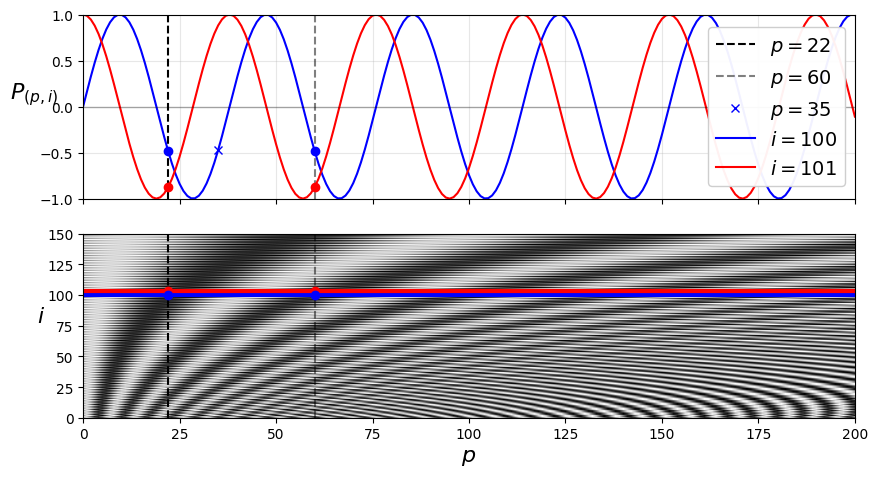

In [49]:
# extra code – this cells generates and saves Figure 16–9
figure_max_length = 201
figure_embed_size = 512
pos_emb = PositionalEncoding(figure_max_length, figure_embed_size)
zeros = np.zeros((1, figure_max_length, figure_embed_size), np.float32)
P = pos_emb(zeros)[0].numpy()
i1, i2, crop_i = 100, 101, 150
p1, p2, p3 = 22, 60, 35
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(9, 5))
ax1.plot([p1, p1], [-1, 1], "k--", label="$p = {}$".format(p1))
ax1.plot([p2, p2], [-1, 1], "k--", label="$p = {}$".format(p2), alpha=0.5)
ax1.plot(p3, P[p3, i1], "bx", label="$p = {}$".format(p3))
ax1.plot(P[:,i1], "b-", label="$i = {}$".format(i1))
ax1.plot(P[:,i2], "r-", label="$i = {}$".format(i2))
ax1.plot([p1, p2], [P[p1, i1], P[p2, i1]], "bo")
ax1.plot([p1, p2], [P[p1, i2], P[p2, i2]], "ro")
ax1.legend(loc="center right", fontsize=14, framealpha=0.95)
ax1.set_ylabel("$P_{(p,i)}$", rotation=0, fontsize=16)
ax1.grid(True, alpha=0.3)
ax1.hlines(0, 0, figure_max_length - 1, color="k", linewidth=1, alpha=0.3)
ax1.axis([0, figure_max_length - 1, -1, 1])
ax2.imshow(P.T[:crop_i], cmap="gray", interpolation="bilinear", aspect="auto")
ax2.hlines(i1, 0, figure_max_length - 1, color="b", linewidth=3)
cheat = 2  # need to raise the red line a bit, or else it hides the blue one
ax2.hlines(i2+cheat, 0, figure_max_length - 1, color="r", linewidth=3)
ax2.plot([p1, p1], [0, crop_i], "k--")
ax2.plot([p2, p2], [0, crop_i], "k--", alpha=0.5)
ax2.plot([p1, p2], [i2+cheat, i2+cheat], "ro")
ax2.plot([p1, p2], [i1, i1], "bo")
ax2.axis([0, figure_max_length - 1, 0, crop_i])
ax2.set_xlabel("$p$", fontsize=16)
ax2.set_ylabel("$i$", rotation=0, fontsize=16)
save_fig("positional_embedding_plot")
plt.show()

**Understanding the Positional Encoding Heatmap**

While the sine and cosine formulas for positional encoding are mathematically abstract, visualizing them as a heatmap reveals their elegant structure. The resulting image resembles a gradient wave pattern that encodes position information.

**Reading the Heatmap**

The heatmap has two axes. The vertical axis (top to bottom) represents token positions in the sequence, with position 0 at the top and position 49 at the bottom. The horizontal axis (left to right) represents the 128 dimensions of the embedding vector, indexed from 0 to 127.

**Interpreting Color Patterns and Frequencies**

The color variations across the heatmap reflect different wave frequencies. On the left side, colors alternate dramatically between adjacent rows (black-white or red-blue), indicating high-frequency oscillations. This corresponds to small dimension indices, where the sine/cosine waves change rapidly, providing fine-grained positional information that distinguishes adjacent tokens.

On the right side, colors transition gradually in large blocks, indicating low-frequency oscillations. This corresponds to large dimension indices, where the waves have long periods, providing coarse-grained positional information that captures relationships across longer distances in the sequence.

**Unique Positional Signatures**

The key insight is that each row (representing a position's embedding vector) has a completely unique color pattern across all 128 dimensions. No two positions produce the same sequence of values. This mathematical uniqueness is what enables the Transformer to distinguish token positions—each position has its own distinctive "fingerprint" in the embedding space, allowing the model to encode and recognize word order.

### Multi-Head Attention: The "Open-Book" Lookup

The core of the Transformer is the `MultiHeadAttention` layer. In the NMT (Neural Machine Translation) examples, the Decoder uses this to "look back" at the Encoder.

In [ ]:
N = 2  # instead of 6
num_heads = 8
dropout_rate = 0.1
n_units = 128  # for the first Dense layer in each Feed Forward block
encoder_pad_mask = tf.math.not_equal(encoder_input_ids, 0)[:, tf.newaxis] # creates a boolean mask for the encoder input sequences, where True indicates positions of non-padding tokens (IDs not equal to 0) and False indicates positions of padding tokens (IDs equal to 0). This mask will be used in the MultiHeadAttention layer to ignore the padded parts of the input sequences during attention computation, ensuring that the model does not attend to irrelevant padding tokens.

Z = encoder_in # initializes the input to the encoder's Transformer blocks with the positional embeddings added to the original encoder embeddings. This serves as the starting point for the subsequent layers in the encoder.
for _ in range(N):
    skip = Z
    # MultiHeadAttention layer computes attention scores between the input sequence and itself (self-attention), allowing the model to weigh the importance of different tokens in the sequence when encoding each token's representation. The attention_mask ensures that padding tokens do not contribute to the attention computation.
    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
    Z = attn_layer(Z, value=Z, attention_mask=encoder_pad_mask)

    # Add & Norm: The output of the attention layer is added to the original input (skip connection) and then normalized using LayerNormalization. This helps stabilize training and allows the model to learn residual mappings, improving gradient flow through the network.
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))
    skip = Z
    
    # Feed Forward block: A two-layer feed-forward neural network is applied to each position in the sequence independently. The first Dense layer uses a ReLU activation function to introduce non-linearity, while the second Dense layer projects back to the original embedding size. Dropout is applied for regularization.
    Z = tf.keras.layers.Dense(n_units, activation="relu")(Z)
    Z = tf.keras.layers.Dense(embed_size)(Z)
    Z = tf.keras.layers.Dropout(dropout_rate)(Z)

    # Add & Norm: Similar to the attention block, the output of the feed-forward network is added to its input (skip connection) and normalized. This further stabilizes training and allows the model to learn complex representations while maintaining the original information from the input sequence.
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))

This code snippet constructs a series of Transformer encoder layers, which are fundamental building blocks in models designed for processing sequential data, especially in Natural Language Processing (NLP). It iteratively applies a self-attention mechanism followed by a position-wise feed-forward network, common components of a standard Transformer encoder.

The process begins by defining several hyperparameters: `N` specifies the number of identical encoder layers to stack (here, 2 layers are used for demonstration, instead of a typical 6). `num_heads` (8) determines how many independent attention mechanisms run in parallel within the MultiHeadAttention layer, allowing the model to focus on different parts of the input sequence simultaneously. `dropout_rate` (0.1) is used for regularization, randomly setting a fraction of input units to zero during training to prevent overfitting. `n_units` (128) sets the number of units in the first `Dense` layer of the feed-forward network, which typically expands the dimensionality before projecting it back down.

A crucial part of handling variable-length input sequences is the `encoder_pad_mask`. This mask is created using `tf.math.not_equal(encoder_input_ids, 0)`. Assuming `encoder_input_ids` contains token IDs where `0` represents padding tokens, this operation generates a boolean tensor that is `True` for actual tokens and `False` for padding tokens. The `[:, tf.newaxis]` then expands the dimensions of this mask, making it suitable for broadcasting during the attention calculation. This mask ensures that padding tokens do not influence the attention scores, preventing the model from attending to meaningless padded values.

The `Z` variable holds the output of the previous layer (or the initial `encoder_in` for the first layer) and is updated through each iteration of the `for _ in range(N)` loop. Within each layer, two main sub-layers are applied, each incorporating a "skip connection" (also known as a residual connection) and layer normalization:

1.  **Multi-Head Self-Attention Block**:
    *   `skip = Z` stores the input to this sub-layer for the residual connection.
    *   A `tf.keras.layers.MultiHeadAttention` layer is initialized with the specified `num_heads`, `key_dim` (which is typically `embed_size`, the dimensionality of the input embeddings), and `dropout_rate`.
    *   The `attn_layer(Z, value=Z, attention_mask=encoder_pad_mask)` call performs self-attention. In self-attention, the `query`, `key`, and `value` inputs are all derived from the same input `Z`. The `attention_mask` is passed here to prevent attention to padding tokens.
    *   The output of the attention layer is then added to the original `skip` connection using `tf.keras.layers.Add()`.
    *   Finally, `tf.keras.layers.LayerNormalization()` is applied to the sum. Layer normalization stabilizes training by normalizing the inputs across the feature dimension for each sample.

2.  **Position-Wise Feed-Forward Network Block**:
    *   Similar to the attention block, `skip = Z` stores the input for its residual connection.
    *   This block consists of two `tf.keras.layers.Dense` layers. The first layer projects the data to a higher dimension (`n_units`) and applies a ReLU activation function, introducing non-linearity. The second `Dense` layer projects it back to the original `embed_size`.
    *   `tf.keras.layers.Dropout(dropout_rate)` is applied to the output of the feed-forward network for regularization.
    *   Again, a residual connection is formed by adding the dropout output to the `skip` input.
    *   The sum is then passed through `tf.keras.layers.LayerNormalization()`.

This entire sequence of attention, residual connection, normalization, feed-forward, residual connection, and normalization is repeated `N` times, effectively stacking multiple encoder layers to allow the model to learn increasingly complex representations of the input sequence.

#### Setting Up the Decoder Mask

In [51]:
decoder_pad_mask = tf.math.not_equal(decoder_input_ids, 0)[:, tf.newaxis]
causal_mask = tf.linalg.band_part(  # creates a lower triangular matrix
    tf.ones((batch_max_len_dec, batch_max_len_dec), tf.bool), -1, 0)

This code snippet is crucial for setting up the attention mechanisms within a Transformer decoder, specifically creating two types of masks: a padding mask and a causal (or look-ahead) mask. These masks ensure that the decoder processes sequences correctly, respecting both padding and the auto-regressive nature of generation tasks.

First, the `decoder_pad_mask` is generated. This mask prevents the attention mechanism from attending to padding tokens within the input sequence to the decoder. It uses `tf.math.not_equal(decoder_input_ids, 0)` to create a boolean tensor where `True` indicates actual tokens and `False` indicates padding tokens (assuming `0` is the padding token ID). The `[:, tf.newaxis]` operation then expands the dimensions of this boolean mask. If `decoder_input_ids` has a shape like `(batch_size, sequence_length)`, the mask becomes `(batch_size, sequence_length, 1)`. This extra dimension is typically added to facilitate broadcasting when the mask is applied during the attention calculation, ensuring it correctly interacts with the query-key dot product scores.

Second, the `causal_mask` is created. This mask is essential for the self-attention layers within the Transformer decoder, ensuring that at any given step, a token can only attend to previous tokens and itself in the sequence, but not future tokens. This is vital for tasks like text generation, where the model must predict the next word based only on the words already generated. The mask is constructed by first creating a square matrix of boolean `True` values using `tf.ones((batch_max_len_dec, batch_max_len_dec), tf.bool)`. Here, `batch_max_len_dec` represents the maximum sequence length for the decoder's input. Then, `tf.linalg.band_part()` is applied with `num_lower=-1` and `num_upper=0`. This operation extracts the lower triangular part of the matrix, including the main diagonal. The resulting `causal_mask` will have `True` values on and below the main diagonal and `False` values above it. When applied in the attention mechanism, this `False` region effectively blocks attention to future tokens in the sequence, enforcing the auto-regressive property of the decoder.

#### Transformer Decoder Layer

In [52]:
encoder_outputs = Z  # let's save the encoder's final outputs
Z = decoder_in  # the decoder starts with its own inputs
for _ in range(N):
    skip = Z
    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
    Z = attn_layer(Z, value=Z, attention_mask=causal_mask & decoder_pad_mask)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))
    skip = Z
    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
    Z = attn_layer(Z, value=encoder_outputs, attention_mask=encoder_pad_mask)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))
    skip = Z
    Z = tf.keras.layers.Dense(n_units, activation="relu")(Z)
    Z = tf.keras.layers.Dense(embed_size)(Z)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))

This code block represents the beating heart of the **Transformer Decoder**, the architecture that powers modern Large Language Models (LLMs) like GPT, Claude, and the English-to-Spanish translation models discussed in Chapter 16 of *Hands-On Machine Learning*.

Let's break this down into three parts: a conceptual walkthrough of the code, the "NotebookLM" deep dive into the attention mechanics, and finally, the strict production and MLOps realities you must know.

---

#### 1. The Code Breakdown: Layer by Layer

The `for _ in range(N):` loop signifies that we are stacking $N$ Decoder blocks on top of each other. Within each block, the data passes through three distinct sub-layers.

##### Initialization: Passing the Baton

```python
encoder_outputs = Z  # let's save the encoder's final outputs
Z = decoder_in  # the decoder starts with its own inputs

```

Before the loop starts, we take the final output of the **Encoder** (which contains the rich semantic understanding of the source sentence) and save it as `encoder_outputs`. We then reassign `Z` to `decoder_in` (the target sentence we are trying to generate, shifted by one position).

##### Sub-layer 1: Masked Self-Attention (The "No Cheating" Layer)

```python
skip = Z
attn_layer = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
Z = attn_layer(Z, value=Z, attention_mask=causal_mask & decoder_pad_mask)
Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))

```

* **The Math:** The decoder looks at the target sequence generated so far to understand the context.
* **The `causal_mask`:** This is critical. As your *Transformer Architecture: Code to Production* notes point out, you are passing the *entire* target sequence into the model at once during training. The `causal_mask` forces the attention matrix to hide future words. Without it, the model would simply "look ahead" at the answer, achieving near 0 loss in training but outputting absolute gibberish in production.
* **Add & Norm:** `Add()([Z, skip])` is a **Residual Connection**. It adds the original input (`skip`) back to the output of the attention layer. This creates an "express lane" for gradients during backpropagation, preventing the Vanishing Gradient problem. `LayerNormalization` then stabilizes the training.

##### Sub-layer 2: Cross-Attention (The "Open Book" Layer)

```python
skip = Z
attn_layer = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
Z = attn_layer(Z, value=encoder_outputs, attention_mask=encoder_pad_mask)
Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))

```

* **The Query-Key-Value Split:** Notice the arguments here! `Z = attn_layer(Z, value=encoder_outputs...)`.
* The **Query** comes from `Z` (the Decoder's current state).
* The **Key** and **Value** come from `encoder_outputs` (the source sentence).


* *As noted in your "Transformer and Attention Mechanism" notebook:* This is a **Database Lookup**. The decoder is effectively asking, *"Based on the Spanish word I just generated (Query), which English words from the original sentence (Keys) should I focus on next, and what do they mean (Values)?"*

##### Sub-layer 3: Feed-Forward Network (FFN)

```python
skip = Z
Z = tf.keras.layers.Dense(n_units, activation="relu")(Z)
Z = tf.keras.layers.Dense(embed_size)(Z)
Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))

```

* After the model has gathered information from both itself (Self-Attention) and the source text (Cross-Attention), this standard two-layer neural network processes that aggregated information to decide which word token to output next.



---

#### 2. 🏭 Production Practices & MLOps Realities

When you transition this exact code from a Jupyter Notebook to a production API, several engineering realities take over.

##### A. The VRAM Bottleneck & KV-Caching

During training, Transformers are incredibly fast because they process the whole sequence in parallel (thanks to Teacher Forcing). However, in **production inference** (when a user is actually chatting with the model), the model must generate text one word at a time (Autoregressive generation).

* **The Inefficiency:** Every time the model generates a new word, passing it back through this `for _ in range(N)` loop forces it to re-calculate the Key and Value matrices for all the *previous* words all over again.
* **The MLOps Fix:** As referenced in your *Bidirectional RNNs* and *Transformer* notes, production systems use **KV-Caching**. We modify the `MultiHeadAttention` layers during deployment to store the Keys and Values in the GPU's memory (VRAM). This avoids redundant matrix multiplications, though it requires heavy VRAM management when thousands of users hit your API concurrently.

##### B. Sub-word Tokenization to Prevent Bloat

Notice the `embed_size` parameter. If you use standard word-level tokenization with a vocabulary of 100,000 words, the embedding matrices will become so massive that this model won't fit on a standard commercial GPU.

* **Production Standard:** Before this code block even runs, the text must be tokenized using sub-word algorithms like Byte-Pair Encoding (BPE) or WordPiece (used by BERT). This shrinks the vocabulary size to around 30,000 to 50,000 tokens, drastically reducing the memory footprint of the Embedding and final Dense output layers.

##### C. Eliminating "Training-Serving Skew"

If you deploy this Decoder, how does the user input reach `decoder_in`?

* As emphasized repeatedly in your notebooks (*Preventing Training-Serving Skew*), you must embed your `TextVectorization` and `StringLookup(invert=True)` layers directly into the Keras Model graph *before* and *after* this Transformer block. When the backend engineer deploys this to a REST API, they should only need to send raw JSON strings to the model, and the model should output raw JSON strings, handling all the vocabulary mapping internally.

🏭 MLOps & Production Reality:
- **KV-Caching for Inference:** As explicitly noted in your "Transformer and Attention Mechanism" notes, mapping $K$ and $V$ to the encoder_outputs is a deployment superpower. When a user sends a prompt to your LLM API, the prompt is static. Therefore, in production, **we only calculate the Encoder's $K$ and $V$ matrices once and cache them in VRAM.** As the Decoder generates text token-by-token, it only needs to generate a new $Q$ (Query) for the new token. This is the exact mechanism that makes ChatGPT fast enough to serve millions of users.
- **Causal Masking (Preventing Data Leakage):** When using Self-Attention in the Decoder during training, you must set `use_causal_mask=True`. Otherwise, the model will "cheat" by looking at future words in the training sequence, leading to a model that trains perfectly but fails completely in production.

**Warning**: the following cell will take a while to run (possibly 2 or 3 hours if you are not using a GPU).

In [ ]:
Y_proba = tf.keras.layers.Dense(vocab_size, activation="softmax")(Z)
model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])


Epoch 1/10
3125/3125 [==============================] - 231s 72ms/step - loss: 0.2909 - accuracy: 0.5644 - val_loss: 0.2109 - val_accuracy: 0.6477
Epoch 2/10
3125/3125 [==============================] - 222s 71ms/step - loss: 0.1992 - accuracy: 0.6630 - val_loss: 0.1862 - val_accuracy: 0.6830
Epoch 3/10
3125/3125 [==============================] - 220s 70ms/step - loss: 0.1830 - accuracy: 0.6842 - val_loss: 0.1769 - val_accuracy: 0.6977
Epoch 4/10
3125/3125 [==============================] - 223s 71ms/step - loss: 0.1737 - accuracy: 0.6957 - val_loss: 0.1693 - val_accuracy: 0.7063
Epoch 5/10
3125/3125 [==============================] - 221s 71ms/step - loss: 0.1668 - accuracy: 0.7059 - val_loss: 0.1669 - val_accuracy: 0.7087
Epoch 6/10
3125/3125 [==============================] - 221s 71ms/step - loss: 0.1610 - accuracy: 0.7127 - val_loss: 0.1611 - val_accuracy: 0.7155
Epoch 7/10
3125/3125 [==============================] - 223s 71ms/step - loss: 0.1564 - accuracy: 0.7198 - val_loss: 0

In [ ]:
model.summary()

In [ ]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit((X_train, X_train_dec), Y_train, epochs=10,
          validation_data=((X_valid, X_valid_dec), Y_valid))

In [54]:
translate("I like soccer and also going to the beach")

1/1 [==============================] - 0s 33ms/step


'me gusta el fútbol y también iré a la playa'

MLOps Production Practice: Eliminating Data I/O Bottlenecks with `SequenceExample`
When training large-scale Transformers on hundreds of gigabytes of text, standard training pipelines can stall. If you load raw text strings or lists-of-lists directly into memory, the CPU will choke on text decoding and padding operations, leaving your expensive GPUs starved for data (Data Starvation).
Enterprise Data Pipeline: Transition your data engineering pipeline to the binary-serialized **TFRecord format**, utilizing the `tf.train.SequenceExample` protobuf specification. Store static data attributes (like metadata or labels) inside the `context` dictionary block, and store variable-length tokenized integer arrays inside the `feature_lists` block. Pair this file structure with `tf.data.Dataset.bucket_by_sequence_length` to group sentences of similar lengths dynamically during runtime, saving millions in compute cycles.


### The End-to-End Pipeline (Beating Training-Serving Skew)
The final architectural assembly involves stacking these Encoders and Decoders. However, the most critical code snippet for production isn't the Transformer itself—it's how the data enters and leaves it.

**The Production Code Pattern:**
```python
# End-to-End Model Architecture
transformer_model = tf.keras.Sequential([
    # 1. TextVectorization built directly into the model graph
    text_vectorization_layer, 
    
    # 2. Embedding + Positional Encoding
    tf.keras.layers.Embedding(vocab_size, 512),
    PositionalEncoding(max_steps=100, max_dims=512),
    
    # 3. Transformer Blocks (simplified)
    # ... (Encoder/Decoder MultiHeadAttention layers) ...

    # 4. Invert Lookup to return raw strings
    tf.keras.layers.StringLookup(vocabulary=vocab, invert=True)
])

# Export for production
transformer_model.save("production_nmt_model")
```

🏭 MLOps & Production Reality:

- **Zero Training-Serving Skew:** Pulling from "TextVectorization and Embedding" and "StringLookup(invert=True)" notes: **Never decouple your tokenizer from your model.** If you process text using a Python script during training, the backend Go/Java engineers have to recreate that exact Python logic in the REST API. If they handle punctuation slightly differently, the API output turns to gibberish. By embedding `TextVectorization` and `StringLookup(invert=True)` into the Keras model, your deployment engineers can safely pass raw JSON strings to the API, and the model handles all the mapping internally.

---

# Hugging Face

### 🧠 Core Theory: The Industry Shift to Fine-Tuning
In industrial AI engineering, teams rarely train custom sequence layers from scratch. The gold-standard workflow relies on **Transfer Learning**.

We instantiate a base architecture (e.g., BERT, DistilBERT) that has already spent millions of compute hours learning structural linguistics from massive text corpora. By freezing the majority of the model and training only the top classification head on proprietary domain data, we can achieve state-of-the-art accuracy in minutes instead of weeks.


In [ ]:
import torch
from transformers import pipeline

device_id = 0 if torch.cuda.is_available() else -1 # use GPU if available, otherwise CPU

# Specifying the model explicitly silences the warning
model_name: str = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
classifier = pipeline(task="sentiment-analysis", model=model_name, device=device_id)

result = classifier("The actors were very convincing.")
print(result)

Device set to use cuda:0


[{'label': 'POSITIVE', 'score': 0.9998071789741516}]


- `task="sentiment-analysis"`: Explicitly defines what the pipeline should do. This resolves the IDE type-checking error you saw earlier by telling the editor exactly which "version" (overload) of the function is being called.
- `model=model_id`: Specifies the exact model name/ID from the Hugging Face Hub.
- `device=device_id`: Maps the task to either your GPU or CPU based on the variable we defined above.


Models can be very biased. For example, it may like or dislike some countries depending on the data it was trained on, and how it is used, so use it with care:

In [11]:
classifier(["I am from India.", "I am from Iraq."])

[{'label': 'POSITIVE', 'score': 0.9896161556243896},
 {'label': 'NEGATIVE', 'score': 0.9811071157455444}]

In [2]:
model_name = "huggingface/distilbert-base-uncased-finetuned-mnli"

classifier_mnli = pipeline("text-classification", model=model_name)
classifier_mnli("She loves me. [SEP] She loves me not.")

Device set to use cuda:0


[{'label': 'contradiction', 'score': 0.9790192246437073}]

 It begins by defining a `model_name` string that points to a specific version of DistilBERT fine-tuned on the Multi-Genre Natural Language Inference (MNLI) dataset. By passing this identifier to the pipeline function with the `text-classification` task, the library automatically handles the complex process of downloading the pre-trained weights, loading the specific model architecture, and configuring the associated tokenizer.

When the `classifier_mnli` object is called as a function, it processes the input string containing the `[SEP]` token. In BERT-based models, this special separator token is used to indicate the boundary between two distinct premises or sentences within a single input sequence. The model then evaluates the logical relationship between these two segments—typically classifying them as entailment, contradiction, or neutral—returning a structured result containing the predicted label and a confidence score.

While the `pipeline()` function is a convenient high-level API, you often need more granular control over the model's components. The `transformers` library provides "Auto" classes that simplify the process of loading various architectures. By using `AutoTokenizer.from_pretrained()`, you can load the specific tokenizer that matches the model's pre-training requirements, ensuring text is processed correctly. Similarly, `AutoModelForSequenceClassification.from_pretrained()` loads the pre-trained model with a classification head attached, allowing you to manually pass tokenized inputs and retrieve raw predictions (logits) for further processing or custom fine-tuning.

### The Importance of Tokenizer-Model Alignment


In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

When working with pre-trained models, the **Critical Alignment Rule** must be followed: **Always use the exact same checkpoint identifier for both the tokenizer and the model.**

*   **`AutoTokenizer`**: Responsible for mapping text to the specific numerical IDs (vocabulary) the model was trained on.
*   **`AutoModel`**: Loads the neural weights associated with that same vocabulary.
*   **`AutoModelForSequenceClassification`**: Loads the pre-trained model weights and architecture for sequence classification tasks.

> [!CAUTION]
> **Vocabulary Mismatch**: If you load weights from one model (e.g., `distilbert-base-uncased`) but use a tokenizer from a different variant, the input IDs will not match the learned weights. This results in "garbled" inputs and random, meaningless classifications.

**WARNING**: Sadly, the Transformers library has dropped support for TensorFlow and JAX. It only supports PyTorch now, so I have updated the code below to use PyTorch instead of TensorFlow (if you installed this project locally, you will need to [install PyTorch](https://pytorch.org/get-started/locally/)). For more PyTorch code examples, please check out the PyTorch version of this repository at [github.com/ageron/handson-mlp](https://github.com/ageron/handson-mlp). These notebooks accompany the [PyTorch version of this book](https://homl.info/er), published in October 2025 by O'Reilly.

In [14]:
token_ids = tokenizer(["I like soccer. [SEP] We all love soccer!",
                       "Joe lived for a very long time. [SEP] Joe is old."],
                      padding=True, return_tensors="pt")
token_ids

{'input_ids': tensor([[ 101, 1045, 2066, 4715, 1012,  102, 2057, 2035, 2293, 4715,  999,  102,
            0,    0,    0],
        [ 101, 3533, 2973, 2005, 1037, 2200, 2146, 2051, 1012,  102, 3533, 2003,
         2214, 1012,  102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

It demonstrates how to use a Hugging Face tokenizer to prepare a batch of text data for a PyTorch model. The `tokenizer` object converts a list of strings into a numerical format, specifically focusing on sentence-pair tasks. Each input string contains a `[SEP]` token, which is a special marker used by models like BERT and DistilBERT to distinguish between two different sentences (e.g., a premise and a hypothesis) within a single input sequence.

The `padding=True` argument ensures that all sequences in the batch are extended to the length of the longest sequence using padding tokens. This is a crucial step for batch processing, as deep learning frameworks require inputs to have uniform dimensions. The `return_tensors="pt"` parameter instructs the tokenizer to return the results as PyTorch tensors rather than standard Python lists, making the output immediately compatible with PyTorch's model execution pipeline.

The resulting `token_ids` object is a dictionary-like structure containing at least two important components: `input_ids`, which are the numerical representations of the tokens, and `attention_mask`, which tells the model to ignore the padding tokens during calculation. If the sequences in a batch have lengths $L_1, L_2, \dots, L_n$, the resulting tensor shape will be $B \times \max(L_i)$, where $B$ is the batch size.

**Gotchas & Suggestions:**
*   **Truncation:** If your input text is very long, this call might fail if the sequence exceeds the model's maximum position embedding limit (usually 512 tokens). It is often safer to include `truncation=True`.
*   **Token IDs vs. Tensors:** Ensure the model you are using matches the `return_tensors` type. For example, if you were using TensorFlow, you would set `return_tensors="tf"`.

```python
# Suggested improvement for robustness
token_ids = tokenizer(
    ["I like soccer. [SEP] We all love soccer!",
     "Joe lived for a very long time. [SEP] Joe is old."],
    padding=True,
    truncation=True, # Prevents overflow errors
    return_tensors="pt"
)
```

In [15]:
token_ids = tokenizer([("I like soccer.", "We all love soccer!"),
                       ("Joe lived for a very long time.", "Joe is old.")],
                      padding=True, return_tensors="pt")
token_ids

{'input_ids': tensor([[ 101, 1045, 2066, 4715, 1012,  102, 2057, 2035, 2293, 4715,  999,  102,
            0,    0,    0],
        [ 101, 3533, 2973, 2005, 1037, 2200, 2146, 2051, 1012,  102, 3533, 2003,
         2214, 1012,  102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

The purpose of this code example is to **unveil the "black box" and help you master the underlying mechanisms of how models process data.**

While the `pipeline` is extremely convenient, it is not sufficient for real-world development and deep learning research. Demonstrating the low-level usage of a `tokenizer` serves several core objectives:

#### 1. Understanding the Model's "Real Input"
Neural networks can only process numerical tensors, not raw strings.
*   **The Pipeline** hides this transformation.
*   **This Example** shows you exactly how text is converted into `input_ids` (token IDs) and how the `attention_mask` tells the model which parts are actual text versus padding.

#### 2. Preparing for Custom Workflows
In the following scenarios, you must use the `tokenizer` directly instead of a `pipeline`:
*   **Custom Training/Fine-tuning**: If you are training your own model, you need to manually convert your dataset into tensors.
*   **Specific Padding Strategies**: As seen in the example with `padding=True`, you gain control over how to balance computational efficiency and memory usage.
*   **Hardware Optimization**: When you need to manually move data to a GPU (`.to("cuda")`) or use high-performance inference engines, you need direct access to the tensors.

#### 3. Handling Multi-Sequence Tasks
The example demonstrates how to input two sentences simultaneously. In tasks like **NLI (Natural Language Inference)** or **Question Answering (QA)**, the model must learn the logical relationship between two texts.
*   Through this example, you can observe how the `[SEP]` separator (or `token_type_ids`) is inserted, which is key to understanding how Transformer architectures handle relational text.

#### 4. Debugging and Troubleshooting
When a model produces strange outputs, inspecting the `token_ids` is often the only way to debug. It allows you to verify:
*   Are special characters being handled correctly?
*   Is long text being truncated as expected?

**Summary:**
If the `pipeline` is **"automatic driving,"** then using the `tokenizer` is like learning to **"operate a manual transmission."** Mastering it allows you to transition from being a user of APIs to a developer capable of building complex AI systems.

In [16]:
import torch

with torch.no_grad():
  outputs = model(**token_ids)

outputs

SequenceClassifierOutput(loss=None, logits=tensor([[-2.1124,  1.1787,  1.4101],
        [-0.0148,  1.0962, -0.9920]]), hidden_states=None, attentions=None)

This code snippet executes the **inference pass** of a deep learning model using the PyTorch library. Inference is the process of using a trained model to make predictions on new data, as opposed to the training phase where the model learns by updating its internal weights.

The statement `with torch.no_grad():` is a context manager that disables gradient calculation. During training, PyTorch keeps track of every operation to calculate derivatives via backpropagation. However, since inference only requires a forward pass, tracking these gradients is unnecessary and computationally expensive. By using `torch.no_grad()`, you reduce memory consumption by approximately $O(N)$ relative to the number of operations and significantly speed up the execution.

The line `outputs = model(**token_ids)` performs the actual computation. The `**` syntax is Python's dictionary unpacking operator. It takes the key-value pairs from the `token_ids` dictionary (typically containing `input_ids`, `attention_mask`, and `token_type_ids`) and passes them as named arguments to the model's `forward` function. The resulting `outputs` object is usually a complex container—often a `SequenceClassifierOutput` or similar—holding the raw logits, hidden states, or attention weights generated by the model's layers.



```mermaid
graph TD
    subgraph Data_Input [Data Preparation]
        A["token_ids Dictionary<br/>(input_ids, attention_mask)"]
        B["** Operator<br/>(Unpacking to kwargs)"]
        A --> B
    end

    subgraph Runtime_Context [Runtime Context]
        C["torch.no_grad()<br/>(Disable Gradient Tracking)"]
    end

    subgraph Model_Inference [Model Forward Pass]
        D["model(input_ids=..., attention_mask=...)"]
        B --> D
        C -.->|Optimization| D
    end

    subgraph Model_Output [Output Results]
        E["Output Object<br/>(Logits / Hidden States)"]
        D --> E
    end

    %% Internal Styling
    style A fill:#e1f5fe,stroke:#01579b
    style B fill:#fff9c4,stroke:#fbc02d
    style C fill:#f3e5f5,stroke:#7b1fa2,stroke-dasharray: 5 5
    style D fill:#c8e6c9,stroke:#2e7d32,stroke-width:2px
    style E fill:#ffe0b2,stroke:#ef6c00

    %% Classes for better visuals
    classDef default font-family:arial, font-size:12px;
```



Final output evaluation of `outputs` displays the numerical results of the model's prediction, which are usually "logits" before they are converted into probabilities via a Softmax function:
$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}$$

Next, get the `logits` from the `outputs` object. In PyTorch, this is typically done by accessing the first element of the output tuple or using a named attribute, depending on the model's architecture. The logits represent the raw, unnormalized scores for each class in a classification task.


In [17]:
Y_logits = tf.constant(outputs.logits)
Y_logits

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[-2.1123815 ,  1.1786789 ,  1.4101008 ],
       [-0.01478518,  1.0962498 , -0.99199593]], dtype=float32)>

Then, apply the Softmax function to convert these logits into probabilities. The Softmax function takes a vector of real numbers and transforms it into a probability distribution, where each value is between 0 and 1, and the sum of all probabilities equals 1. This is crucial for interpreting the model's output in a meaningful way, especially in multi-class classification tasks.

Finally, the `predicted_class` is determined by finding the index of the maximum probability in the `probabilities` tensor. This index corresponds to the class label that the model predicts as the most likely for the given input. The `torch.argmax()` function is used for this purpose, which returns the index of the maximum value along a specified dimension.

In [18]:
Y_probas = tf.keras.activations.softmax(Y_logits)
Y_probas

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.01619702, 0.43523577, 0.54856724],
       [0.22655906, 0.6881733 , 0.08526762]], dtype=float32)>

In [19]:
Y_pred = tf.argmax(Y_probas, axis=1)
Y_pred  # 0 = contradiction, 1 = entailment, 2 = neutral

<tf.Tensor: shape=(2,), dtype=int64, numpy=array([2, 1], dtype=int64)>

This TensorFlow code no longer works, so I commented it out:

In [ ]:
# sentences = [("Sky is blue", "Sky is red"), ("I love her", "She loves me")]
# X_train = tokenizer(sentences, padding=True, return_tensors="tf").data
# y_train = tf.constant([0, 2])  # contradiction, neutral
# loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# model.compile(loss=loss, optimizer="nadam", metrics=["accuracy"])
# history = model.fit(X_train, y_train, epochs=2)

The following code does the same thing using PyTorch and the Transformer library's `Trainer` API:

In [20]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import TensorDataset
import torch

sentences = [("Sky is blue", "Sky is red"), ("I love her", "She loves me")]
X_train = tokenizer(sentences, padding=True, return_tensors="pt").data
y_train = torch.tensor([0, 2])  # 0=contradiction, 2=neutral

dataset = TensorDataset(X_train["input_ids"], X_train["attention_mask"],
                        y_train)

def collate_fn(batch):
    input_ids, attention_mask, labels = zip(*batch)
    return {
        "input_ids": torch.stack(input_ids),
        "attention_mask": torch.stack(attention_mask),
        "labels": torch.stack(labels)
    }

args = TrainingArguments(output_dir="./results", num_train_epochs=2,
                         per_device_train_batch_size=2, report_to="none")
trainer = Trainer(model=model, args=args, train_dataset=dataset,
                  data_collator=collate_fn)
trainer.train()

Step,Training Loss


TrainOutput(global_step=2, training_loss=0.6809725761413574, metrics={'train_runtime': 35.9806, 'train_samples_per_second': 0.111, 'train_steps_per_second': 0.056, 'total_flos': 9314280072.0, 'train_loss': 0.6809725761413574, 'epoch': 2.0})

Finally, this code snippet demonstrates a complete fine-tuning workflow for a Transformer model using the Hugging Face `Trainer` API and PyTorch. It specifically targets a **Natural Language Inference (NLI)** task, where the model evaluates the logical relationship between pairs of sentences (e.g., contradiction or neutral).

The workflow begins by preparing the data. The `tokenizer` processes a list of sentence tuples, applying padding to ensure uniform sequence lengths. The results are stored in a `TensorDataset`, which is a low-level PyTorch utility that wraps tensors into a dataset object where each element is a tuple of $(\text{input\_ids}, \text{attention\_mask}, \text{label})$.

A critical component is the `collate_fn`. In PyTorch, a data loader typically fetches a list of samples. However, Hugging Face models expect a dictionary of tensors as input. The `collate_fn` uses `zip(*batch)` to "unzip" the list of tuples and `torch.stack` to combine individual tensors into batches. This transformation converts a list of tuples into a dictionary structure:
$$\text{Batch} = \{ \text{key}_i : \text{Tensor}(\text{samples}_j) \}$$

Finally, the `Trainer` object encapsulates the training logic, abstracting away the manual loop of gradient calculation, backpropagation, and optimization. `TrainingArguments` defines the MLOps parameters, such as the number of epochs and batch size. When `trainer.train()` is called, the library handles the internal training steps and saves results to the specified results directory.



```mermaid
graph TD
    subgraph Data_Prep [Data Preparation]
        A["Raw Sentence Pairs<br/>(Premise, Hypothesis)"]
        B["Tokenizer<br/>(Tokenization & Padding)"]
        A --> B
    end

    subgraph Dataset_Layer [PyTorch Dataset]
        C["TensorDataset<br/>(input_ids, mask, labels)"]
        B --> C
    end

    subgraph Batching_Logic [Collation Strategy]
        D["collate_fn<br/>(Map Tuples to Model-Ready Dicts)"]
        C --> D
    end

    subgraph Trainer_Engine [Hugging Face Trainer]
        E["Trainer API<br/>(Orchestrate Steps)"]
        F["Model Training<br/>(Backpropagation)"]
        D --> E
        E --> F
    end

    %% Visual Styling
    style A fill:#f5f5f5,stroke:#333
    style B fill:#e8f5e9,stroke:#2e7d32
    style C fill:#fff3e0,stroke:#e65100
    style D fill:#e1f5fe,stroke:#01579b
    style E fill:#f3e5f5,stroke:#7b1fa2
    style F fill:#ffebee,stroke:#b71c1c,stroke-width:2px
```



**Gotcha:**
A common mistake is forgetting that `TensorDataset` returns tuples by index. If you do not provide the `collate_fn` as shown, the `Trainer` may fail to map the dataset columns to the specific keyword arguments (like `labels`) that the model's `forward()` method requires for loss calculation.

**MLOps Production Practice: Atomic Model Packaging for True End-to-End Safety**

### ⚠️ The Training-Serving Skew Risk
One of the most common causes of silent failures in deployed NLP models happens during **text preprocessing**.

*   **The Problem:** Disconnected workflows where data scientists clean text (regex, lowercasing) in Python during training, but software engineers rewrite that logic in C++, Go, or Node.js for the production API gateway.
*   **The Consequence:** Any minor discrepancy—even a single mismatched character or token—will silently corrupt model predictions.

---

### ✅ The Golden Rule: Unified Model Artifacts
**Avoid maintaining disconnected string-cleaning microservices.**

Instead, embed your text preprocessing layers (like Keras `TextVectorization` or specialized sub-tokenizers) **directly into the model's computation graph** as the absolute first layer.

**Benefits of this Approach:**
1.  **Atomic Deployment:** Use `model.save()` or `torch.jit.save` to package logic and weights into a single file.
2.  **Raw Input Support:** Production APIs can accept **raw, native JSON strings** directly from web clients.
3.  **Eliminate Skew:** The model handles all tokenization internally, ensuring training and production logic are mathematically identical.

---

# Exercise solutions

## 1. to 7.

1. Stateless RNNs can only capture patterns whose length is less than, or equal to, the size of the windows the RNN is trained on. Conversely, stateful RNNs can capture longer-term patterns. However, implementing a stateful RNN is much harder⁠—especially preparing the dataset properly. Moreover, stateful RNNs do not always work better, in part because consecutive batches are not independent and identically distributed (IID). Gradient Descent is not fond of non-IID datasets.

2. In general, if you translate a sentence one word at a time, the result will be terrible. For example, the French sentence "Je vous en prie" means "You are welcome," but if you translate it one word at a time, you get "I you in pray." Huh? It is much better to read the whole sentence first and then translate it. A plain sequence-to-sequence RNN would start translating a sentence immediately after reading the first word, while an Encoder–Decoder RNN will first read the whole sentence and then translate it. That said, one could imagine a plain sequence-to-sequence RNN that would output silence whenever it is unsure about what to say next (just like human translators do when they must translate a live broadcast).


3. Variable-length input sequences can be handled by padding the shorter sequences so that all sequences in a batch have the same length, and using masking to ensure the RNN ignores the padding token. For better performance, you may also want to create batches containing sequences of similar sizes. Ragged tensors can hold sequences of variable lengths, and Keras now supports them, which simplifies handling variable-length input sequences (at the time of this writing, it still does not handle ragged tensors as targets on the GPU, though). Regarding variable-length output sequences, if the length of the output sequence is known in advance (e.g., if you know that it is the same as the input sequence), then you just need to configure the loss function so that it ignores tokens that come after the end of the sequence. Similarly, the code that will use the model should ignore tokens beyond the end of the sequence. But generally the length of the output sequence is not known ahead of time, so the solution is to train the model so that it outputs an end-of-sequence token at the end of each sequence.


4. Beam search is a technique used to improve the performance of a trained Encoder–Decoder model, for example in a neural machine translation system. The algorithm keeps track of a short list of the _k_ most promising output sentences (say, the top three), and at each decoder step it tries to extend them by one word; then it keeps only the _k_ most likely sentences. The parameter _k_ is called the _beam width_: the larger it is, the more CPU and RAM will be used, but also the more accurate the system will be. Instead of greedily choosing the most likely next word at each step to extend a single sentence, this technique allows the system to explore several promising sentences simultaneously. Moreover, this technique lends itself well to parallelization. You can implement beam search by writing a custom memory cell. Alternatively, TensorFlow Addons's seq2seq API provides an implementation.


5. An attention mechanism is a technique initially used in Encoder–Decoder models to give the decoder more direct access to the input sequence, allowing it to deal with longer input sequences. At each decoder time step, the current decoder's state and the full output of the encoder are processed by an alignment model that outputs an alignment score for each input time step. This score indicates which part of the input is most relevant to the current decoder time step. The weighted sum of the encoder output (weighted by their alignment score) is then fed to the decoder, which produces the next decoder state and the output for this time step. The main benefit of using an attention mechanism is the fact that the Encoder–Decoder model can successfully process longer input sequences. Another benefit is that the alignment scores make the model easier to debug and interpret: for example, if the model makes a mistake, you can look at which part of the input it was paying attention to, and this can help diagnose the issue. An attention mechanism is also at the core of the Transformer architecture, in the Multi-Head Attention layers. See the next answer.


6. The most important layer in the Transformer architecture is the Multi-Head Attention layer (the original Transformer architecture contains 18 of them, including 6 Masked Multi-Head Attention layers). It is at the core of language models such as BERT and GPT-2. Its purpose is to allow the model to identify which words are most aligned with each other, and then improve each word's representation using these contextual clues.


7. Sampled softmax is used when training a classification model when there are many classes (e.g., thousands). It computes an approximation of the cross-entropy loss based on the logit predicted by the model for the correct class, and the predicted logits for a sample of incorrect words. This speeds up training considerably compared to computing the softmax over all logits and then estimating the cross-entropy loss. After training, the model can be used normally, using the regular softmax function to compute all the class probabilities based on all the logits.

## 8.
_Exercise:_ Embedded Reber grammars _were used by Hochreiter and Schmidhuber in [their paper](https://homl.info/93) about LSTMs. They are artificial grammars that produce strings such as "BPBTSXXVPSEPE." Check out Jenny Orr's [nice introduction](https://homl.info/108) to this topic. Choose a particular embedded Reber grammar (such as the one represented on Jenny Orr's page), then train an RNN to identify whether a string respects that grammar or not. You will first need to write a function capable of generating a training batch containing about 50% strings that respect the grammar, and 50% that don't._

First we need to build a function that generates strings based on a grammar. The grammar will be represented as a list of possible transitions for each state. A transition specifies the string to output (or a grammar to generate it) and the next state.

In [ ]:
default_reber_grammar = [
    [("B", 1)],           # (state 0) =B=>(state 1)
    [("T", 2), ("P", 3)], # (state 1) =T=>(state 2) or =P=>(state 3)
    [("S", 2), ("X", 4)], # (state 2) =S=>(state 2) or =X=>(state 4)
    [("T", 3), ("V", 5)], # and so on...
    [("X", 3), ("S", 6)],
    [("P", 4), ("V", 6)],
    [("E", None)]]        # (state 6) =E=>(terminal state)

embedded_reber_grammar = [
    [("B", 1)],
    [("T", 2), ("P", 3)],
    [(default_reber_grammar, 4)],
    [(default_reber_grammar, 5)],
    [("T", 6)],
    [("P", 6)],
    [("E", None)]]

def generate_string(grammar):
    state = 0
    output = []
    while state is not None:
        index = np.random.randint(len(grammar[state]))
        production, state = grammar[state][index]
        if isinstance(production, list):
            production = generate_string(grammar=production)
        output.append(production)
    return "".join(output)

Let's generate a few strings based on the default Reber grammar:

In [ ]:
np.random.seed(42)

for _ in range(25):
    print(generate_string(default_reber_grammar), end=" ")

Looks good. Now let's generate a few strings based on the embedded Reber grammar:

In [ ]:
np.random.seed(42)

for _ in range(25):
    print(generate_string(embedded_reber_grammar), end=" ")

Okay, now we need a function to generate strings that do not respect the grammar. We could generate a random string, but the task would be a bit too easy, so instead we will generate a string that respects the grammar, and we will corrupt it by changing just one character:

In [ ]:
POSSIBLE_CHARS = "BEPSTVX"

def generate_corrupted_string(grammar, chars=POSSIBLE_CHARS):
    good_string = generate_string(grammar)
    index = np.random.randint(len(good_string))
    good_char = good_string[index]
    bad_char = np.random.choice(sorted(set(chars) - set(good_char)))
    return good_string[:index] + bad_char + good_string[index + 1:]

Let's look at a few corrupted strings:

In [ ]:
np.random.seed(42)

for _ in range(25):
    print(generate_corrupted_string(embedded_reber_grammar), end=" ")

We cannot feed strings directly to an RNN, so we need to encode them somehow. One option would be to one-hot encode each character. Another option is to use embeddings. Let's go for the second option (but since there are just a handful of characters, one-hot encoding would probably be a good option as well). For embeddings to work, we need to convert each string into a sequence of character IDs. Let's write a function for that, using each character's index in the string of possible characters "BEPSTVX":

In [ ]:
def string_to_ids(s, chars=POSSIBLE_CHARS):
    return [chars.index(c) for c in s]

Let's test this function:

In [ ]:
string_to_ids("BTTTXXVVETE")

We can now generate the dataset, with 50% good strings, and 50% bad strings:

In [ ]:
def generate_dataset(size):
    good_strings = [
        string_to_ids(generate_string(embedded_reber_grammar))
        for _ in range(size // 2)
    ]
    bad_strings = [
        string_to_ids(generate_corrupted_string(embedded_reber_grammar))
        for _ in range(size - size // 2)
    ]
    all_strings = good_strings + bad_strings
    X = tf.ragged.constant(all_strings, ragged_rank=1)
    y = np.array([[1.] for _ in range(len(good_strings))] +
                 [[0.] for _ in range(len(bad_strings))])
    return X, y

Let's generate the training set and the validation set:

In [ ]:
np.random.seed(42)

X_train, y_train = generate_dataset(10000)
X_valid, y_valid = generate_dataset(2000)

Let's take a look at the first training sequence:

In [ ]:
X_train[0]

What class does it belong to?

In [ ]:
y_train[0]

Perfect! We are ready to create the RNN to identify good strings. We build a simple sequence binary classifier:

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

embedding_size = 5

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=[None], dtype=tf.int32, ragged=True),
    tf.keras.layers.Embedding(input_dim=len(POSSIBLE_CHARS),
                              output_dim=embedding_size),
    tf.keras.layers.GRU(30),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02, momentum = 0.95,
                                    nesterov=True)
model.compile(loss="binary_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Now let's test our RNN on two tricky strings: the first one is bad while the second one is good. They only differ by the second to last character. If the RNN gets this right, it shows that it managed to notice the pattern that the second letter should always be equal to the second to last letter. That requires a fairly long short-term memory (which is the reason why we used a GRU cell).

In [ ]:
test_strings = ["BPBTSSSSSSSXXTTVPXVPXTTTTTVVETE",
                "BPBTSSSSSSSXXTTVPXVPXTTTTTVVEPE"]
X_test = tf.ragged.constant([string_to_ids(s) for s in test_strings], ragged_rank=1)

y_proba = model.predict(X_test)
print()
print("Estimated probability that these are Reber strings:")
for index, string in enumerate(test_strings):
    print("{}: {:.2f}%".format(string, 100 * y_proba[index][0]))

Ta-da! It worked fine. The RNN found the correct answers with very high confidence. :)

## 9.
_Exercise: Train an Encoder–Decoder model that can convert a date string from one format to another (e.g., from "April 22, 2019" to "2019-04-22")._

Let's start by creating the dataset. We will use random days between 1000-01-01 and 9999-12-31:

In [ ]:
from datetime import date

# cannot use strftime()'s %B format since it depends on the locale
MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]

def random_dates(n_dates):
    min_date = date(1000, 1, 1).toordinal()
    max_date = date(9999, 12, 31).toordinal()

    ordinals = np.random.randint(max_date - min_date, size=n_dates) + min_date
    dates = [date.fromordinal(ordinal) for ordinal in ordinals]

    x = [MONTHS[dt.month - 1] + " " + dt.strftime("%d, %Y") for dt in dates]
    y = [dt.isoformat() for dt in dates]
    return x, y

Here are a few random dates, displayed in both the input format and the target format:

In [ ]:
np.random.seed(42)

n_dates = 3
x_example, y_example = random_dates(n_dates)
print("{:25s}{:25s}".format("Input", "Target"))
print("-" * 50)
for idx in range(n_dates):
    print("{:25s}{:25s}".format(x_example[idx], y_example[idx]))

Let's get the list of all possible characters in the inputs:

In [ ]:
INPUT_CHARS = "".join(sorted(set("".join(MONTHS) + "0123456789, ")))
INPUT_CHARS

And here's the list of possible characters in the outputs:

In [ ]:
OUTPUT_CHARS = "0123456789-"

Let's write a function to convert a string to a list of character IDs, as we did in the previous exercise:

In [ ]:
def date_str_to_ids(date_str, chars=INPUT_CHARS):
    return [chars.index(c) for c in date_str]

Let's test the function on an input date:

In [ ]:
date_str_to_ids(x_example[0], INPUT_CHARS)

And on a target date:

In [ ]:
date_str_to_ids(y_example[0], OUTPUT_CHARS)

In [ ]:
def prepare_date_strs(date_strs, chars=INPUT_CHARS):
    X_ids = [date_str_to_ids(dt, chars) for dt in date_strs]
    X = tf.ragged.constant(X_ids, ragged_rank=1)
    return (X + 1).to_tensor() # using 0 as the padding token ID

def create_dataset(n_dates):
    x, y = random_dates(n_dates)
    return prepare_date_strs(x, INPUT_CHARS), prepare_date_strs(y, OUTPUT_CHARS)

Now let's create the training, validation and test sets:

In [ ]:
np.random.seed(42)

X_train, Y_train = create_dataset(10000)
X_valid, Y_valid = create_dataset(2000)
X_test, Y_test = create_dataset(2000)

Let's check the first training target:

In [ ]:
Y_train[0]

### First version: a very basic seq2seq model

Let's first try the simplest possible model: we feed in the input sequence, which first goes through the encoder (an embedding layer followed by a single LSTM layer), which outputs a vector, then it goes through a decoder (a single LSTM layer, followed by a dense output layer), which outputs a sequence of vectors, each representing the estimated probabilities for all possible output character.

Since the decoder expects a sequence as input, we repeat the vector (which is output by the encoder) as many times as the longest possible output sequence.

In [ ]:
embedding_size = 32
max_output_length = Y_train.shape[1]

np.random.seed(42)
tf.random.set_seed(42)

encoder = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=len(INPUT_CHARS) + 1,
                           output_dim=embedding_size,
                           input_shape=[None]),
    tf.keras.layers.LSTM(128)
])

decoder = tf.keras.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dense(len(OUTPUT_CHARS) + 1, activation="softmax")
])

model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.RepeatVector(max_output_length),
    decoder
])

optimizer = tf.keras.optimizers.Nadam()
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Looks great, we reach 100% validation accuracy! Let's use the model to make some predictions. We will need to be able to convert a sequence of character IDs to a readable string:

In [ ]:
def ids_to_date_strs(ids, chars=OUTPUT_CHARS):
    return ["".join([("?" + chars)[index] for index in sequence])
            for sequence in ids]

Now we can use the model to convert some dates

In [ ]:
X_new = prepare_date_strs(["September 17, 2009", "July 14, 1789"])

In [ ]:
ids = model.predict(X_new).argmax(axis=-1)
for date_str in ids_to_date_strs(ids):
    print(date_str)

Perfect! :)

However, since the model was only trained on input strings of length 18 (which is the length of the longest date), it does not perform well if we try to use it to make predictions on shorter sequences:

In [ ]:
X_new = prepare_date_strs(["May 02, 2020", "July 14, 1789"])

In [ ]:
ids = model.predict(X_new).argmax(axis=-1)
for date_str in ids_to_date_strs(ids):
    print(date_str)

Oops! We need to ensure that we always pass sequences of the same length as during training, using padding if necessary. Let's write a little helper function for that:

In [ ]:
max_input_length = X_train.shape[1]

def prepare_date_strs_padded(date_strs):
    X = prepare_date_strs(date_strs)
    if X.shape[1] < max_input_length:
        X = tf.pad(X, [[0, 0], [0, max_input_length - X.shape[1]]])
    return X

def convert_date_strs(date_strs):
    X = prepare_date_strs_padded(date_strs)
    ids = model.predict(X).argmax(axis=-1)
    return ids_to_date_strs(ids)

In [ ]:
convert_date_strs(["May 02, 2020", "July 14, 1789"])

Cool! Granted, there are certainly much easier ways to write a date conversion tool (e.g., using regular expressions or even basic string manipulation), but you have to admit that using neural networks is way cooler. ;-)

However, real-life sequence-to-sequence problems will usually be harder, so for the sake of completeness, let's build a more powerful model.

### Second version: feeding the shifted targets to the decoder (teacher forcing)

Instead of feeding the decoder a simple repetition of the encoder's output vector, we can feed it the target sequence, shifted by one time step to the right. This way, at each time step the decoder will know what the previous target character was. This should help is tackle more complex sequence-to-sequence problems.

Since the first output character of each target sequence has no previous character, we will need a new token to represent the start-of-sequence (sos).

During inference, we won't know the target, so what will we feed the decoder? We can just predict one character at a time, starting with an sos token, then feeding the decoder all the characters that were predicted so far (we will look at this in more details later in this notebook).

But if the decoder's LSTM expects to get the previous target as input at each step, how shall we pass it it the vector output by the encoder? Well, one option is to ignore the output vector, and instead use the encoder's LSTM state as the initial state of the decoder's LSTM (which requires that encoder's LSTM must have the same number of units as the decoder's LSTM).

Now let's create the decoder's inputs (for training, validation and testing). The sos token will be represented using the last possible output character's ID + 1.

In [ ]:
sos_id = len(OUTPUT_CHARS) + 1

def shifted_output_sequences(Y):
    sos_tokens = tf.fill(dims=(len(Y), 1), value=sos_id)
    return tf.concat([sos_tokens, Y[:, :-1]], axis=1)

X_train_decoder = shifted_output_sequences(Y_train)
X_valid_decoder = shifted_output_sequences(Y_valid)
X_test_decoder = shifted_output_sequences(Y_test)

Let's take a look at the decoder's training inputs:

In [ ]:
X_train_decoder

Now let's build the model. It's not a simple sequential model anymore, so let's use the functional API:

In [ ]:
encoder_embedding_size = 32
decoder_embedding_size = 32
lstm_units = 128

np.random.seed(42)
tf.random.set_seed(42)

encoder_input = tf.keras.layers.Input(shape=[None], dtype=tf.int32)
encoder_embedding = tf.keras.layers.Embedding(
    input_dim=len(INPUT_CHARS) + 1,
    output_dim=encoder_embedding_size)(encoder_input)
_, encoder_state_h, encoder_state_c = tf.keras.layers.LSTM(
    lstm_units, return_state=True)(encoder_embedding)
encoder_state = [encoder_state_h, encoder_state_c]

decoder_input = tf.keras.layers.Input(shape=[None], dtype=tf.int32)
decoder_embedding = tf.keras.layers.Embedding(
    input_dim=len(OUTPUT_CHARS) + 2,
    output_dim=decoder_embedding_size)(decoder_input)
decoder_lstm_output = tf.keras.layers.LSTM(lstm_units, return_sequences=True)(
    decoder_embedding, initial_state=encoder_state)
decoder_output = tf.keras.layers.Dense(len(OUTPUT_CHARS) + 1,
                                    activation="softmax")(decoder_lstm_output)

model = tf.keras.Model(inputs=[encoder_input, decoder_input],
                           outputs=[decoder_output])

optimizer = tf.keras.optimizers.Nadam()
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit([X_train, X_train_decoder], Y_train, epochs=10,
                    validation_data=([X_valid, X_valid_decoder], Y_valid))

This model also reaches 100% validation accuracy, but it does so even faster.

Let's once again use the model to make some predictions. This time we need to predict characters one by one.

In [ ]:
sos_id = len(OUTPUT_CHARS) + 1

def predict_date_strs(date_strs):
    X = prepare_date_strs_padded(date_strs)
    Y_pred = tf.fill(dims=(len(X), 1), value=sos_id)
    for index in range(max_output_length):
        pad_size = max_output_length - Y_pred.shape[1]
        X_decoder = tf.pad(Y_pred, [[0, 0], [0, pad_size]])
        Y_probas_next = model.predict([X, X_decoder])[:, index:index+1]
        Y_pred_next = tf.argmax(Y_probas_next, axis=-1, output_type=tf.int32)
        Y_pred = tf.concat([Y_pred, Y_pred_next], axis=1)
    return ids_to_date_strs(Y_pred[:, 1:])

Let's use the model to convert some dates:

In [ ]:
predict_date_strs(["July 14, 1789", "May 01, 2020"])

Works fine! Next, feel free to write a Transformer version. :)

---

## 10.
_Exercise: Go through Keras's tutorial for [Natural language image search with a Dual Encoder](https://homl.info/dualtuto). You will learn how to build a model capable of representing both images and text within the same embedding space. This makes it possible to search for images using a text prompt, like in the [CLIP model](https://openai.com/blog/clip/) by OpenAI._

Just click the link and follow the instructions.

---

## 11.
_Exercise: Use the Transformers library to download a pretrained language model capable of generating text (e.g., GPT), and try generating more convincing Shakespearean text. You will need to use the model's `generate()` method—see Hugging Face's documentation for more details._

**WARNING**: I've updated this solution to use PyTorch instead of TensorFlow since the Transformers library no longer supports TensorFlow (or JAX).

First, let's load a pretrained model. In this example, we will use OpenAI's GPT model, with an additional Language Model on top (just a linear layer with weights tied to the input embeddings). Let's import it and load the pretrained weights (this will download about 445MB of data to `~/.cache/torch/transformers`):

In [ ]:
from transformers import OpenAIGPTLMHeadModel

model = OpenAIGPTLMHeadModel.from_pretrained("openai-gpt")

Next we will need a specialized tokenizer for this model. This one will try to use the [spaCy](https://spacy.io/) and [ftfy](https://pypi.org/project/ftfy/) libraries if they are installed, or else it will fall back to BERT's `BasicTokenizer` followed by Byte-Pair Encoding (which should be fine for most use cases).

In [ ]:
from transformers import OpenAIGPTTokenizer

tokenizer = OpenAIGPTTokenizer.from_pretrained("openai-gpt")

Now let's use the tokenizer to tokenize and encode the prompt text:

In [ ]:
tokenizer("hello everyone")

Now let's encode the prompt text:

In [ ]:
prompt_text = "This royal throne of kings, this sceptred isle"
encoded_prompt = tokenizer.encode(prompt_text,
                                  add_special_tokens=False,
                                  return_tensors="pt")
encoded_prompt

Easy! Next, let's use the model to generate text after the prompt. We will generate 5 different sentences, each starting with the prompt text, followed by 40 additional tokens. For an explanation of what all the hyperparameters do, make sure to check out this great [blog post](https://huggingface.co/blog/how-to-generate) by Patrick von Platen (from Hugging Face). You can play around with the hyperparameters to try to obtain better results.

In [ ]:
num_sequences = 5
length = 40

generated_sequences = model.generate(
    input_ids=encoded_prompt,
    do_sample=True,
    max_length=length + len(encoded_prompt[0]),
    temperature=1.0,
    top_k=0,
    top_p=0.9,
    repetition_penalty=1.0,
    num_return_sequences=num_sequences,
)

generated_sequences

Now let's decode the generated sequences and print them:

In [ ]:
for sequence in generated_sequences:
    text = tokenizer.decode(sequence, clean_up_tokenization_spaces=True)
    print(text)
    print("-" * 80)

You can try more recent (and larger) models, such as GPT-2, CTRL, Transformer-XL or XLNet, which are all available as pretrained models in the transformers library, including variants with Language Models on top. The preprocessing steps vary slightly between models, so make sure to check out this [generation example](https://github.com/huggingface/transformers/blob/master/examples/run_generation.py) from the transformers documentation.

Hope you enjoyed this chapter! :)